# 🔬 Kuantum Makine Öğrenmesi (QML) Workshop
## Üniversite Öğrencileri için Kapsamlı Ders Notu

---

**Süre:** 4–5 Saat  
**Seviye:** Lisans / Yüksek Lisans  
**Ön Koşul:** Temel Lineer Cebir, Python, Makine Öğrenmesi temelleri

---

## 📋 Workshop Konu Akışı

| # | Bölüm | Süre |
|---|-------|------|
| 1 | Motivasyon & Giriş | 20 dk |
| 2 | Kuantum Hesaplama Temelleri | 60 dk |
| 3 | Veri Kodlama (Quantum Encoding) | 40 dk |
| 4 | Variational Quantum Circuits (VQC) | 40 dk |
| 5 | QML Algoritmaları | 50 dk |
| 6 | PennyLane ile Uygulamalar | 60 dk |
| 7 | Mevcut Zorluklar & Gelecek | 20 dk |

---

### 📚 Kaynaklar
- Biamonte et al. (2017), *Quantum Machine Learning*, Nature
- Schuld & Petruccione (2021), *Machine Learning with Quantum Computers*
- Cerezo et al. (2021), *Variational Quantum Algorithms*
- PennyLane Documentation: https://pennylane.ai/
- Qiskit Textbook: https://qiskit.org/learn/

---
# BÖLÜM 0: Ortam Kurulumu

> Bu hücreyi çalıştırarak gerekli tüm kütüphaneleri yükleyin.

In [2]:
# Gerekli kütüphanelerin kurulumu
!pip install pennylane pennylane-lightning torch kagglehub tqdm -q
!pip install pennylane pennylane-sf --quiet
!pip install qiskit qiskit-aer --quiet
!pip install matplotlib numpy scipy scikit-learn --quiet

import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_moons, make_circles
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("✅ PennyLane version:", qml.__version__)
print("✅ NumPy version:", np.__version__)
print("✅ Tüm kütüphaneler başarıyla yüklendi!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 65.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 94.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

×

---
# BÖLÜM 1: Motivasyon & Giriş
## Neden Kuantum Makine Öğrenmesi?

### 1.1 Klasik ML'nin Sınırları

Klasik makine öğrenmesi son on yılda olağanüstü başarılar elde etmiştir; ancak belirli problem sınıflarında hesapsal sınırlarla karşılaşmaktadır:

- **Üstel bellek ihtiyacı:** $n$ qubit'lik bir kuantum durumu $2^n$ boyutlu bir vektörle temsil edilir. Bu, klasik simülasyonu imkânsız kılar.
- **Yüksek boyutlu özellik uzayları:** Kernel yöntemleri büyük veri setlerinde $O(N^2)$ ila $O(N^3)$ karmaşıklığa sahiptir.
- **Optimizasyon tuzakları:** Derin sinir ağlarında yerel minimumlara takılma sorunu.

### 1.2 Kuantumun Vaat Ettiği Hızlanmalar

| Problem | Klasik Karmaşıklık | Kuantum Karmaşıklık |
|---------|-------------------|--------------------|
| Doğrusal sistemler | $O(N \kappa)$ | $O(\log N \cdot \kappa^2)$ (HHL) |
| Arama (sırasız) | $O(N)$ | $O(\sqrt{N})$ (Grover) |
| Çarpanlara ayırma | $O(e^{N^{1/3}})$ | $O(N^3)$ (Shor) |
| Öz değer problemi | $O(N^3)$ | $O(\log N)$ (QPE) |

### 1.3 QML'nin Üç Temel Paradigması

```
┌─────────────────────────────────────────────────────┐
│                 QML Paradigmaları                   │
│                                                     │
│  ① CC → Klasik Veri + Klasik Algoritma              │
│  ② CQ → Klasik Veri + Kuantum Algoritma  ✓ Bugün   │
│  ③ QC → Kuantum Veri + Klasik Algoritma             │
│  ④ QQ → Kuantum Veri + Kuantum Algoritma            │
└─────────────────────────────────────────────────────┘
```

> **Not:** Bugün büyük ölçüde CQ paradigmasında çalışıyoruz — klasik veriyi kuantum devrelerine kodlayıp işliyoruz.

---
# BÖLÜM 2: Kuantum Hesaplama Temelleri

## 2.1 Kuantum Mekaniğinin Postülatları (Özet)

Kuantum mekaniği, kuantum sistemlerin evrimini ve ölçümünü tanımlayan dört temel postülata dayanır:

1. **Durum Postülatı:** Bir kuantum sistem, bir Hilbert uzayında $|\psi\rangle$ durum vektörüyle tanımlanır.
2. **Evrim Postülatı:** Sistem, üniter operatörler $U$ ile evrilir: $|\psi'\rangle = U|\psi\rangle$.
3. **Ölçüm Postülatı:** Bir ölçüm, sistemi belirli bir öz duruma kollapsa ettirir.
4. **Bileşik Sistem Postülatı:** Bileşik sistemler tensor çarpımıyla $|\psi_1\rangle \otimes |\psi_2\rangle$ temsil edilir.

## 2.2 Kubit — Kuantumun Temel Birimi

Klasik bit yalnızca **0** veya **1** olabilirken, bir **kubit** her ikisinin süperpozisyonunda olabilir:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$$

burada $\alpha, \beta \in \mathbb{C}$ ve normalizasyon koşulu:

$$|\alpha|^2 + |\beta|^2 = 1$$

**Hesap tabanı (computational basis):**
$$|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \quad |1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

**Bloch Küre Gösterimi:**  
Her saf kubit durumu, Bloch küresinin yüzeyindeki bir nokta olarak gösterilebilir:

$$|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle$$

burada $\theta \in [0, \pi]$ ve $\phi \in [0, 2\pi)$.

🔵 |0⟩ durumu (θ=0):


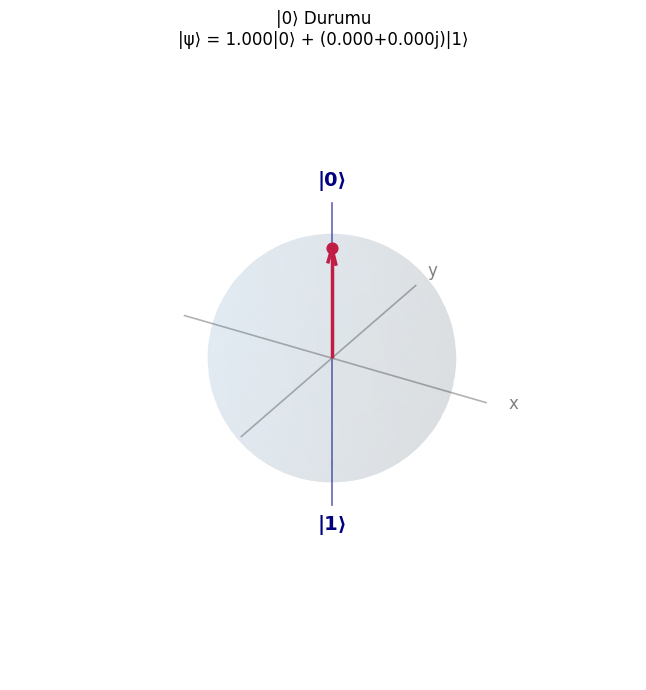

🔴 Süperpozisyon: |+⟩ = (|0⟩+|1⟩)/√2  (θ=π/2, φ=0):


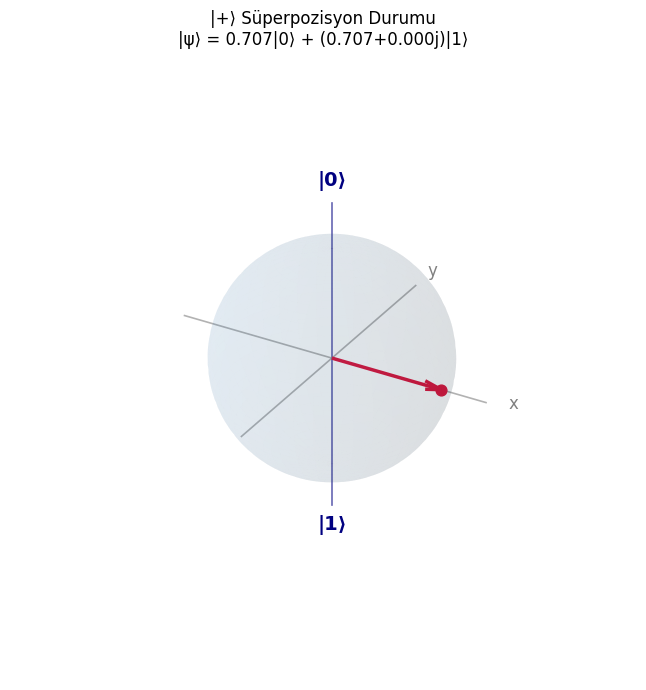

🟣 Genel kubit (θ=π/3, φ=π/4):


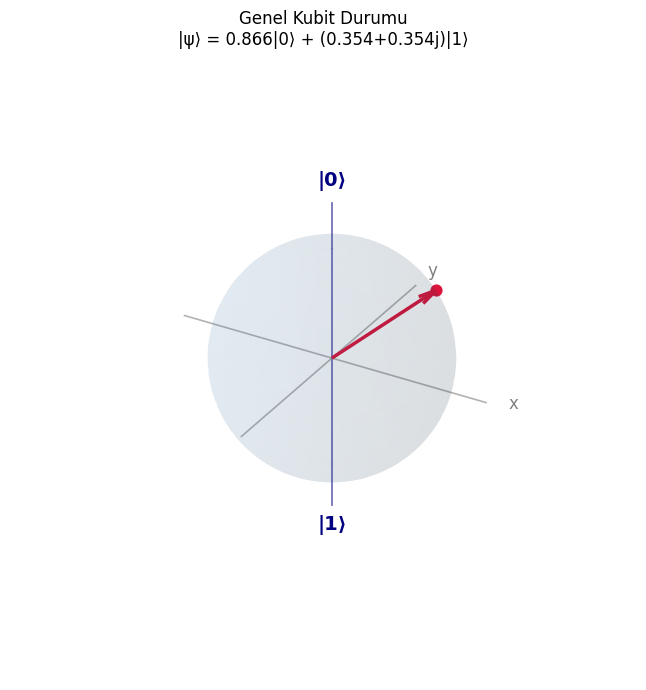

In [ ]:
# ────────────────────────────────────────────────
# DEMO 2.1: Bloch Küresini Çizme
# ────────────────────────────────────────────────

def bloch_sphere(theta, phi, title="Kubit Durumu"):
    """Verilen theta ve phi açıları için Bloch Küresini çizer."""
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Küre yüzeyini oluştur
    u = np.linspace(0, 2*np.pi, 80)
    v = np.linspace(0, np.pi, 80)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.08, color='steelblue')

    # Eksenler
    for start, end, label, clr in [
        ([0,0,-1.4], [0,0,1.4], '|0⟩', 'navy'),
        ([0,0,-1.4], [0,0,-1.4], '|1⟩', 'navy'),
        ([-1.4,0,0], [1.4,0,0], 'x', 'gray'),
        ([0,-1.4,0], [0,1.4,0], 'y', 'gray'),
    ]:
        ax.plot([start[0],end[0]], [start[1],end[1]], [start[2],end[2]],
                color=clr, linewidth=1.2, alpha=0.6)

    ax.text(0, 0, 1.55, '|0⟩', fontsize=14, ha='center', color='navy', fontweight='bold')
    ax.text(0, 0, -1.65, '|1⟩', fontsize=14, ha='center', color='navy', fontweight='bold')
    ax.text(1.6, 0, 0, 'x', fontsize=12, color='gray')
    ax.text(0, 1.6, 0, 'y', fontsize=12, color='gray')

    # Kubit durumu vektörü
    x_q = np.sin(theta)*np.cos(phi)
    y_q = np.sin(theta)*np.sin(phi)
    z_q = np.cos(theta)
    ax.quiver(0, 0, 0, x_q, y_q, z_q,
              color='crimson', linewidth=2.5, arrow_length_ratio=0.15)
    ax.scatter([x_q], [y_q], [z_q], color='crimson', s=60, zorder=5)

    alpha = np.round(np.cos(theta/2), 3)
    beta  = np.round(np.exp(1j*phi)*np.sin(theta/2), 3)
    ax.set_title(f"{title}\n|ψ⟩ = {alpha:.3f}|0⟩ + ({beta:.3f})|1⟩",
                 fontsize=12)
    ax.set_xlim([-1.5,1.5]); ax.set_ylim([-1.5,1.5]); ax.set_zlim([-1.5,1.5])
    ax.set_box_aspect([1,1,1])
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Farklı kubit durumlarını görselleştir
print("🔵 |0⟩ durumu (θ=0):")
bloch_sphere(0, 0, "|0⟩ Durumu")

print("🔴 Süperpozisyon: |+⟩ = (|0⟩+|1⟩)/√2  (θ=π/2, φ=0):")
bloch_sphere(np.pi/2, 0, "|+⟩ Süperpozisyon Durumu")

print("🟣 Genel kubit (θ=π/3, φ=π/4):")
bloch_sphere(np.pi/3, np.pi/4, "Genel Kubit Durumu")

Kuantum dünyasının kapılarını aralamak için, bu görselleri pusula iğnesinin hareketine benzeteceğiz.

Klasik bilgisayarlardaki **bitler** sadece `0` veya `1` olabilir. Bir düğme ya açıktır ya kapalıdır.
Kuantum bilgisayarlardaki **kubitler** ise daha esnektir. Aynı anda hem `0` hem de `1` olabilirler.

Bu durumu görselleştirmek için **Bloch Küresi** adı verilen bir haritayı kullanırız. Kürenin en tepesi (`|0⟩` durumu), en altı (`|1⟩` durumu) temsil eder. Kırmızı ok ise kubitin şu anki durumunu gösteren pusula iğnesidir.

Şimdi bu haritayı kullanarak görselleri adım adım inceleyelim:

### 🔵 1. Görsel: Kesinlik Durumu - `%100 Tura`

Bu görselde kırmızı ok tam olarak **kuzey kutbunda, `|0⟩` ekseninin üzerinde duruyor**. Bu, pusula iğnesinin "tam yukarıyı" göstermesi gibidir.

* **Ne Anlama Geliyor?** Bu, kubitin kesinlikle `0` durumunda olduğu anlamına gelir. Eğer bu kubiti "ölçerseniz", her zaman `0` sonucu çıkacaktır. Olasılık %100'dür. Bir parayı attık ve dik geldi, sadece tura yüzü görünüyor gibi düşünebilirsiniz.
* **Resimdeki Sayılar:** Başlıktaki formülde `|ψ⟩ = 1.000|0⟩ ...` ifadesi, `|0⟩` durumunun olasılığını verir. Bu sayıların karesini alarak olasılığı buluruz. `1.000`'in karesi 1'dir, bu da %100 demektir.

---

### 🔴 2. Görsel: Süperpozisyon - `Dönen Para`

Şimdi iğneyi hareket ettirelim. Kırmızı ok artık yukarıyı göstermiyor, **ekvator çizgisine kadar inmiş ve sağa (`x` eksenine) yönelmiş durumda**.

* **Ne Anlama Geliyor?** Bu, kuantum dünyasının kalbi olan **süperpozisyon** durumudur. Kubit şu an hem `0` hem de `1` durumunun bir karışımıdır. Pusula iğnesi, kuzey kutbuna (`|0⟩`) ve güney kutbuna (`|1⟩`) eşit uzaklıktadır.
* **Olasılıklar:** Eğer bu kubiti şimdi ölçerseniz, havada dönen bir para gibidir. %50 ihtimalle `0`, %50 ihtimalle `1` olarak sonuçlanacaktır.
* **Resimdeki Sayılar:** Başlıktaki formülde `|ψ⟩ = 0.707|0⟩ + 0.707|1⟩` sayılarını görüyoruz. Bu sayıların karesini alırsak: `(0.707)^2 ≈ 0.50`, yani her iki durum için de olasılık %50'dir.

---

### 🟣 3. Görsel: Genel Durum - `Önyargılı Döneç`

Kusursuz simetriyi bozuyoruz. Kırmızı oku ekvator çizgisinden yukarıya doğru, ama kuzey kutbuna kadar değil, ara bir noktaya taşıdık. Ayrıca ekvator düzleminde de döndürdük (görselde ok `x` ve `y` eksenlerinin arasında bir yere bakıyor).

* **Ne Anlama Geliyor?** Bu, en genel kubit durumudur. Ok hala süperpozisyondadır (ne tam 0, ne tam 1). Ama dikkat ederseniz, kırmızı ok **kuzey kutbuna (`|0⟩`) daha yakın duruyor**.
* **Olasılıklar:** Bu, hileli veya önyargılı bir para atmak gibidir. Para hala havada dönüyor, ama tura gelme olasılığı tura yüzü daha sık göründüğü için daha yüksektir. Ölçtüğümüzde 0 çıkma ihtimali daha yüksektir, ama 1 çıkma ihtimali hala vardır.
* **Resimdeki Sayılar:** Formüldeki sayılar daha karmaşıktır (`0.866` ve `0.354+0.354j`). Ama yine karelerini alarak olasılıkları buluruz:
 * `(0.866)^2 ≈ 0.75` (yani %75 ihtimalle 0)
 * `(0.354^2 + 0.354^2) ≈ 0.25` (yani %25 ihtimalle 1).

**Özetle:** Bloch Küresi, bir kubitin nerede olduğunu ve olasılıklarının ne olduğunu anlamamızı sağlayan bir haritadır. Ok nerede duruyorsa, o noktadan kuzey ve güney kutuplarına olan uzaklıkları, ölçüldüğünde hangi sonucu vereceğinin olasılıklarını belirler.

### BÖLÜM 2: Kuantum Hesaplama Temelleri
#### 2.1 Kuantum Oyununun 4 Temel Kuralı (Postülatlar)

Fizikçiler evrenin nasıl çalıştığını anlatmak için "postülat" dedikleri temel kurallar koyarlar. Bir satranç oyununun kuralları gibi düşünün. Kuantum dünyasında oynamak istiyorsak, şu dört kuralı bilmemiz gerekir:

**1. Durum Kuralı (Kimlik ve Adres):**
Gerçek dünyada bir arabanın nerede olduğunu GPS koordinatlarıyla (enlem, boylam) söyleriz. Kuantum dünyasında ise bir parçacığın nerede olduğunu veya hangi durumda olduğunu "Hilbert Uzayı" adı verilen matematiksel bir oyun alanında tanımlarız. Metindeki $|\psi\rangle$ (psi diye okunur) sembolü, sadece o parçacığın bu oyun alanındaki "durumunu" (kimliğini veya güncel halini) temsil eden bir etikettir.

**2. Evrim Kuralı (Hareket Etme):**
Bir durumu değiştirmek isterseniz (örneğin önceki örnekteki pusula iğnesini hareket ettirmek) ne yaparsınız? Kuantum dünyasında bunu $U$ harfiyle gösterilen "Üniter Operatörler" yapar. Bu operatörler, elinizdeki bir $|\psi\rangle$ durumunu alır ve onu bozmadan veya yok etmeden yeni bir duruma ($|\psi'\rangle$) dönüştürür. Tıpkı bir fotoğrafa filtre eklemek veya oyun hamuruna koparmadan yeni bir şekil vermek gibidir.

**3. Ölçüm Kuralı (Karar Anı - Kollaps):**
İşte kuantumun en meşhur ve en tuhaf kuralı! Havada hızla dönen bir madeni para (süperpozisyon) düşünün. Döndüğü sürece hem yazı hem turadır. Ama "ölçüm" yapmak, yani o parayı yakalayıp avucunuzun içine bakmak demektir. Baktığınız an büyü bozulur. Para bir karara varır ("kollaps" olur, yani çöker) ve size kesin bir sonuç (sadece yazı veya sadece tura) gösterir.

**4. Bileşik Sistem Kuralı (Takım Kurma):**
Eğer elinizde bir değil, iki tane kuantum parası (kubit) varsa ve bunları birlikte incelemek istiyorsanız, matematikte "tensor çarpımı" ($\otimes$) denilen bir işlem kullanırsınız. Bu işlem, "A kubiti ve B kubiti artık bir takımdır" demenin matematiksel yoludur. Meşhur "kuantum dolanıklığı" (entanglement) dediğimiz o gizemli bağ, tam olarak sistemler bu şekilde birleştirildiğinde ortaya çıkar.

---

#### 2.2 Kubit — Kuantumun Temel Birimi

Bu bölümü aslında bir önceki pusula iğnesi (Bloch Küresi) örneklerimizden biliyorsunuz. Şimdi işin mutfağına iniyoruz.

Klasik bilgisayarlardaki bitler sadece **0** (kapalı) veya **1** (açık) olabilir. Kubit ise bu ikisinin bir karışımı, yani "süperpozisyonu" halindedir. Bu karışım şu formülle ifade edilir:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$$

*   **Ne anlama geliyor?** Buradaki $|\psi\rangle$ bizim kubitimizdir. $\alpha$ (alfa) ve $\beta$ (beta) ise basitçe **ağırlıklardır** (fizikte buna genlik denir). Yani kubitin içinde ne kadar "0" aroması, ne kadar "1" aroması olduğunu belirlerler.
*   **Normalizasyon Koşulu ($|\alpha|^2 + |\beta|^2 = 1$):** Bu kural çok basittir: **İhtimallerin toplamı her zaman %100 (yani 1) olmalıdır.** Bir zar attığınızda tüm ihtimallerin toplamının %100 olması gerektiği gibi, kubiti ölçtüğünüzde de 0 veya 1 gelme olasılıklarının toplamı tam 1'e eşit olmalıdır. $\alpha$ ve $\beta$'nın karesi, bize o durumun gerçekleşme yüzdesini verir.

**Matris Gösterimi (Bilgisayarların Dili):**
$$|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \quad |1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$
Matematikçiler ve bilgisayarlar yönleri veya harfleri anlamazlar, sayıları anlarlar. O yüzden "Kuzey Kutbu" ($|0\rangle$) ve "Güney Kutbu" ($|1\rangle$) demek yerine, onları yukarıdaki gibi alt alta sayılar (vektörler) şeklinde yazarlar. Bu sayede işlemler çok daha kolay hesaplanır.

**Bloch Küresi Formülü (Pusulanın GPS Koordinatları):**
Son formül gözünüzü hiç korkutmasın:
$$|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle$$

Bu formül, daha önce incelediğimiz kırmızı pusula iğnesinin tam olarak nerede durduğunu gösteren bir **GPS cihazı gibidir**.
*   **$\theta$ (Teta - Enlem):** Kırmızı okun yukarıdan (Kuzey Kutbu'ndan) ne kadar aşağıya eğildiğini söyler. Ok tam yukarıdaysa $\theta = 0$'dır (0 durumu). Ekvatora indiyse $\theta = 90^\circ$ (veya $\pi/2$)'dir (Süperpozisyon durumu).
*   **$\phi$ (Fi - Boylam):** Kırmızı okun ekvator üzerinde kendi etrafında (sağa veya sola) ne kadar döndüğünü söyler. Dünyadaki boylam çizgileri gibidir.

Özetle bu karmaşık görünen sayfa, *"Kuantum evreninde oyun nasıl oynanır, oyuncuların (kubitlerin) kuralları nelerdir ve haritadaki (Bloch Küresi) yerleri nasıl bulunur?"* sorusunun matematiksel bir sözlüğüdür.

## 2.3 Kuantum Kapıları

Kuantum kapıları, kubit durumlarını dönüştüren **üniter matrislerdir** ($U^\dagger U = I$).

### Tek Kubitli Temel Kapılar

| Kapı | Sembol | Matris | Etki |
|------|--------|--------|------|
| Hadamard | H | $\frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | Süperpozisyon |
| Pauli-X | X | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | Klasik NOT kapısı |
| Pauli-Y | Y | $\begin{pmatrix}0&-i\\i&0\end{pmatrix}$ | Y ekseni rotasyonu |
| Pauli-Z | Z | $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$ | Faz çevirme |
| Rx(θ) | Rx | $\begin{pmatrix}\cos\frac{\theta}{2}&-i\sin\frac{\theta}{2}\\-i\sin\frac{\theta}{2}&\cos\frac{\theta}{2}\end{pmatrix}$ | X etrafında rotasyon |
| Ry(θ) | Ry | $\begin{pmatrix}\cos\frac{\theta}{2}&-\sin\frac{\theta}{2}\\\sin\frac{\theta}{2}&\cos\frac{\theta}{2}\end{pmatrix}$ | Y etrafında rotasyon |
| Rz(θ) | Rz | $\begin{pmatrix}e^{-i\theta/2}&0\\0&e^{i\theta/2}\end{pmatrix}$ | Z etrafında rotasyon |

### İki Kubitli Kapılar

**CNOT (Controlled-NOT):**
$$\text{CNOT} = \begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{pmatrix}$$

Kontrol kubiti $|1\rangle$ ise hedef kubiti çevirir; $|0\rangle$ ise dokunmaz.

**CZ (Controlled-Z):** Kontrol kubiti $|1\rangle$ ise hedef kubite Z kapısı uygular.

Madem kubitleri bir pusula iğnesi ya da havada dönen bir para gibi hayal etmeyi başardık, şimdi bu iğneyi nasıl hareket ettireceğimize, yani **Kuantum Kapıları'na** (Quantum Gates) bakalım.

Klasik bilgisayarlarda verileri işlemek için mantık kapıları (AND, OR, NOT) kullanırız. Kuantum evreninde ise oyunun kuralları ve alet çantası biraz farklıdır.

---

### 2.3 Kuantum Kapıları (Kuantum Alet Çantası)

Metindeki ilk cümle olan *"Kuantum kapıları, kubit durumlarını dönüştüren üniter matrislerdir ($U^\dagger U = I$)"* ifadesi gözünüzü korkutmasın.

Günlük dilde bunun anlamı şudur: **Bu kapılar, pusula iğnesini kırmadan, boyunu kısaltmadan veya uzatmadan sadece yönünü değiştiren sihirli parmaklardır.** Matematikteki "üniter" kelimesi, "ne yaparsan yap, olasılıkların toplamı hep %100 kalacak" garantisidir. O matrisler (sayı tabloları) ise sadece bilgisayara iğneyi hangi yöne ne kadar bükeceğini anlatan kullanım kılavuzlarıdır.

#### Tek Kubitli Temel Kapılar (Sihirli Parmaklar)

Bu kapılar tek bir kubit üzerinde çalışır. Pusulamızın iğnesiyle tek başlarına oynarlar:

*   **Hadamard (H - Süperpozisyon Kapısı):** Kuantumun en meşhur kapısıdır! Onu **"Para Fırlatıcı"** olarak düşünebiliriz. Eğer kubitiniz kesin bir şekilde masada tura ($|0\rangle$) duruyorsa, H kapısından geçtiği an havaya fırlatılır ve hızla dönmeye başlar. Yani onu Kuzey Kutbu'ndan alıp, ihtimallerin %50-%50 olduğu Ekvator çizgisine yatırır.
*   **Pauli-X (X - Klasik NOT Kapısı):** Bu bizim bildiğimiz **"Elektrik Anahtarı"**dır (veya Taklacı kapı). Görevi her şeyi tam tersine çevirmektir. Pusula iğnesi Kuzey'i ($|0\rangle$) gösteriyorsa Güney'e ($|1\rangle$) fırlatır, Güney'i gösteriyorsa Kuzey'e fırlatır.
*   **Pauli-Z (Z - Faz Çevirme):** Buna **"Ayna"** veya **"Gölge"** kapısı diyebiliriz. Bu kapı iğneyi yukarı veya aşağı hareket ettirmez (yani 0 veya 1 gelme olasılığını hiç değiştirmez). Yaptığı şey, iğneyi kürenin etrafında arka tarafa döndürmektir. Havada dönen paranın hızını ve yönünü bozmadan, sadece paranın yüzündeki resmi karanlık/negatif bir renge boyamak gibidir. Bu "faz farkı", ileride kuantum algoritmalarında dalgaların birbiriyle çarpışıp doğru cevabı bulması için çok kritiktir.
*   **Pauli-Y (Y):** X ve Z kapılarının aynı anda uygulanmış hali gibidir. Hem takla attırır hem ayna moduna sokar.
*   **Rx(θ), Ry(θ), Rz(θ) (Hassas Ayar Düğmeleri):** X, Y ve Z kapıları çok "kaba" hareketler yapar; iğneyi hep tam tur veya yarım tur fırlatırlar. Eğer iğneyi çok milimetrik, spesifik bir açı kadar döndürmek istiyorsanız (mesela "iğneyi sağa doğru 30 derece bük"), bu radyodaki ses açma düğmelerine benzeyen kapıları kullanırsınız. Buradaki Teta ($\theta$) açısı, düğmenin ne kadar çevrileceğini söyler.

#### İki Kubitli Kapılar (Takım Oyunu)

Bazen bir kubitin ne yapacağının, yanındaki diğer kubite bağlı olmasını isteriz. İşte burada iki kubitli kapılar devreye girer. Bunları bir **"Patron ve Çalışan"** ilişkisi olarak düşünebilirsiniz.

*   **CNOT (Controlled-NOT - Kontrollü NOT):** Bu, kuantum bilgisayarların kalbidir ve meşhur *kuantum dolanıklığını (entanglement)* yaratan anahtardır.
    *   Burada iki kubit vardır: Birinci kubit **Kontrol** (Patron), ikinci kubit **Hedef** (Çalışan).
    *   Kural çok basittir: Patron kontrol edilir. Eğer Patron $0$ modundaysa, "Bugün tatil" der ve Çalışan'a hiç dokunulmaz.
    *   Ama eğer Patron $1$ modundaysa, "Çalış!" der ve Çalışan anında takla atar (X kapısından geçer). Yani Çalışan $0$'sa $1$, $1$'se $0$ olur.
    *   *Matristeki o bol sıfırlı ve birli tablo, sadece bu patron-çalışan ilişkisinin bilgisayar diline çevrilmiş halidir.*

*   **CZ (Controlled-Z - Kontrollü Z):** CNOT ile mantığı tamamen aynıdır. Tek farkı, Patron $1$ olduğunda, Çalışan takla atmak yerine Z kapısından (Ayna/Gölge) geçer.

**Özetle:** Bir kuantum algoritması yazmak; bir sürü kubiti alıp önce H kapısıyla havaya fırlatmak (süperpozisyon), sonra CNOT kapılarıyla onları birbirine bağlamak (dolanıklık) ve son olarak rotasyon kapılarıyla olasılıkları hassasça ayarlayıp doğru cevaba yönlendirmektir!

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  KUANTUM KAPILARI — Bloch Küresi Adım Adım Görselleştirme
#  Bölüm 2.3 | Tek hücrelik çalıştır
# ─────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import widgets, HBox, VBox, Output, HTML
from IPython.display import display, clear_output

# ── Kapı tanımları ──────────────────────────────────────────────
GATES = [
    dict(
        name  = "Başlangıç: |0⟩",
        cat   = "Başlangıç",
        color = "#2e7d32",
        theta = 0,
        phi   = 0,
        p0    = 1.0,
        p1    = 0.0,
        desc  = (
            "Kubit |0⟩ durumunda — pusula iğnesi\n"
            "Kuzey Kutbu'nda durur. Ölçüm yapılsa\n"
            "kesinlikle 0 çıkar. Belirsizlik yok."
        ),
        eq    = "|ψ⟩ = |0⟩",
    ),
    dict(
        name  = "H — Hadamard (Para Fırlatıcı)",
        cat   = "Süperpozisyon",
        color = "#6a1b9a",
        theta = np.pi / 2,
        phi   = 0,
        p0    = 0.5,
        p1    = 0.5,
        desc  = (
            "H kapısı kubiti Kuzey'den Ekvator'a\n"
            "fırlatır. Artık hem 0 hem 1 %50\n"
            "olasılıkla ölçülür → süperpozisyon!"
        ),
        eq    = "|ψ⟩ = (|0⟩ + |1⟩) / √2 = |+⟩",
    ),
    dict(
        name  = "X — Pauli-X (Elektrik Anahtarı)",
        cat   = "NOT Kapısı",
        color = "#c62828",
        theta = np.pi,
        phi   = 0,
        p0    = 0.0,
        p1    = 1.0,
        desc  = (
            "X kapısı klasik NOT gibi çalışır.\n"
            "İğne Kuzey'den Güney'e uçar.\n"
            "0 → 1, 1 → 0 dönüşümü."
        ),
        eq    = "|ψ⟩ = |1⟩",
    ),
    dict(
        name  = "Z — Pauli-Z (Ayna / Gölge)",
        cat   = "Faz Kapısı",
        color = "#00695c",
        theta = np.pi,
        phi   = np.pi,
        p0    = 0.0,
        p1    = 1.0,
        desc  = (
            "Z kapısı iğneyi yukarı-aşağı\n"
            "hareket ettirmez. Olasılıklar aynı\n"
            "kalır ama faz gizlice tersine döner."
        ),
        eq    = "|ψ⟩ = −|1⟩   (faz değişti, olasılık aynı)",
    ),
    dict(
        name  = "Ry(π/3) — Hassas Ayar Düğmesi",
        cat   = "Rotasyon",
        color = "#e65100",
        theta = np.pi / 3,
        phi   = 0,
        p0    = np.cos(np.pi / 6) ** 2,
        p1    = np.sin(np.pi / 6) ** 2,
        desc  = (
            "Ry kapısı iğneyi tam θ=60° döndürür.\n"
            "Olasılıklar %75 / %25 olarak\n"
            "hassasça ayarlanır."
        ),
        eq    = "|ψ⟩ = cos(π/6)|0⟩ + sin(π/6)|1⟩",
    ),
    dict(
        name  = "Y — Pauli-Y",
        cat   = "Kombinasyon",
        color = "#1565c0",
        theta = np.pi,
        phi   = np.pi / 2,
        p0    = 0.0,
        p1    = 1.0,
        desc  = (
            "Y kapısı hem X hem Z'yi aynı anda\n"
            "uygular. Takla attırır ve aynaya\n"
            "sokar — hem yön hem faz değişir."
        ),
        eq    = "|ψ⟩ = i|1⟩",
    ),
    dict(
        name  = "H + CNOT — Bell Durumu",
        cat   = "Dolanıklık",
        color = "#283593",
        theta = np.pi / 2,
        phi   = np.pi / 4,
        p0    = 0.5,
        p1    = 0.5,
        desc  = (
            "H ardından CNOT iki kubiti dolanık\n"
            "yapar. Birini ölçünce diğeri anında\n"
            "belirlenir — uzaktan bağımsız!"
        ),
        eq    = "|ψ⟩ = (|00⟩ + |11⟩) / √2",
    ),
]

# ── Bloch küresi çizim fonksiyonu ───────────────────────────────
def draw_bloch(ax, theta, phi, color, prev_theta=None, prev_phi=None, n_interp=40):
    ax.cla()

    # Küre yüzeyi
    u = np.linspace(0, 2 * np.pi, 60)
    v = np.linspace(0, np.pi, 60)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones(len(u)), np.cos(v))
    ax.plot_surface(xs, ys, zs, alpha=0.07, color="#90caf9", linewidth=0)

    # Ekvator çemberi
    t = np.linspace(0, 2 * np.pi, 120)
    ax.plot(np.cos(t), np.sin(t), np.zeros_like(t),
            color="#90a4ae", linewidth=0.7, alpha=0.6)
    # Meridyen
    ax.plot(np.cos(t), np.zeros_like(t), np.sin(t),
            color="#90a4ae", linewidth=0.7, alpha=0.6)
    ax.plot(np.zeros_like(t), np.cos(t), np.sin(t),
            color="#90a4ae", linewidth=0.7, alpha=0.6)

    # Eksenler
    ax_len = 1.35
    for xs2, ys2, zs2, lbl, halign, va in [
        ([0, 0], [0, 0], [0, ax_len], '|0⟩', 'center', 'bottom'),
        ([0, 0], [0, 0], [0, -ax_len], '|1⟩', 'center', 'top'),
        ([0, ax_len], [0, 0], [0, 0], 'x', 'left', 'center'),
        ([0, 0], [0, ax_len], [0, 0], 'y', 'left', 'center'),
    ]:
        ax.plot(xs2, ys2, zs2, color="#546e7a", linewidth=1.1, alpha=0.7)
        ax.text(xs2[-1] * 1.12, ys2[-1] * 1.12, zs2[-1] * 1.12,
                lbl, fontsize=11, ha=halign, va=va,
                color="#1a237e", fontweight="bold")

    # Önceki durum (soluk)
    if prev_theta is not None:
        px = np.sin(prev_theta) * np.cos(prev_phi)
        py = np.sin(prev_theta) * np.sin(prev_phi)
        pz = np.cos(prev_theta)
        ax.quiver(0, 0, 0, px, py, pz,
                  color="#b0bec5", linewidth=1.5, alpha=0.4,
                  arrow_length_ratio=0.12, length=1.0)

    # Geçiş yolu (yay)
    if prev_theta is not None:
        ts = np.linspace(0, 1, n_interp)
        ease = ts ** 2 * (3 - 2 * ts)          # smoothstep
        arc_theta = prev_theta + (theta - prev_theta) * ease
        arc_phi   = prev_phi   + (phi   - prev_phi)   * ease
        ax_x = np.sin(arc_theta) * np.cos(arc_phi)
        ax_y = np.sin(arc_theta) * np.sin(arc_phi)
        ax_z = np.cos(arc_theta)
        ax.plot(ax_x, ax_y, ax_z,
                color=color, linewidth=1.2, alpha=0.35, linestyle="--")

    # Mevcut vektör
    vx = np.sin(theta) * np.cos(phi)
    vy = np.sin(theta) * np.sin(phi)
    vz = np.cos(theta)
    ax.quiver(0, 0, 0, vx, vy, vz,
              color=color, linewidth=2.5, alpha=0.95,
              arrow_length_ratio=0.14, length=1.0)
    ax.scatter([vx], [vy], [vz], s=55, color=color, zorder=10)

    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_zlim([-1.5, 1.5])
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.view_init(elev=20, azim=35)

# ── Olasılık çubuğu ─────────────────────────────────────────────
def draw_probs(ax_p, p0, p1, color):
    ax_p.cla()
    bars = ax_p.barh(["|1⟩", "|0⟩"], [p1, p0],
                     color=[color, "#2e7d32"], height=0.45,
                     alpha=0.85)
    ax_p.set_xlim(0, 1.0)
    ax_p.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax_p.set_xticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=9)
    ax_p.set_yticks(["|0⟩", "|1⟩"])
    ax_p.set_yticklabels(["|0⟩", "|1⟩"], fontsize=11, fontweight="bold")
    ax_p.tick_params(left=False)
    ax_p.spines[["top", "right", "left"]].set_visible(False)
    ax_p.set_title("Ölçüm Olasılıkları", fontsize=10, pad=6, color="#37474f")
    for bar, val in zip(bars, [p1, p0]):
        ax_p.text(min(val + 0.02, 0.95), bar.get_y() + bar.get_height() / 2,
                  f"{val:.0%}", va="center", fontsize=10, color="#37474f")

# ── Ana render ──────────────────────────────────────────────────
out   = Output()
state = {"idx": 0, "prev_theta": None, "prev_phi": None}

def render(idx, prev_theta=None, prev_phi=None):
    g = GATES[idx]
    with out:
        clear_output(wait=True)
        fig = plt.figure(figsize=(11, 4.8))
        fig.patch.set_facecolor("#fafafa")

        ax_bloch = fig.add_axes([0.00, 0.0, 0.48, 1.0],
                                 projection="3d", facecolor="#fafafa")
        ax_prob  = fig.add_axes([0.52, 0.55, 0.44, 0.38],
                                 facecolor="#fafafa")
        ax_text  = fig.add_axes([0.52, 0.00, 0.44, 0.50],
                                 facecolor="#fafafa")

        draw_bloch(ax_bloch, g["theta"], g["phi"], g["color"],
                   prev_theta, prev_phi)
        draw_probs(ax_prob, g["p0"], g["p1"], g["color"])

        # Metin paneli
        ax_text.set_axis_off()
        step_txt  = f"Adım {idx + 1} / {len(GATES)}"
        cat_txt   = f"[{g['cat']}]"
        name_txt  = g["name"]
        desc_txt  = g["desc"]
        eq_txt    = g["eq"]

        ax_text.text(0.0, 0.98, step_txt, transform=ax_text.transAxes,
                     fontsize=9, color="#78909c", va="top")
        ax_text.text(0.0, 0.86, cat_txt, transform=ax_text.transAxes,
                     fontsize=10, color=g["color"], va="top", fontweight="bold")
        ax_text.text(0.0, 0.73, name_txt, transform=ax_text.transAxes,
                     fontsize=12, color="#1a237e", va="top", fontweight="bold")
        ax_text.text(0.0, 0.48, desc_txt, transform=ax_text.transAxes,
                     fontsize=10, color="#37474f", va="top", linespacing=1.6)
        ax_text.text(0.0, 0.08, eq_txt, transform=ax_text.transAxes,
                     fontsize=10, color="#263238", va="top",
                     fontfamily="monospace",
                     bbox=dict(boxstyle="round,pad=0.4", facecolor="#eceff1",
                               edgecolor="#b0bec5", linewidth=0.8))

        plt.show()

# ── Widget butonları ─────────────────────────────────────────────
style = {"button_width": "120px"}

btn_prev = widgets.Button(description="◀  Geri",
                          layout=widgets.Layout(width="120px", height="34px"))
btn_next = widgets.Button(description="İleri  ▶",
                          layout=widgets.Layout(width="120px", height="34px"),
                          button_style="primary")
dots_html = widgets.HTML()
lbl_gate  = widgets.HTML()

def update_nav():
    idx = state["idx"]
    btn_prev.disabled = idx == 0
    btn_next.disabled = idx == len(GATES) - 1
    dots = ""
    for i, g in enumerate(GATES):
        col  = g["color"] if i == idx else "#cfd8dc"
        size = "11px" if i == idx else "9px"
        dots += (f'<span style="display:inline-block;width:{size};height:{size};'
                 f'border-radius:50%;background:{col};margin:0 3px;'
                 f'vertical-align:middle"></span>')
    dots_html.value = f'<div style="text-align:center;margin:4px 0">{dots}</div>'

def go_next(_):
    idx = state["idx"]
    if idx < len(GATES) - 1:
        state["prev_theta"] = GATES[idx]["theta"]
        state["prev_phi"]   = GATES[idx]["phi"]
        state["idx"]        = idx + 1
        update_nav()
        render(state["idx"], state["prev_theta"], state["prev_phi"])

def go_prev(_):
    idx = state["idx"]
    if idx > 0:
        state["prev_theta"] = GATES[idx]["theta"]
        state["prev_phi"]   = GATES[idx]["phi"]
        state["idx"]        = idx - 1
        update_nav()
        render(state["idx"], state["prev_theta"], state["prev_phi"])

btn_next.on_click(go_next)
btn_prev.on_click(go_prev)

update_nav()
render(0)

nav_bar = HBox(
    [btn_prev, dots_html, btn_next],
    layout=widgets.Layout(
        justify_content="center", align_items="center", gap="12px", margin="6px 0"
    )
)

header = HTML(
    '<div style="font-size:14px;font-weight:600;color:#1a237e;'
    'padding:6px 0 2px;text-align:center">'
    'Kuantum Kapıları — Bloch Küresi Adım Adım</div>'
)

display(VBox([header, out, nav_bar]))

▶ Bölüm 1: Kubit — Bloch Küresi


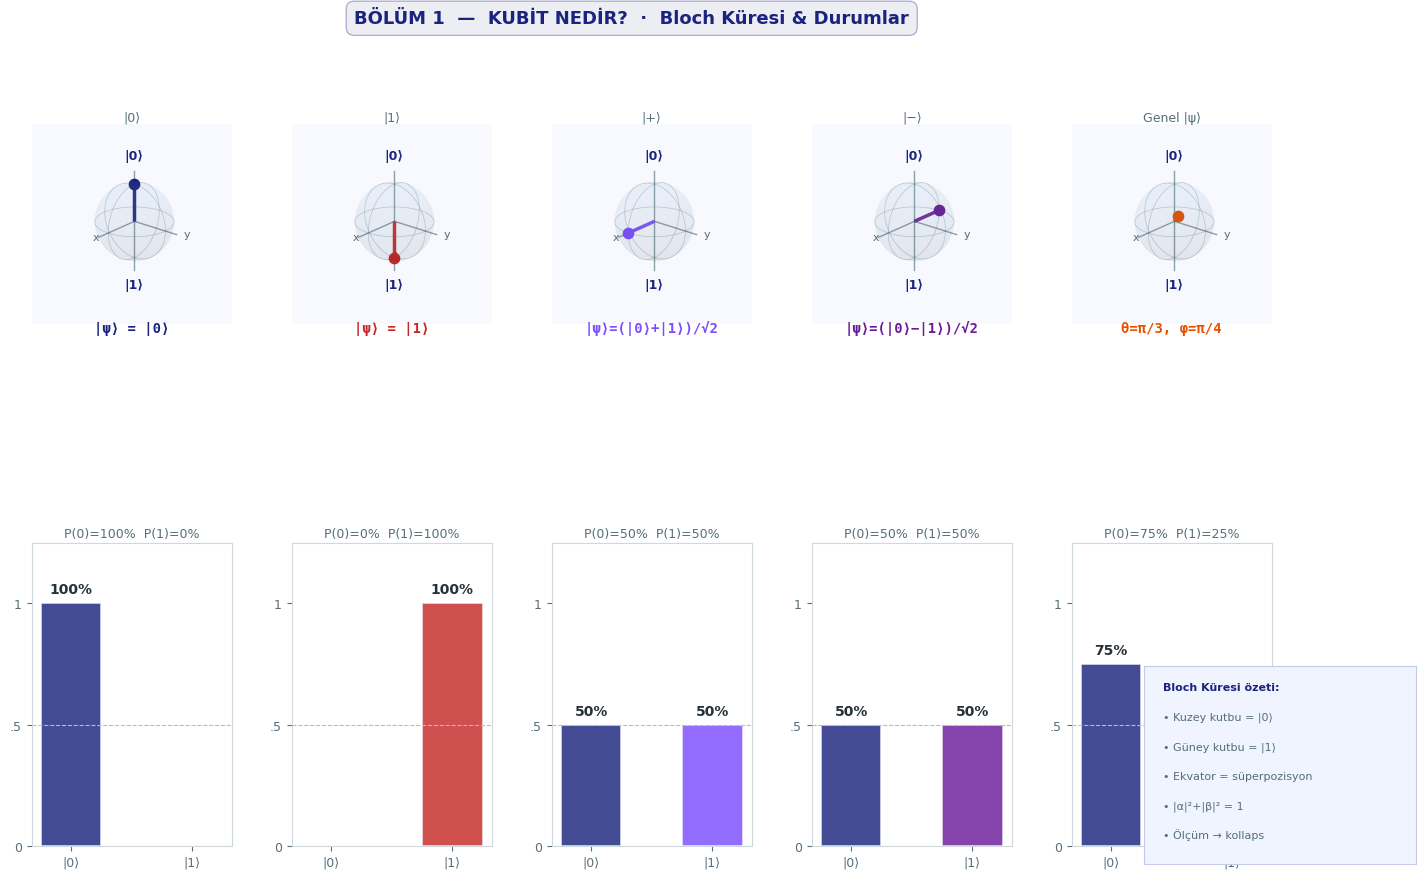

   ✅ Bloch Küresi görselleştirmesi tamamlandı

▶ Bölüm 2: Tek Kubitli Kapılar — H, X, Y, Z


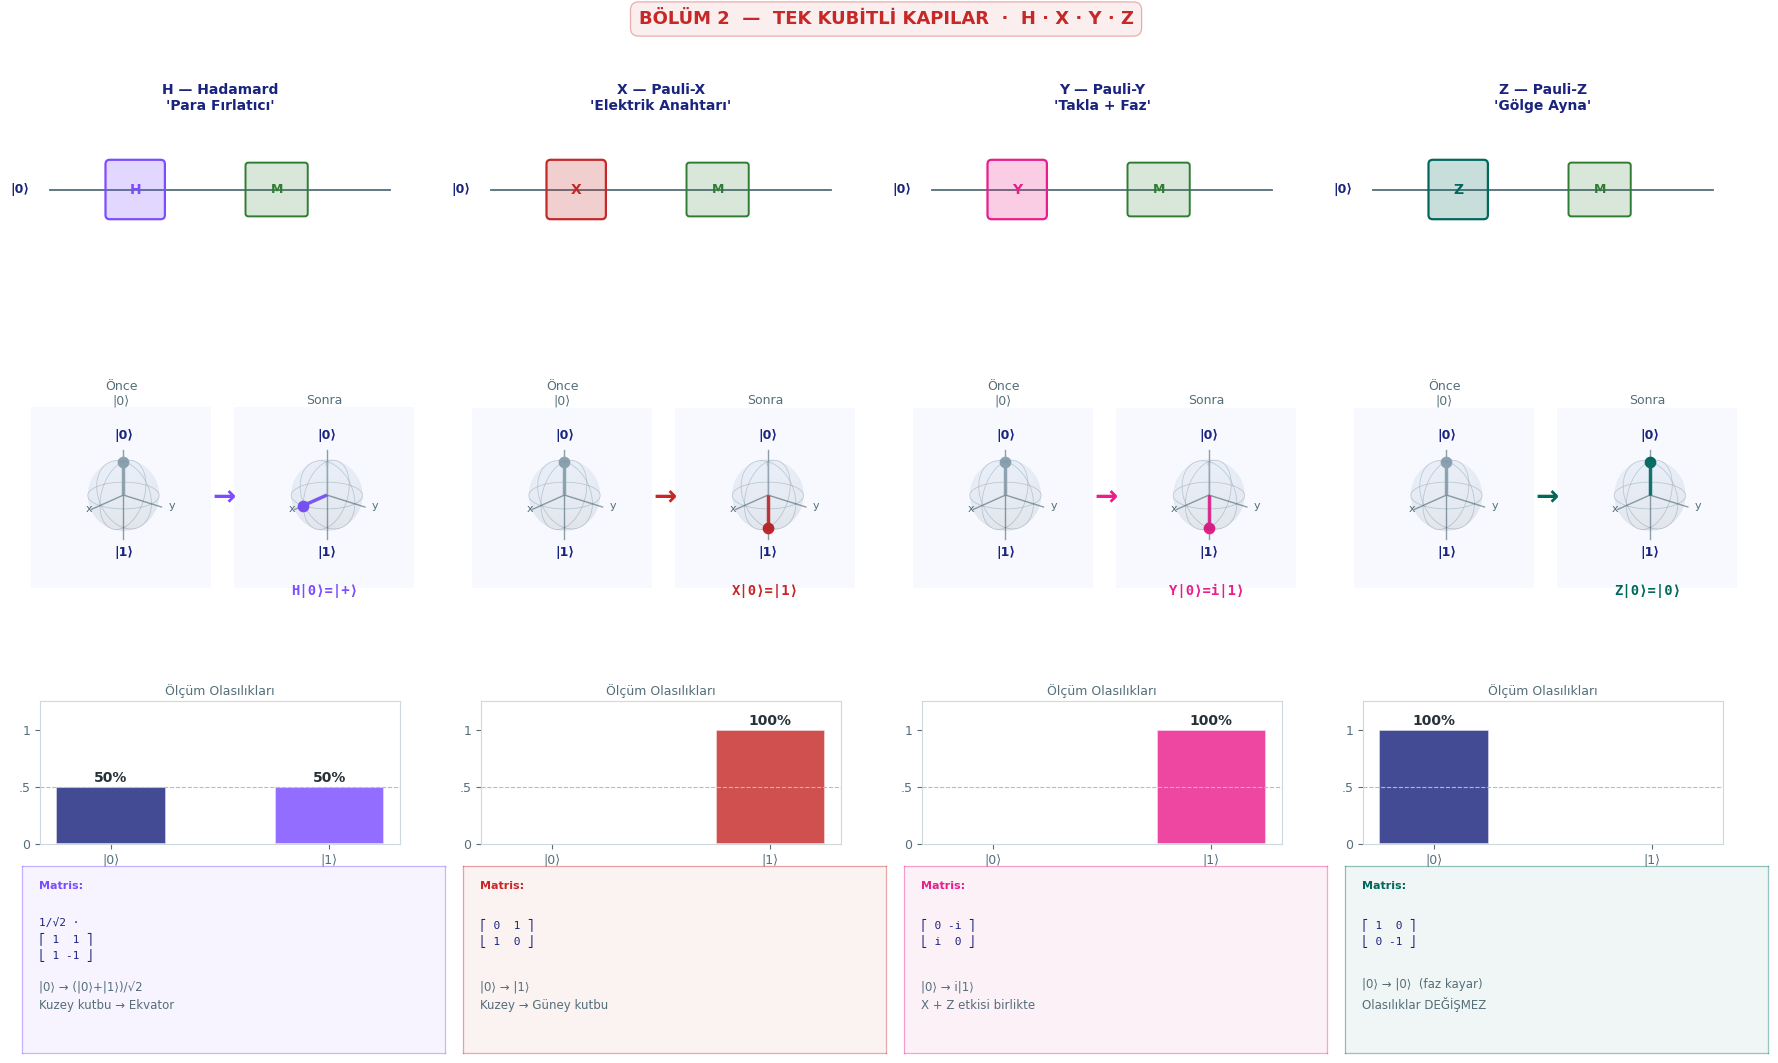

   ✅ Tek kubitli kapılar tamamlandı

▶ Bölüm 3: Rotasyon Kapıları — Ry(θ), Rz(θ)


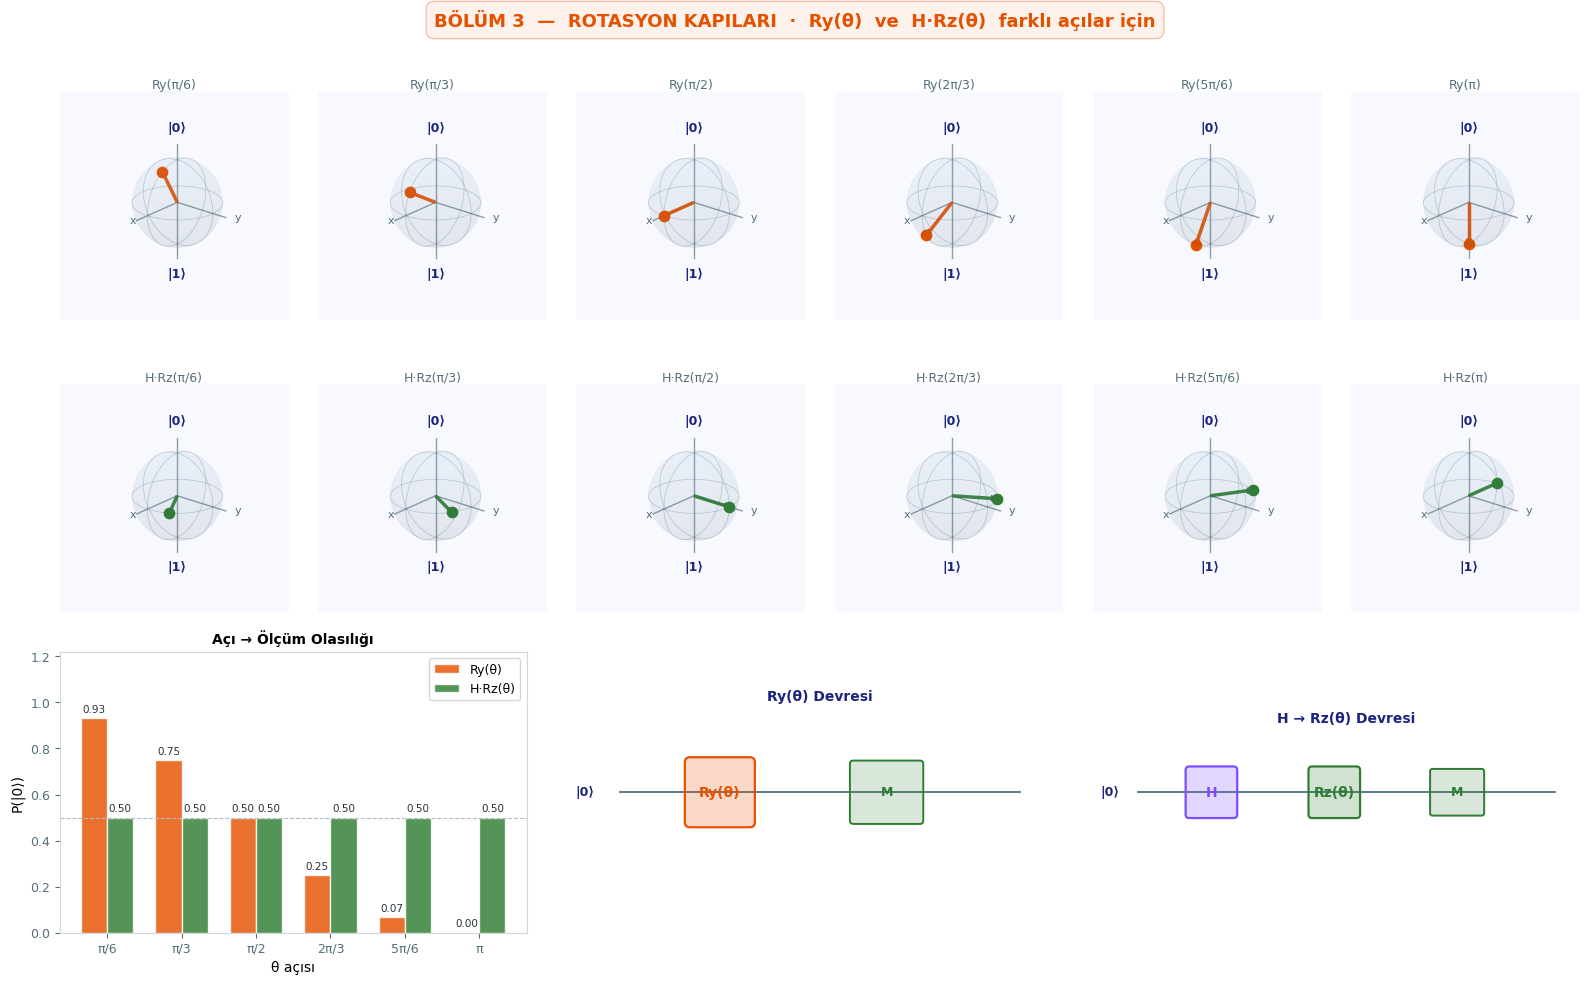

   ✅ Rotasyon kapıları tamamlandı

▶ Bölüm 4: İki Kubitli Kapılar — CNOT, CZ, Bell Durumu


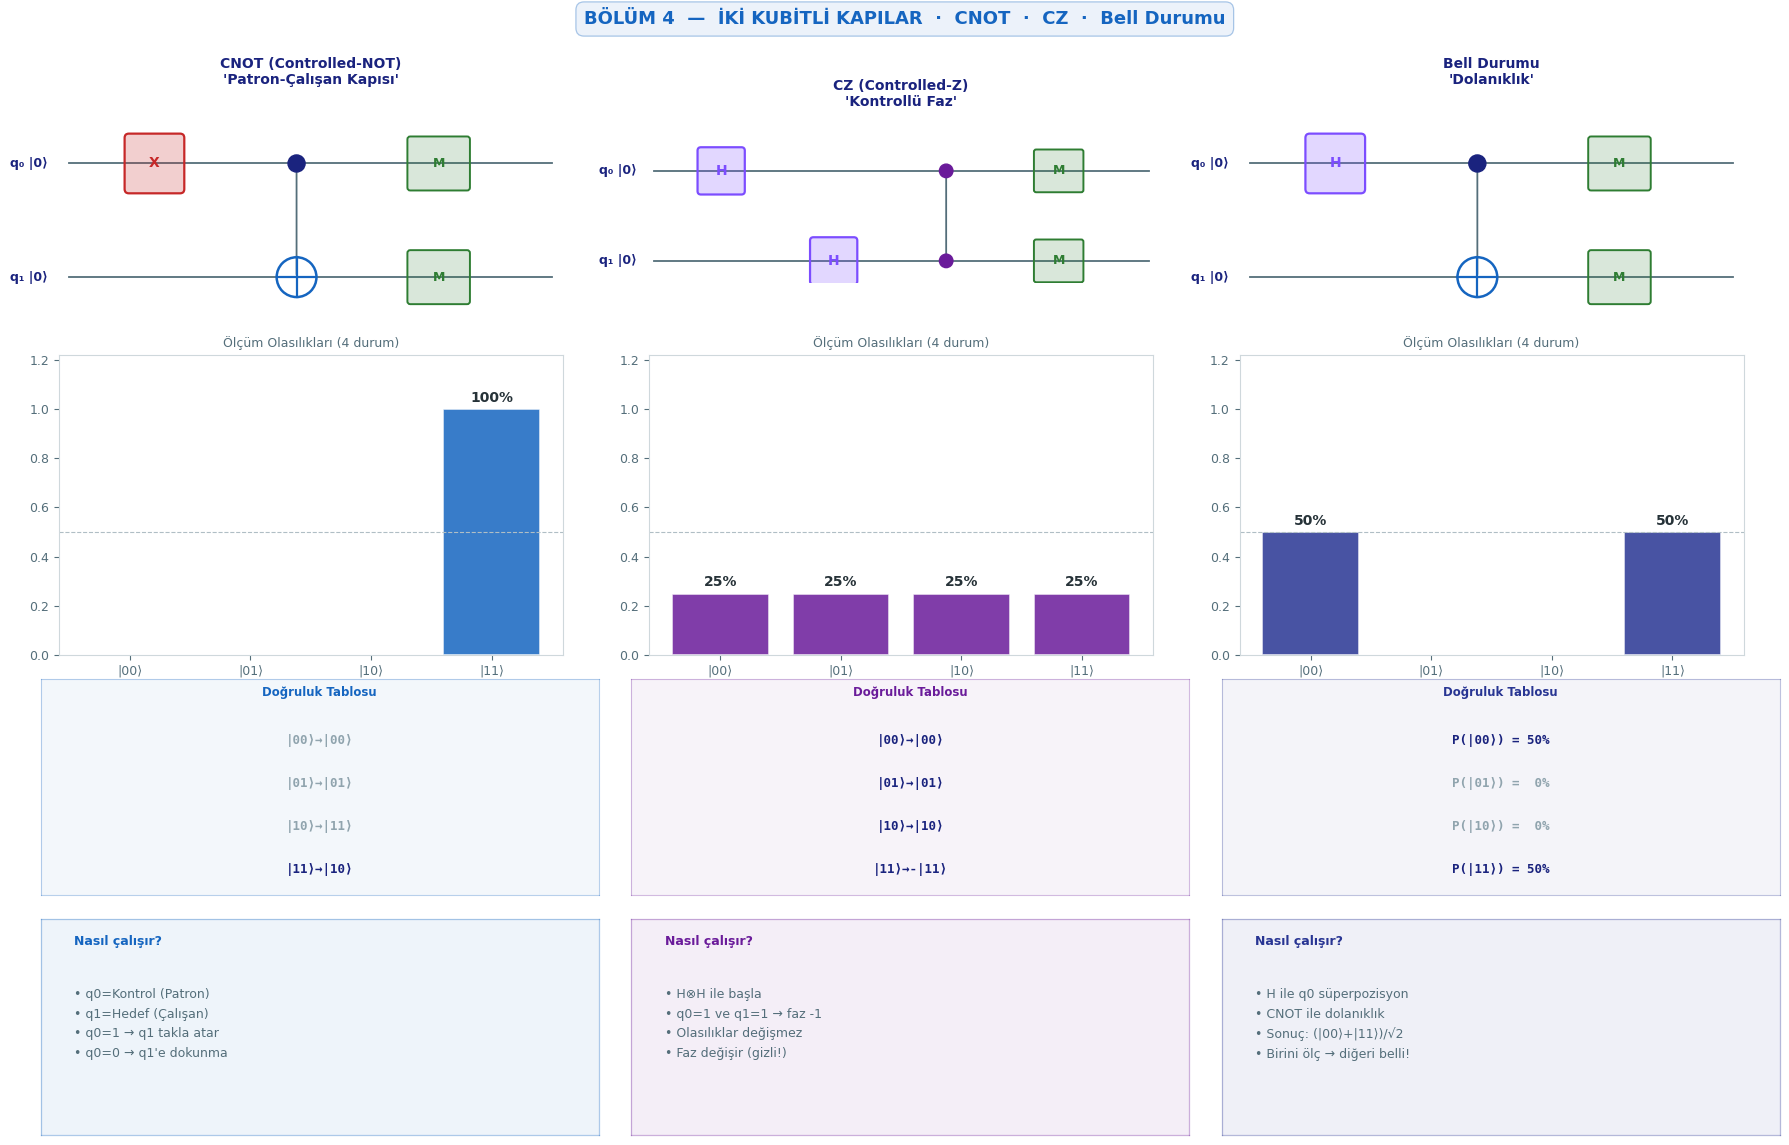

   ✅ İki kubitli kapılar tamamlandı

▶ Bölüm 5: Kapıların Bloch Küresi Özeti + Kapı Kombine Devresi


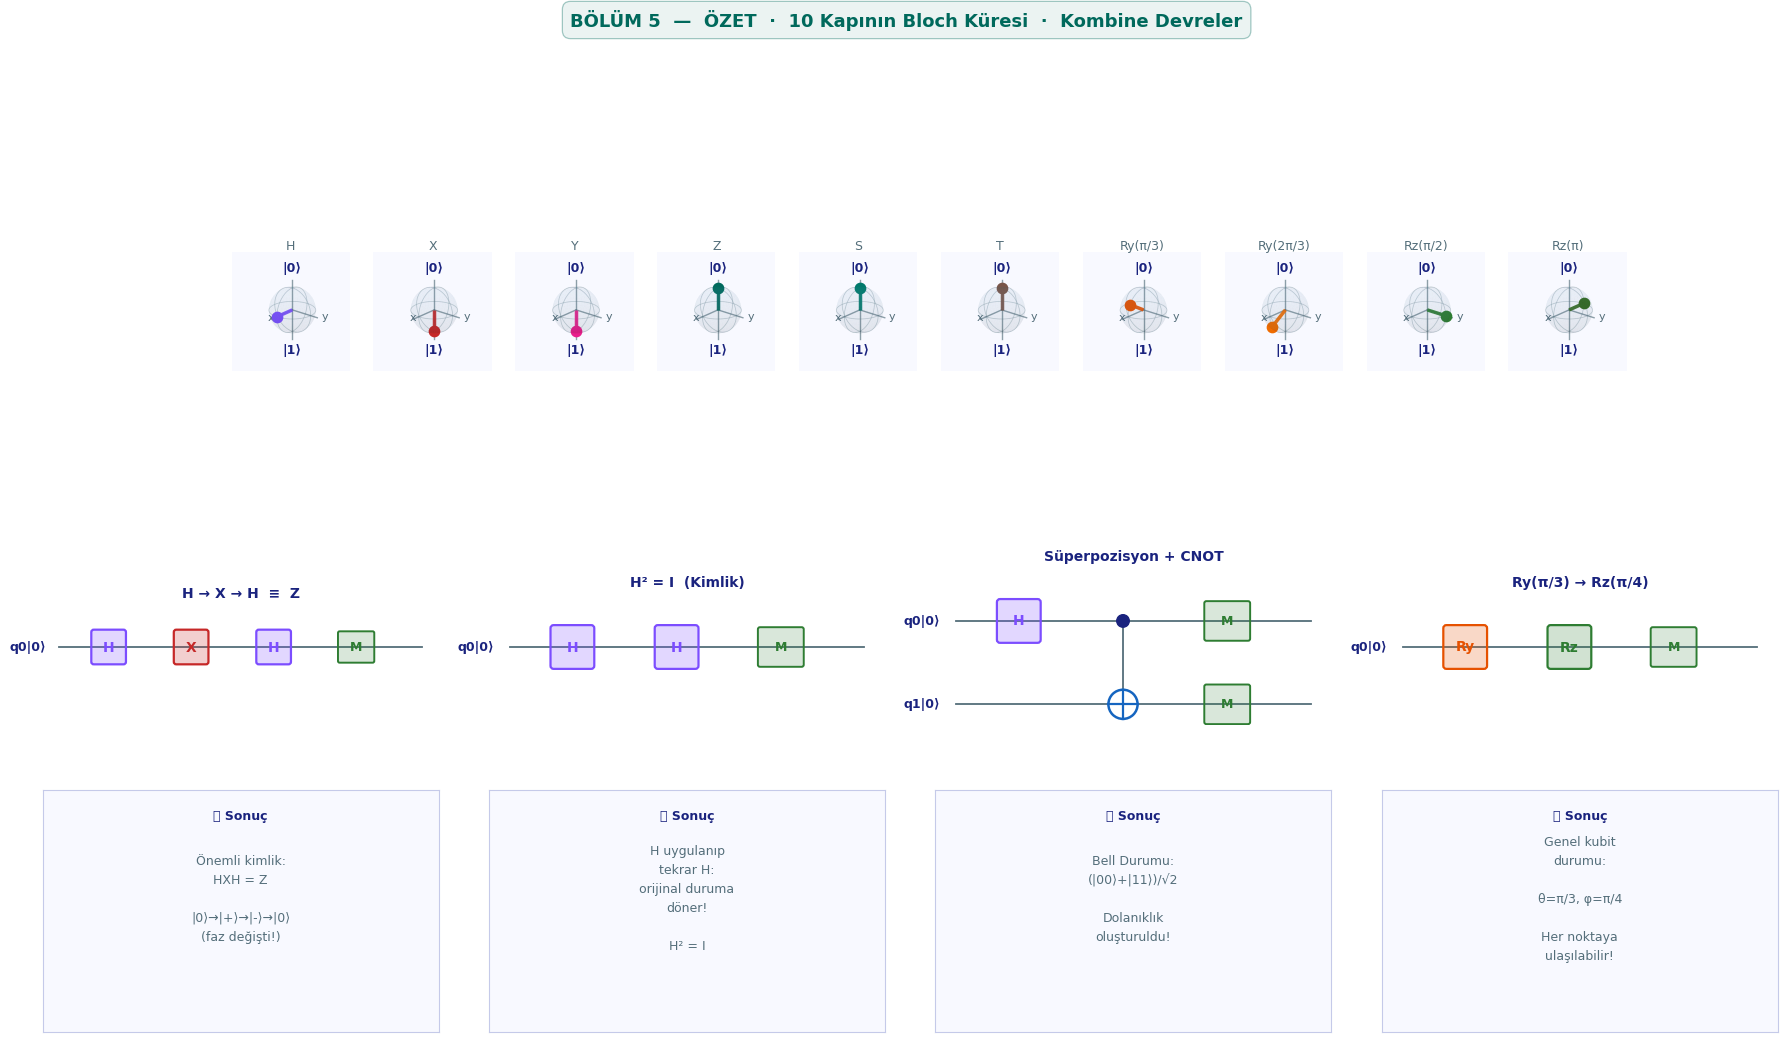

   ✅ Özet ve kombine devreler tamamlandı

▶ Bölüm 6: Kapıların Matematiği — Matris Gösterimi


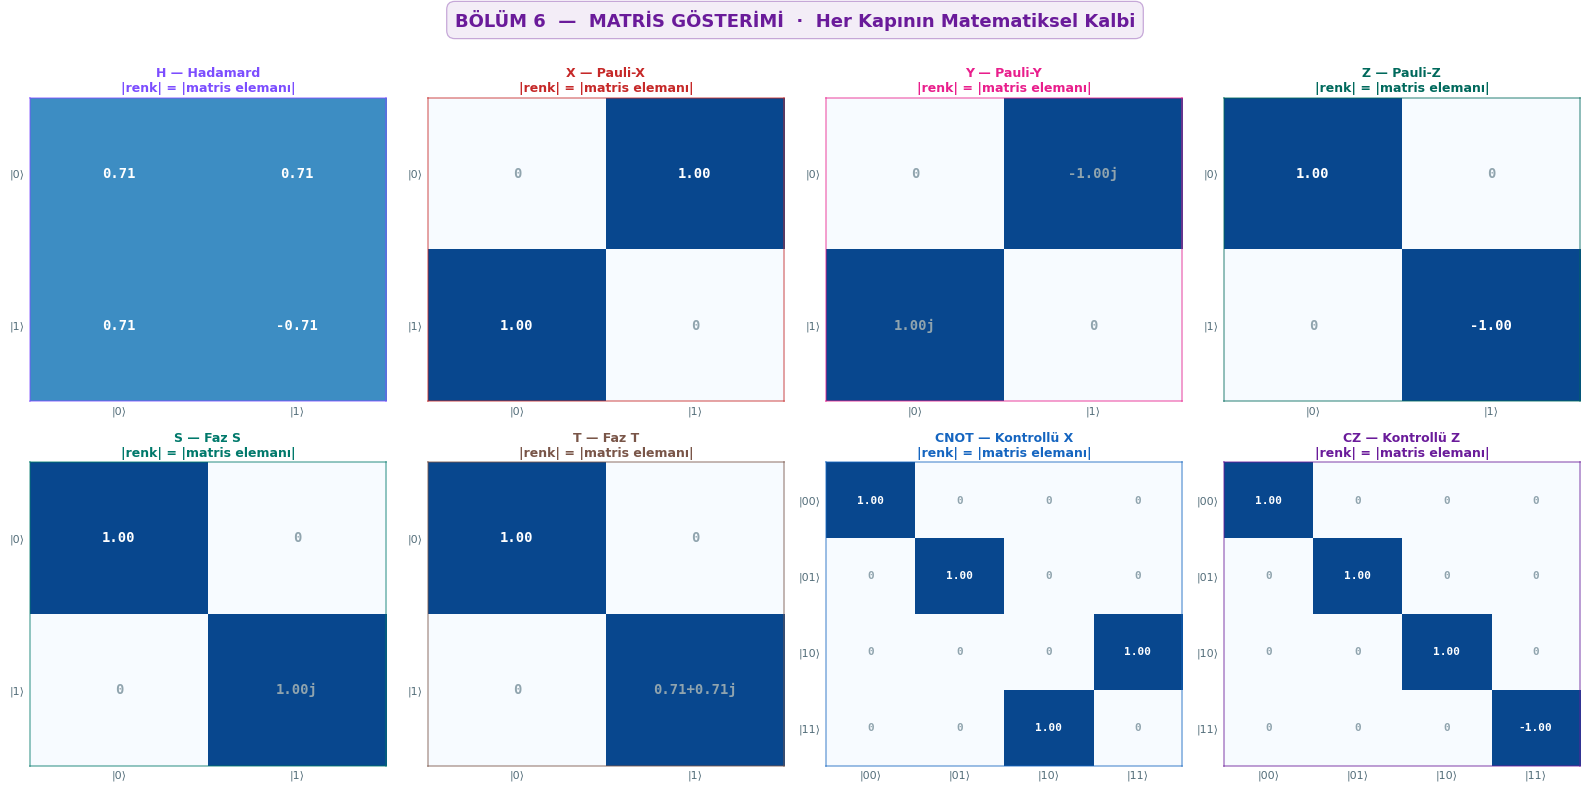

   ✅ Matris görselleştirme tamamlandı

════════════════════════════════════════════════════════════
🎓  KUANTUM KAPILARI — WORKSHOP ÖZET
════════════════════════════════════════════════════════════

  Bölüm 1  →  bolum1_kubit.png
             Kubit, Bloch Küresi, 5 temel durum

  Bölüm 2  →  bolum2_tek_kubitli_kapılar.png
             H · X · Y · Z
             Her biri için: Önce/Sonra Bloch + matris + olasılık

  Bölüm 3  →  bolum3_rotasyon_kapilari.png
             Ry(θ) ve H·Rz(θ) — 6 farklı açı karşılaştırması

  Bölüm 4  →  bolum4_iki_kubitli_kapılar.png
             CNOT · CZ · Bell Durumu
             Devre + olasılık + doğruluk tablosu

  Bölüm 5  →  bolum5_ozet_kombine.png
             10 kapı Bloch özeti + kombine devre örnekleri

  Bölüm 6  →  bolum6_matris.png
             8 kapının matris ısı haritası

════════════════════════════════════════════════════════════


In [4]:
# ════════════════════════════════════════════════════════════════
#  KUBİT & KUANTUM KAPILARI — Adım Adım Görsel Anlatım
#  Tek hücrede çalışır · PennyLane + Matplotlib
# ════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Arc, FancyBboxPatch, Circle
from matplotlib.colors import to_rgba
from mpl_toolkits.mplot3d import Axes3D
import pennylane as qml
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "text.usetex":       False,
})

# ── Renk Paleti ──────────────────────────────────────────────────
P = dict(
    navy="#1A237E", blue="#1565C0", indigo="#3949AB",
    purple="#7C4DFF", violet="#6A1B9A", red="#C62828",
    orange="#E65100", green="#2E7D32", teal="#00695C",
    gray="#546E7A", ltgray="#ECEFF1", midgray="#90A4AE",
    white="white", bg="#F8F9FF",
)

GATE_CLR = dict(
    H=P["purple"], X=P["red"], Y="#E91E8C", Z=P["teal"],
    RY=P["orange"], RZ=P["green"], S="#00796B", T="#795548",
    CNOT=P["blue"], CZ=P["violet"],
)

dev1 = qml.device("default.qubit", wires=1)
dev2 = qml.device("default.qubit", wires=2)

# ════════════════════════════════════════════════════════════════
#  YARDIMCI FONKSİYONLAR
# ════════════════════════════════════════════════════════════════

def style_ax(ax):
    for sp in ax.spines.values():
        sp.set_color("#CFD8DC")
    ax.tick_params(colors=P["gray"], labelsize=9)

def bloch_3d(ax, theta, phi, color, title="", prev=None, label_state=""):
    ax.cla(); ax.set_facecolor(P["bg"])
    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    ax.plot_surface(np.outer(np.cos(u), np.sin(v)),
                    np.outer(np.sin(u), np.sin(v)),
                    np.outer(np.ones(50), np.cos(v)),
                    alpha=0.055, color="#90CAF9", linewidth=0)
    t = np.linspace(0, 2*np.pi, 100)
    for xc, yc, zc in [(np.cos(t), np.sin(t), np.zeros(100)),
                        (np.cos(t), np.zeros(100), np.sin(t)),
                        (np.zeros(100), np.cos(t), np.sin(t))]:
        ax.plot(xc, yc, zc, color="#90A4AE", lw=0.55, alpha=0.5)
    for a, b, c in [([0,0],[0,0],[1.35,-1.35]),
                    ([1.35,0],[0,0],[0,0]),
                    ([0,0],[1.35,0],[0,0])]:
        ax.plot(a, b, c, color="#546E7A", lw=1.0, alpha=0.65)
    ax.text(0,0, 1.58, "|0⟩", ha="center", va="bottom", fontsize=9,
            color=P["navy"], fontweight="bold")
    ax.text(0,0,-1.58, "|1⟩", ha="center", va="top",   fontsize=9,
            color=P["navy"], fontweight="bold")
    ax.text(1.58,0,0, "x", ha="left",  fontsize=8, color=P["gray"])
    ax.text(0,1.58,0, "y", ha="left",  fontsize=8, color=P["gray"])
    if prev is not None:
        pt, pp = prev
        ax.quiver(0,0,0, np.sin(pt)*np.cos(pp),
                  np.sin(pt)*np.sin(pp), np.cos(pt),
                  color="#B0BEC5", lw=1.5, alpha=0.4,
                  arrow_length_ratio=0.12, length=1.0)
    vx = np.sin(theta)*np.cos(phi)
    vy = np.sin(theta)*np.sin(phi)
    vz = np.cos(theta)
    ax.quiver(0,0,0, vx,vy,vz, color=color, lw=2.5,
              arrow_length_ratio=0.15, length=1.0, alpha=0.93)
    ax.scatter([vx],[vy],[vz], s=55, color=color, zorder=10)
    ax.set_xlim([-1.5,1.5]); ax.set_ylim([-1.5,1.5]); ax.set_zlim([-1.5,1.5])
    ax.set_box_aspect([1,1,1]); ax.set_axis_off()
    ax.view_init(elev=22, azim=40)
    if title: ax.set_title(title, fontsize=9, pad=2, color=P["gray"])
    if label_state:
        ax.text2D(0.5, -0.04, label_state, transform=ax.transAxes,
                  ha="center", fontsize=10, color=color, fontweight="bold",
                  fontfamily="monospace")

def prob_bar(ax, p0, p1, color, title=""):
    ax.cla(); ax.set_facecolor("white")
    bars = ax.bar(["|0⟩","|1⟩"], [p0,p1], color=[P["navy"],color],
                  width=0.5, alpha=0.82, edgecolor="white", linewidth=1.2)
    for b, v in zip(bars, [p0,p1]):
        if v > 0.03:
            ax.text(b.get_x()+b.get_width()/2, v+0.04,
                    f"{v:.0%}", ha="center", fontsize=10,
                    fontweight="600", color="#263238")
    ax.set_ylim(0, 1.25); ax.set_yticks([0,0.5,1.0])
    ax.set_yticklabels(["0",".5","1"], fontsize=8)
    ax.axhline(0.5, color="#B0BEC5", lw=0.8, ls="--")
    ax.set_title(title, fontsize=9, color=P["gray"], pad=4)
    style_ax(ax)

def gate_box(ax, x, y, label, color, size=0.35):
    ax.add_patch(FancyBboxPatch((x-size/2, y-size/2), size, size,
        boxstyle="round,pad=0.03",
        facecolor=to_rgba(color, 0.22),
        edgecolor=color, linewidth=1.6))
    ax.text(x, y, label, ha="center", va="center",
            fontsize=10, fontweight="bold", color=color)

def cnot_symbol(ax, cx, cy, tx, ty):
    ax.annotate("", xy=(tx, ty), xytext=(cx, cy),
                arrowprops=dict(arrowstyle="-", color=P["gray"], lw=1.3))
    ax.add_patch(Circle((cx, cy), 0.06, color=P["navy"], zorder=5))
    ax.add_patch(Circle((tx, ty), 0.14, fill=False,
                         edgecolor=P["blue"], linewidth=1.8, zorder=5))
    ax.plot([tx-0.14, tx+0.14], [ty, ty], color=P["blue"], lw=1.6, zorder=6)
    ax.plot([tx, tx], [ty-0.14, ty+0.14], color=P["blue"], lw=1.6, zorder=6)

def wire_diagram(ax, n_wires, gates, wire_labels=None, title=""):
    ax.cla(); ax.set_facecolor("white")
    ax.set_xlim(-0.3, len(gates)+0.5)
    ax.set_ylim(-0.5*n_wires, 0.5)
    ax.set_aspect("equal"); ax.set_axis_off()

    y_pos = [-(i*0.8) for i in range(n_wires)]
    for i, y in enumerate(y_pos):
        lbl = wire_labels[i] if wire_labels else f"q{i}"
        ax.text(-0.25, y, lbl, ha="right", va="center",
                fontsize=9, fontweight="bold", color=P["navy"])
        ax.plot([-0.1, len(gates)+0.3], [y, y],
                color=P["gray"], lw=1.3, zorder=1)

    for step, gate_info in enumerate(gates):
        x = step + 0.5
        if isinstance(gate_info, dict):
            name   = gate_info["name"]
            wires_ = gate_info["wires"]
            color  = gate_info.get("color", P["blue"])
            if name == "CNOT":
                cnot_symbol(ax, x, y_pos[wires_[0]], x, y_pos[wires_[1]])
            elif name == "CZ":
                ax.annotate("", xy=(x, y_pos[wires_[1]]),
                            xytext=(x, y_pos[wires_[0]]),
                            arrowprops=dict(arrowstyle="-",
                                            color=P["gray"], lw=1.3))
                for w in wires_:
                    ax.add_patch(Circle((x, y_pos[w]), 0.06,
                                        color=P["violet"], zorder=5))
            elif name == "|M⟩":
                for w in wires_:
                    ax.add_patch(FancyBboxPatch(
                        (x-0.2, y_pos[w]-0.17), 0.4, 0.34,
                        boxstyle="round,pad=0.02",
                        facecolor=to_rgba(P["green"], 0.18),
                        edgecolor=P["green"], linewidth=1.4))
                    ax.text(x, y_pos[w], "M", ha="center", va="center",
                            fontsize=9, fontweight="bold", color=P["green"])
            else:
                for w in wires_:
                    gate_box(ax, x, y_pos[w], name, color, size=0.36)
        else:
            gate_box(ax, x, y_pos[0], gate_info, P["blue"])

    ax.set_title(title, fontsize=10, fontweight="600",
                 color=P["navy"], pad=6)

def section_header(fig, y_frac, txt, color):
    fig.text(0.5, y_frac, txt, ha="center", va="center",
             fontsize=13, fontweight="700", color=color,
             bbox=dict(boxstyle="round,pad=0.45",
                       facecolor=to_rgba(color, 0.08),
                       edgecolor=to_rgba(color, 0.35), lw=0.9))

# ════════════════════════════════════════════════════════════════
#  BÖLÜM 1 — KUBİT NEDİR?
# ════════════════════════════════════════════════════════════════
print("▶ Bölüm 1: Kubit — Bloch Küresi")

fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor("white")
section_header(fig, 0.97, "BÖLÜM 1  —  KUBİT NEDİR?  ·  Bloch Küresi & Durumlar", P["navy"])

gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.55, wspace=0.3,
                       top=0.91, bottom=0.05)

STATES = [
    (0,        0,         P["navy"],   "|0⟩",        "|ψ⟩ = |0⟩",              1.0, 0.0),
    (np.pi,    0,         P["red"],    "|1⟩",        "|ψ⟩ = |1⟩",              0.0, 1.0),
    (np.pi/2,  0,         P["purple"], "|+⟩",        "|ψ⟩=(|0⟩+|1⟩)/√2",      0.5, 0.5),
    (np.pi/2,  np.pi,     "#6A1B9A",  "|−⟩",        "|ψ⟩=(|0⟩−|1⟩)/√2",      0.5, 0.5),
    (np.pi/3,  np.pi/4,   P["orange"],"Genel |ψ⟩", "θ=π/3, φ=π/4",           np.cos(np.pi/6)**2, np.sin(np.pi/6)**2),
]

for i, (theta, phi, clr, lbl, eq, p0, p1) in enumerate(STATES):
    ax_b = fig.add_subplot(gs[0, i], projection="3d")
    bloch_3d(ax_b, theta, phi, clr, title=lbl, label_state=eq)

    ax_p = fig.add_subplot(gs[1, i])
    prob_bar(ax_p, p0, p1, clr,
             title=f"P(0)={p0:.0%}  P(1)={p1:.0%}")

# Sağ alt açıklama
ax_note = fig.add_axes([0.82, 0.03, 0.17, 0.22])
ax_note.set_facecolor("#F0F4FF")
ax_note.set_xticks([]); ax_note.set_yticks([])
for sp in ax_note.spines.values():
    sp.set_edgecolor("#C5CAE9"); sp.set_linewidth(0.8)
notes = [
    "Bloch Küresi özeti:",
    "• Kuzey kutbu = |0⟩",
    "• Güney kutbu = |1⟩",
    "• Ekvator = süperpozisyon",
    "• |α|²+|β|² = 1",
    "• Ölçüm → kollaps",
]
for j, n in enumerate(notes):
    ax_note.text(0.07, 0.88 - j*0.15, n, transform=ax_note.transAxes,
                 fontsize=8, color=P["navy"] if j==0 else P["gray"],
                 fontweight="bold" if j==0 else "normal")

plt.savefig("bolum1_kubit.png", dpi=130, bbox_inches="tight")
plt.show()
print("   ✅ Bloch Küresi görselleştirmesi tamamlandı\n")

# ════════════════════════════════════════════════════════════════
#  BÖLÜM 2 — TEK KUBİTLİ KAPILAR: H, X, Y, Z
# ════════════════════════════════════════════════════════════════
print("▶ Bölüm 2: Tek Kubitli Kapılar — H, X, Y, Z")

@qml.qnode(dev1)
def circ_H():  qml.Hadamard(wires=0); return qml.probs(wires=0)

@qml.qnode(dev1)
def circ_X():  qml.PauliX(wires=0);   return qml.probs(wires=0)

@qml.qnode(dev1)
def circ_Y():  qml.PauliY(wires=0);   return qml.probs(wires=0)

@qml.qnode(dev1)
def circ_Z():  qml.PauliZ(wires=0);   return qml.probs(wires=0)

SINGLE_GATES = [
    # (isim, devre_fn, θ_sonrası, φ_sonrası, θ_önceki, φ_önceki, renk, özet)
    ("H — Hadamard\n'Para Fırlatıcı'",
     circ_H, np.pi/2, 0, 0, 0, GATE_CLR["H"],
     "|0⟩ → (|0⟩+|1⟩)/√2\nKuzey kutbu → Ekvator",
     "H|0⟩=|+⟩"),
    ("X — Pauli-X\n'Elektrik Anahtarı'",
     circ_X, np.pi, 0, 0, 0, GATE_CLR["X"],
     "|0⟩ → |1⟩\nKuzey → Güney kutbu",
     "X|0⟩=|1⟩"),
    ("Y — Pauli-Y\n'Takla + Faz'",
     circ_Y, np.pi, np.pi/2, 0, 0, GATE_CLR["Y"],
     "|0⟩ → i|1⟩\nX + Z etkisi birlikte",
     "Y|0⟩=i|1⟩"),
    ("Z — Pauli-Z\n'Gölge Ayna'",
     circ_Z, 0, np.pi, 0, 0, GATE_CLR["Z"],
     "|0⟩ → |0⟩  (faz kayar)\nOlasılıklar DEĞİŞMEZ",
     "Z|0⟩=|0⟩"),
]

fig2 = plt.figure(figsize=(18, 11))
fig2.patch.set_facecolor("white")
section_header(fig2, 0.97,
    "BÖLÜM 2  —  TEK KUBİTLİ KAPILAR  ·  H · X · Y · Z", P["red"])

for col, (name, circ_fn, θ2, φ2, θ1, φ1, clr, aciklama, formul) in enumerate(SINGLE_GATES):
    x0 = 0.02 + col * 0.245

    # ── Devre şeması paneli ──────────────────────────────────────
    ax_circ = fig2.add_axes([x0, 0.72, 0.22, 0.19])
    wire_diagram(ax_circ, 1,
                 [{"name": name.split("\n")[0].split("—")[0].strip(),
                   "wires": [0], "color": clr},
                  {"name": "|M⟩", "wires": [0]}],
                 wire_labels=["|0⟩"],
                 title=name)

    # ── Bloch: Önce ──────────────────────────────────────────────
    ax_b1 = fig2.add_axes([x0+0.005, 0.37, 0.10, 0.33], projection="3d")
    bloch_3d(ax_b1, θ1, φ1, P["midgray"], title="Önce\n|0⟩")

    # ── Ok ───────────────────────────────────────────────────────
    fig2.text(x0+0.112, 0.535, "→", fontsize=20, color=clr,
              ha="center", va="center", fontweight="bold")

    # ── Bloch: Sonra ─────────────────────────────────────────────
    ax_b2 = fig2.add_axes([x0+0.118, 0.37, 0.10, 0.33], projection="3d")
    bloch_3d(ax_b2, θ2, φ2, clr, title="Sonra",
             prev=(θ1, φ1), label_state=formul)

    # ── Olasılık barı ─────────────────────────────────────────────
    ax_p = fig2.add_axes([x0+0.01, 0.22, 0.20, 0.13])
    p0_, p1_ = circ_fn()
    prob_bar(ax_p, p0_, p1_, clr,
             f"Ölçüm Olasılıkları")

    # ── Açıklama kutusu ──────────────────────────────────────────
    ax_n = fig2.add_axes([x0, 0.03, 0.235, 0.17])
    ax_n.set_facecolor(to_rgba(clr, 0.06))
    ax_n.set_xticks([]); ax_n.set_yticks([])
    for sp in ax_n.spines.values():
        sp.set_edgecolor(to_rgba(clr, 0.4)); sp.set_linewidth(0.9)

    # Matris gösterimi
    mats = {
        "H":  "1/√2 ·\n⎡ 1  1 ⎤\n⎣ 1 -1 ⎦",
        "X":  "⎡ 0  1 ⎤\n⎣ 1  0 ⎦",
        "Y":  "⎡ 0 -i ⎤\n⎣ i  0 ⎦",
        "Z":  "⎡ 1  0 ⎤\n⎣ 0 -1 ⎦",
    }
    gate_key = name.split("—")[0].split("\n")[0].strip()[-1]
    mat_txt  = mats.get(gate_key, "")

    ax_n.text(0.04, 0.92, "Matris:", transform=ax_n.transAxes,
              fontsize=8, color=clr, fontweight="bold", va="top")
    ax_n.text(0.04, 0.72, mat_txt, transform=ax_n.transAxes,
              fontsize=8, color=P["navy"], fontfamily="monospace",
              va="top", linespacing=1.4)
    ax_n.text(0.04, 0.22, aciklama, transform=ax_n.transAxes,
              fontsize=8.5, color=P["gray"], va="bottom", linespacing=1.5)

plt.savefig("bolum2_tek_kubitli_kapılar.png", dpi=130, bbox_inches="tight")
plt.show()
print("   ✅ Tek kubitli kapılar tamamlandı\n")

# ════════════════════════════════════════════════════════════════
#  BÖLÜM 3 — ROTASYON KAPILARI
# ════════════════════════════════════════════════════════════════
print("▶ Bölüm 3: Rotasyon Kapıları — Ry(θ), Rz(θ)")

ANGLES  = [np.pi/6, np.pi/3, np.pi/2, 2*np.pi/3, 5*np.pi/6, np.pi]
ALBL    = ["π/6","π/3","π/2","2π/3","5π/6","π"]
N_ANG   = len(ANGLES)

fig3 = plt.figure(figsize=(16, 10))
fig3.patch.set_facecolor("white")
section_header(fig3, 0.97,
    "BÖLÜM 3  —  ROTASYON KAPILARI  ·  Ry(θ)  ve  H·Rz(θ)  farklı açılar için",
    P["orange"])

@qml.qnode(dev1)
def circ_Ry(angle): qml.RY(angle, wires=0); return qml.probs(wires=0)

@qml.qnode(dev1)
def circ_HRz(angle):
    qml.Hadamard(wires=0); qml.RZ(angle, wires=0)
    return qml.probs(wires=0)

# Satır 1: Ry Bloch küreleri
for c, (ang, lbl) in enumerate(zip(ANGLES, ALBL)):
    ax = fig3.add_subplot(3, N_ANG, c+1, projection="3d")
    bloch_3d(ax, ang, 0, GATE_CLR["RY"], title=f"Ry({lbl})")

# Satır 2: H·Rz Bloch küreleri
for c, (ang, lbl) in enumerate(zip(ANGLES, ALBL)):
    ax = fig3.add_subplot(3, N_ANG, N_ANG+c+1, projection="3d")
    bloch_3d(ax, np.pi/2, ang, GATE_CLR["RZ"], title=f"H·Rz({lbl})")

# Satır 3: Birleşik olasılık grafiği + wire diyagramları
ax_cmp = fig3.add_subplot(3, 3, 7)
ax_cmp.set_facecolor("white")
x_ = np.arange(N_ANG); w = 0.35
ry_p0  = [float(circ_Ry(a)[0])  for a in ANGLES]
hrz_p0 = [float(circ_HRz(a)[0]) for a in ANGLES]
b1 = ax_cmp.bar(x_-w/2, ry_p0,  w, label="Ry(θ)",   color=GATE_CLR["RY"], alpha=0.82, edgecolor="white")
b2 = ax_cmp.bar(x_+w/2, hrz_p0, w, label="H·Rz(θ)", color=GATE_CLR["RZ"], alpha=0.82, edgecolor="white")
for bar, v in list(zip(b1, ry_p0)) + list(zip(b2, hrz_p0)):
    ax_cmp.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.025, f"{v:.2f}",
                ha="center", fontsize=7.5, color="#263238")
ax_cmp.set_xticks(x_); ax_cmp.set_xticklabels(ALBL, fontsize=9)
ax_cmp.set_ylim(0, 1.22); ax_cmp.axhline(0.5, color="#B0BEC5", lw=0.8, ls="--")
ax_cmp.set_xlabel("θ açısı", fontsize=10); ax_cmp.set_ylabel("P(|0⟩)", fontsize=10)
ax_cmp.set_title("Açı → Ölçüm Olasılığı", fontsize=10, fontweight="600")
ax_cmp.legend(fontsize=9); style_ax(ax_cmp)

# Devre diyagramları
ax_w1 = fig3.add_subplot(3, 3, 8)
wire_diagram(ax_w1, 1,
    [{"name":"Ry(θ)", "wires":[0], "color":GATE_CLR["RY"]},
     {"name":"|M⟩",  "wires":[0]}],
    wire_labels=["|0⟩"],
    title="Ry(θ) Devresi")

ax_w2 = fig3.add_subplot(3, 3, 9)
wire_diagram(ax_w2, 1,
    [{"name":"H",    "wires":[0], "color":GATE_CLR["H"]},
     {"name":"Rz(θ)","wires":[0], "color":GATE_CLR["RZ"]},
     {"name":"|M⟩",  "wires":[0]}],
    wire_labels=["|0⟩"],
    title="H → Rz(θ) Devresi")

plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig("bolum3_rotasyon_kapilari.png", dpi=130, bbox_inches="tight")
plt.show()
print("   ✅ Rotasyon kapıları tamamlandı\n")

# ════════════════════════════════════════════════════════════════
#  BÖLÜM 4 — İKİ KUBİTLİ KAPILAR: CNOT, CZ, Bell
# ════════════════════════════════════════════════════════════════
print("▶ Bölüm 4: İki Kubitli Kapılar — CNOT, CZ, Bell Durumu")

@qml.qnode(dev2)
def circ_CNOT():
    qml.PauliX(wires=0); qml.CNOT(wires=[0,1])
    return qml.probs(wires=[0,1])

@qml.qnode(dev2)
def circ_CZ():
    qml.Hadamard(wires=0); qml.Hadamard(wires=1)
    qml.CZ(wires=[0,1])
    return qml.probs(wires=[0,1])

@qml.qnode(dev2)
def circ_Bell():
    qml.Hadamard(wires=0); qml.CNOT(wires=[0,1])
    return qml.probs(wires=[0,1])

TWO_Q = [
    {
        "name":   "CNOT (Controlled-NOT)\n'Patron-Çalışan Kapısı'",
        "circ":   circ_CNOT,
        "color":  GATE_CLR["CNOT"],
        "gates":  [{"name":"X",    "wires":[0], "color":GATE_CLR["X"]},
                   {"name":"CNOT", "wires":[0,1]},
                   {"name":"|M⟩",  "wires":[0,1]}],
        "aciklama": "• q0=Kontrol (Patron)\n• q1=Hedef (Çalışan)\n• q0=1 → q1 takla atar\n• q0=0 → q1'e dokunma",
        "truth": ["|00⟩→|00⟩", "|01⟩→|01⟩", "|10⟩→|11⟩", "|11⟩→|10⟩"],
    },
    {
        "name":   "CZ (Controlled-Z)\n'Kontrollü Faz'",
        "circ":   circ_CZ,
        "color":  GATE_CLR["CZ"],
        "gates":  [{"name":"H",  "wires":[0], "color":GATE_CLR["H"]},
                   {"name":"H",  "wires":[1], "color":GATE_CLR["H"]},
                   {"name":"CZ", "wires":[0,1]},
                   {"name":"|M⟩","wires":[0,1]}],
        "aciklama": "• H⊗H ile başla\n• q0=1 ve q1=1 → faz -1\n• Olasılıklar değişmez\n• Faz değişir (gizli!)",
        "truth": ["|00⟩→|00⟩", "|01⟩→|01⟩", "|10⟩→|10⟩", "|11⟩→-|11⟩"],
    },
    {
        "name":   "Bell Durumu\n'Dolanıklık'",
        "circ":   circ_Bell,
        "color":  "#283593",
        "gates":  [{"name":"H",    "wires":[0], "color":GATE_CLR["H"]},
                   {"name":"CNOT", "wires":[0,1]},
                   {"name":"|M⟩",  "wires":[0,1]}],
        "aciklama": "• H ile q0 süperpozisyon\n• CNOT ile dolanıklık\n• Sonuç: (|00⟩+|11⟩)/√2\n• Birini ölç → diğeri belli!",
        "truth": ["P(|00⟩) = 50%", "P(|01⟩) =  0%", "P(|10⟩) =  0%", "P(|11⟩) = 50%"],
    },
]

fig4 = plt.figure(figsize=(18, 12))
fig4.patch.set_facecolor("white")
section_header(fig4, 0.97,
    "BÖLÜM 4  —  İKİ KUBİTLİ KAPILAR  ·  CNOT  ·  CZ  ·  Bell Durumu",
    P["blue"])

LBLS2 = ["|00⟩","|01⟩","|10⟩","|11⟩"]

for col, tq in enumerate(TWO_Q):
    x0 = 0.02 + col * 0.328

    # Devre diyagramı
    ax_d = fig4.add_axes([x0, 0.72, 0.30, 0.20])
    wire_diagram(ax_d, 2, tq["gates"],
                 wire_labels=["q₀ |0⟩","q₁ |0⟩"],
                 title=tq["name"])

    # Olasılık barı (4 durum)
    ax_p = fig4.add_axes([x0+0.01, 0.44, 0.28, 0.25])
    ax_p.set_facecolor("white")
    probs = tq["circ"]()
    clrs_bar = [tq["color"] if p > 0.01 else "#CFD8DC" for p in probs]
    bars = ax_p.bar(LBLS2, probs, color=clrs_bar, alpha=0.85,
                    edgecolor="white", linewidth=1.2)
    for b, p in zip(bars, probs):
        if p > 0.01:
            ax_p.text(b.get_x()+b.get_width()/2, p+0.03,
                      f"{p:.0%}", ha="center", fontsize=10,
                      fontweight="700", color="#263238")
    ax_p.set_ylim(0, 1.22); ax_p.axhline(0.5, color="#B0BEC5", lw=0.8, ls="--")
    ax_p.set_title("Ölçüm Olasılıkları (4 durum)", fontsize=9, color=P["gray"])
    style_ax(ax_p)

    # Gerçek tablo
    ax_t = fig4.add_axes([x0, 0.24, 0.31, 0.18])
    ax_t.set_facecolor(to_rgba(tq["color"], 0.05))
    ax_t.set_xticks([]); ax_t.set_yticks([])
    for sp in ax_t.spines.values():
        sp.set_edgecolor(to_rgba(tq["color"], 0.3)); sp.set_linewidth(0.8)
    ax_t.text(0.5, 0.92, "Doğruluk Tablosu", transform=ax_t.transAxes,
              ha="center", fontsize=8.5, color=tq["color"], fontweight="bold")
    for j, tr in enumerate(tq["truth"]):
        fc = to_rgba(tq["color"], 0.14) if probs[j] > 0.01 else "white"
        ax_t.text(0.5, 0.7 - j*0.20, tr, transform=ax_t.transAxes,
                  ha="center", fontsize=9, fontweight="600",
                  color=P["navy"] if probs[j] > 0.01 else P["midgray"],
                  fontfamily="monospace")

    # Açıklama kutusu
    ax_n = fig4.add_axes([x0, 0.04, 0.31, 0.18])
    ax_n.set_facecolor(to_rgba(tq["color"], 0.07))
    ax_n.set_xticks([]); ax_n.set_yticks([])
    for sp in ax_n.spines.values():
        sp.set_edgecolor(to_rgba(tq["color"], 0.35)); sp.set_linewidth(0.9)
    ax_n.text(0.06, 0.88, "Nasıl çalışır?", transform=ax_n.transAxes,
              fontsize=9, color=tq["color"], fontweight="bold")
    ax_n.text(0.06, 0.68, tq["aciklama"], transform=ax_n.transAxes,
              fontsize=9, color=P["gray"], va="top", linespacing=1.65)

plt.savefig("bolum4_iki_kubitli_kapılar.png", dpi=130, bbox_inches="tight")
plt.show()
print("   ✅ İki kubitli kapılar tamamlandı\n")

# ════════════════════════════════════════════════════════════════
#  BÖLÜM 5 — KOMBİNE DEVRE + ÖZET
# ════════════════════════════════════════════════════════════════
print("▶ Bölüm 5: Kapıların Bloch Küresi Özeti + Kapı Kombine Devresi")

@qml.qnode(dev1)
def circ_HXH():
    qml.Hadamard(wires=0)
    qml.PauliX(wires=0)
    qml.Hadamard(wires=0)
    return qml.probs(wires=0)

@qml.qnode(dev1)
def circ_RyRz(theta, phi):
    qml.RY(theta, wires=0)
    qml.RZ(phi, wires=0)
    return qml.state()

fig5 = plt.figure(figsize=(18, 11))
fig5.patch.set_facecolor("white")
section_header(fig5, 0.97,
    "BÖLÜM 5  —  ÖZET  ·  10 Kapının Bloch Küresi  ·  Kombine Devreler",
    P["teal"])

# Üst satır: 10 kapı Bloch özet
SUMMARY = [
    ("H",        np.pi/2,   0,         GATE_CLR["H"]),
    ("X",        np.pi,     0,         GATE_CLR["X"]),
    ("Y",        np.pi,     np.pi/2,   GATE_CLR["Y"]),
    ("Z",        0,         np.pi,     GATE_CLR["Z"]),
    ("S",        0,         np.pi/2,   GATE_CLR["S"]),
    ("T",        0,         np.pi/4,   GATE_CLR["T"]),
    ("Ry(π/3)",  np.pi/3,   0,         GATE_CLR["RY"]),
    ("Ry(2π/3)", 2*np.pi/3, 0,         "#EF6C00"),
    ("Rz(π/2)",  np.pi/2,   np.pi/2,   GATE_CLR["RZ"]),
    ("Rz(π)",    np.pi/2,   np.pi,     "#33691E"),
]

for i, (name, th, ph, clr) in enumerate(SUMMARY):
    ax = fig5.add_subplot(2, 10, i+1, projection="3d")
    bloch_3d(ax, th, ph, clr, title=name)

# Alt satır: 4 kombine devre örneği
COMBOS = [
    {
        "title":  "H → X → H  ≡  Z",
        "gates":  [{"name":"H","wires":[0],"color":GATE_CLR["H"]},
                   {"name":"X","wires":[0],"color":GATE_CLR["X"]},
                   {"name":"H","wires":[0],"color":GATE_CLR["H"]},
                   {"name":"|M⟩","wires":[0]}],
        "note":   "Önemli kimlik:\nHXH = Z\n\n|0⟩→|+⟩→|-⟩→|0⟩\n(faz değişti!)",
        "n":      1,
    },
    {
        "title":  "H² = I  (Kimlik)",
        "gates":  [{"name":"H","wires":[0],"color":GATE_CLR["H"]},
                   {"name":"H","wires":[0],"color":GATE_CLR["H"]},
                   {"name":"|M⟩","wires":[0]}],
        "note":   "H uygulanıp\ntekrar H:\norijinal duruma\ndöner!\n\nH² = I",
        "n":      1,
    },
    {
        "title":  "Süperpozisyon + CNOT",
        "gates":  [{"name":"H",   "wires":[0],  "color":GATE_CLR["H"]},
                   {"name":"CNOT","wires":[0,1]},
                   {"name":"|M⟩", "wires":[0,1]}],
        "note":   "Bell Durumu:\n(|00⟩+|11⟩)/√2\n\nDolanıklık\noluşturuldu!",
        "n":      2,
    },
    {
        "title":  "Ry(π/3) → Rz(π/4)",
        "gates":  [{"name":"Ry",  "wires":[0], "color":GATE_CLR["RY"]},
                   {"name":"Rz",  "wires":[0], "color":GATE_CLR["RZ"]},
                   {"name":"|M⟩", "wires":[0]}],
        "note":   "Genel kubit\ndurumu:\n\nθ=π/3, φ=π/4\n\nHer noktaya\nulaşılabilir!",
        "n":      1,
    },
]

for i, combo in enumerate(COMBOS):
    x0 = 0.02 + i * 0.248

    ax_w = fig5.add_axes([x0, 0.30, 0.22, 0.20])
    wire_diagram(ax_w, combo["n"], combo["gates"],
                 wire_labels=[f"q{j}|0⟩" for j in range(combo["n"])],
                 title=combo["title"])

    ax_n = fig5.add_axes([x0, 0.05, 0.22, 0.22])
    ax_n.set_facecolor(P["bg"])
    ax_n.set_xticks([]); ax_n.set_yticks([])
    for sp in ax_n.spines.values():
        sp.set_edgecolor("#C5CAE9"); sp.set_linewidth(0.8)
    ax_n.text(0.5, 0.88, "💡 Sonuç", transform=ax_n.transAxes,
              ha="center", fontsize=9, color=P["navy"], fontweight="bold")
    ax_n.text(0.5, 0.55, combo["note"], transform=ax_n.transAxes,
              ha="center", va="center", fontsize=9, color=P["gray"],
              linespacing=1.6)

plt.savefig("bolum5_ozet_kombine.png", dpi=130, bbox_inches="tight")
plt.show()
print("   ✅ Özet ve kombine devreler tamamlandı\n")

# ════════════════════════════════════════════════════════════════
#  BÖLÜM 6 — KAPILARIN MATEMATİĞİ (GÖRSEL MATRİS ANİMASYON)
# ════════════════════════════════════════════════════════════════
print("▶ Bölüm 6: Kapıların Matematiği — Matris Gösterimi")

fig6, axes6 = plt.subplots(2, 4, figsize=(16, 8))
fig6.patch.set_facecolor("white")
section_header(fig6, 0.97,
    "BÖLÜM 6  —  MATRİS GÖSTERİMİ  ·  Her Kapının Matematiksel Kalbi",
    P["violet"])

MATRICES = [
    ("H",    "Hadamard",   P["purple"], np.array([[1,1],[1,-1]])/np.sqrt(2)),
    ("X",    "Pauli-X",    P["red"],    np.array([[0,1],[1,0]])),
    ("Y",    "Pauli-Y",    "#E91E8C",   np.array([[0,-1j],[1j,0]])),
    ("Z",    "Pauli-Z",    P["teal"],   np.array([[1,0],[0,-1]])),
    ("S",    "Faz S",      "#00796B",   np.array([[1,0],[0,1j]])),
    ("T",    "Faz T",      "#795548",   np.array([[1,0],[0,np.exp(1j*np.pi/4)]])),
    ("CNOT","Kontrollü X", P["blue"],   np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])),
    ("CZ",  "Kontrollü Z", P["violet"], np.array([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,-1]])),
]

for ax, (sym, name, clr, mat) in zip(axes6.flat, MATRICES):
    ax.set_facecolor("white")
    abs_mat = np.abs(mat)
    im = ax.imshow(abs_mat, cmap="Blues", vmin=0, vmax=1.1, aspect="auto")

    for ii in range(mat.shape[0]):
        for jj in range(mat.shape[1]):
            v = mat[ii, jj]
            if abs(v) < 0.001:
                txt, tc = "0", P["midgray"]
            elif np.isreal(v) and v.real > 0:
                txt, tc = f"{v.real:.2f}", "white" if abs(v) > 0.5 else P["navy"]
            elif np.isreal(v) and v.real < 0:
                txt, tc = f"{v.real:.2f}", "white" if abs(v) > 0.5 else P["red"]
            else:
                # txt, tc = str(np.round(v, 2)), P["navy"]
                re, im = np.round(v.real, 2), np.round(v.imag, 2)
                if re == 0 and im != 0:
                    txt = f"{im:+.2f}j".replace("+", "")
                elif im == 0:
                    txt = f"{re:.2f}"
                else:
                    txt = f"{re:.2f}{im:+.2f}j"
            ax.text(jj, ii, txt, ha="center", va="center",
                    fontsize=10 if mat.shape[0] <= 2 else 8,
                    fontweight="bold", color=tc, fontfamily="monospace")

    n = mat.shape[0]
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels([f"|{bin(k)[2:].zfill(int(np.log2(n)))}⟩" for k in range(n)],
                       fontsize=8, color=P["gray"])
    ax.set_yticklabels([f"|{bin(k)[2:].zfill(int(np.log2(n)))}⟩" for k in range(n)],
                       fontsize=8, color=P["gray"])
    ax.set_title(f"{sym} — {name}\n|renk| = |matris elemanı|",
                 fontsize=9, color=clr, fontweight="600", pad=4)
    ax.tick_params(length=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(to_rgba(clr, 0.5)); sp.set_linewidth(1.2)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("bolum6_matris.png", dpi=130, bbox_inches="tight")
plt.show()
print("   ✅ Matris görselleştirme tamamlandı\n")

# ════════════════════════════════════════════════════════════════
#  FİNAL ÖZET
# ════════════════════════════════════════════════════════════════
print("═" * 60)
print("🎓  KUANTUM KAPILARI — WORKSHOP ÖZET")
print("═" * 60)
print("""
  Bölüm 1  →  bolum1_kubit.png
             Kubit, Bloch Küresi, 5 temel durum

  Bölüm 2  →  bolum2_tek_kubitli_kapılar.png
             H · X · Y · Z
             Her biri için: Önce/Sonra Bloch + matris + olasılık

  Bölüm 3  →  bolum3_rotasyon_kapilari.png
             Ry(θ) ve H·Rz(θ) — 6 farklı açı karşılaştırması

  Bölüm 4  →  bolum4_iki_kubitli_kapılar.png
             CNOT · CZ · Bell Durumu
             Devre + olasılık + doğruluk tablosu

  Bölüm 5  →  bolum5_ozet_kombine.png
             10 kapı Bloch özeti + kombine devre örnekleri

  Bölüm 6  →  bolum6_matris.png
             8 kapının matris ısı haritası
""")
print("═" * 60)

In [ ]:
# ────────────────────────────────────────────────
# DEMO 2.2: Kuantum Kapıları ile İlk Devre
# ────────────────────────────────────────────────

# Tek kubitli bir cihaz tanımla
dev_single = qml.device('default.qubit', wires=1)

@qml.qnode(dev_single)
def hadamard_circuit():
    """Hadamard kapısı ile süperpozisyon oluşturma"""
    qml.Hadamard(wires=0)  # |0⟩ → |+⟩
    return qml.probs(wires=0)  # Ölçüm olasılıklarını döndür

@qml.qnode(dev_single)
def rotation_circuit(theta, phi):
    """Rotasyon kapıları ile genel kubit durumu"""
    qml.RY(theta, wires=0)
    qml.RZ(phi, wires=0)
    return qml.state()

# Hadamard testi
probs = hadamard_circuit()
print("Hadamard Kapısı Sonucu:")
print(f"  P(|0⟩) = {probs[0]:.4f}")
print(f"  P(|1⟩) = {probs[1]:.4f}")
print(f"  → Her iki sonuç eşit olasılıklı: {'✅' if abs(probs[0]-0.5)<0.01 else '❌'}")

# Rotasyon testi
state = rotation_circuit(np.pi/3, np.pi/4)
print(f"\nRotasyon Durumu (θ=π/3, φ=π/4):")
print(f"  |ψ⟩ = {state[0]:.4f}|0⟩ + {state[1]:.4f}|1⟩")
print(f"  Normalizasyon: |α|²+|β|² = {abs(state[0])**2 + abs(state[1])**2:.6f}")

# Devre çizimi
print("\n📊 Hadamard Devre Şeması:")
print(qml.draw(hadamard_circuit)())

Hadamard Kapısı Sonucu:
  P(|0⟩) = 0.5000
  P(|1⟩) = 0.5000
  → Her iki sonuç eşit olasılıklı: ✅

Rotasyon Durumu (θ=π/3, φ=π/4):
  |ψ⟩ = 0.8001-0.3314j|0⟩ + 0.4619+0.1913j|1⟩
  Normalizasyon: |α|²+|β|² = 1.000000

📊 Hadamard Devre Şeması:
0: ──H─┤  Probs


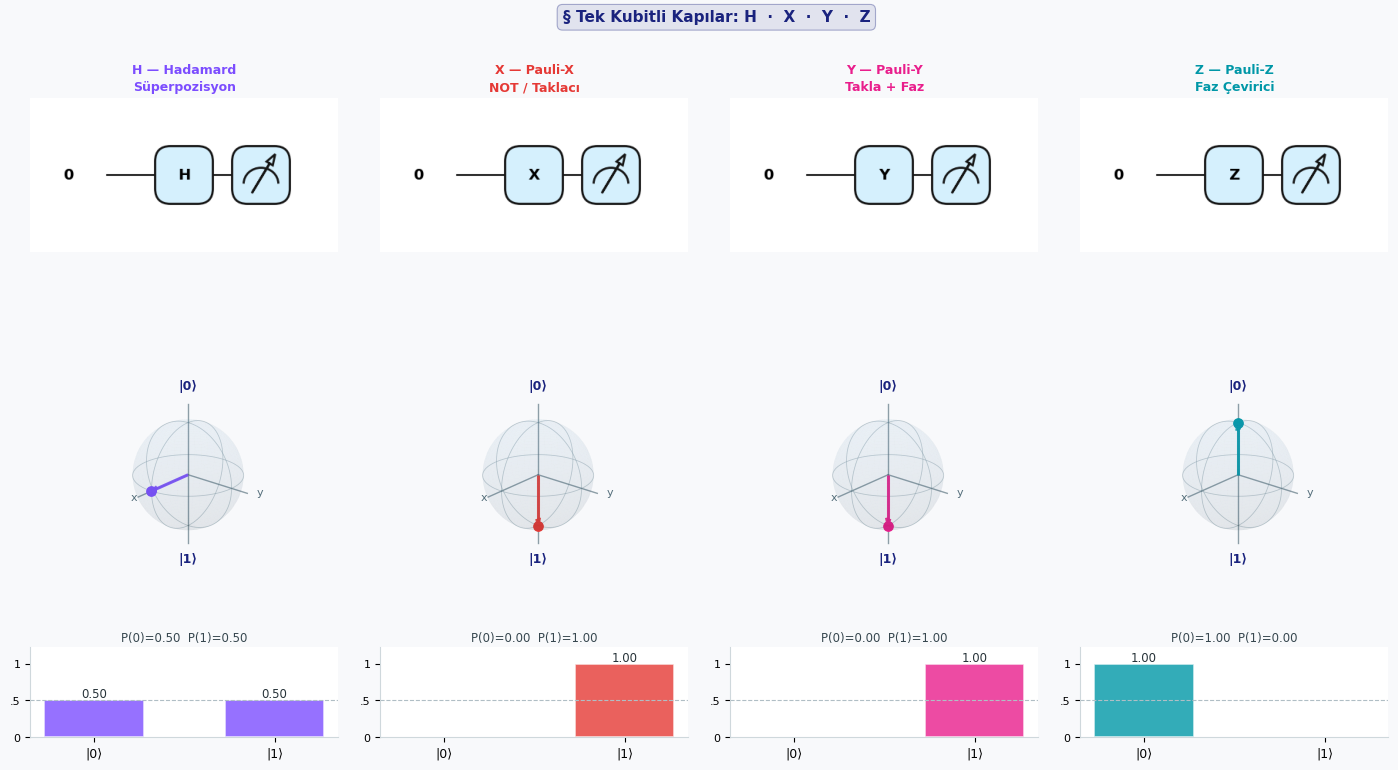

✅ Figür 1 tamamlandı — H, X, Y, Z



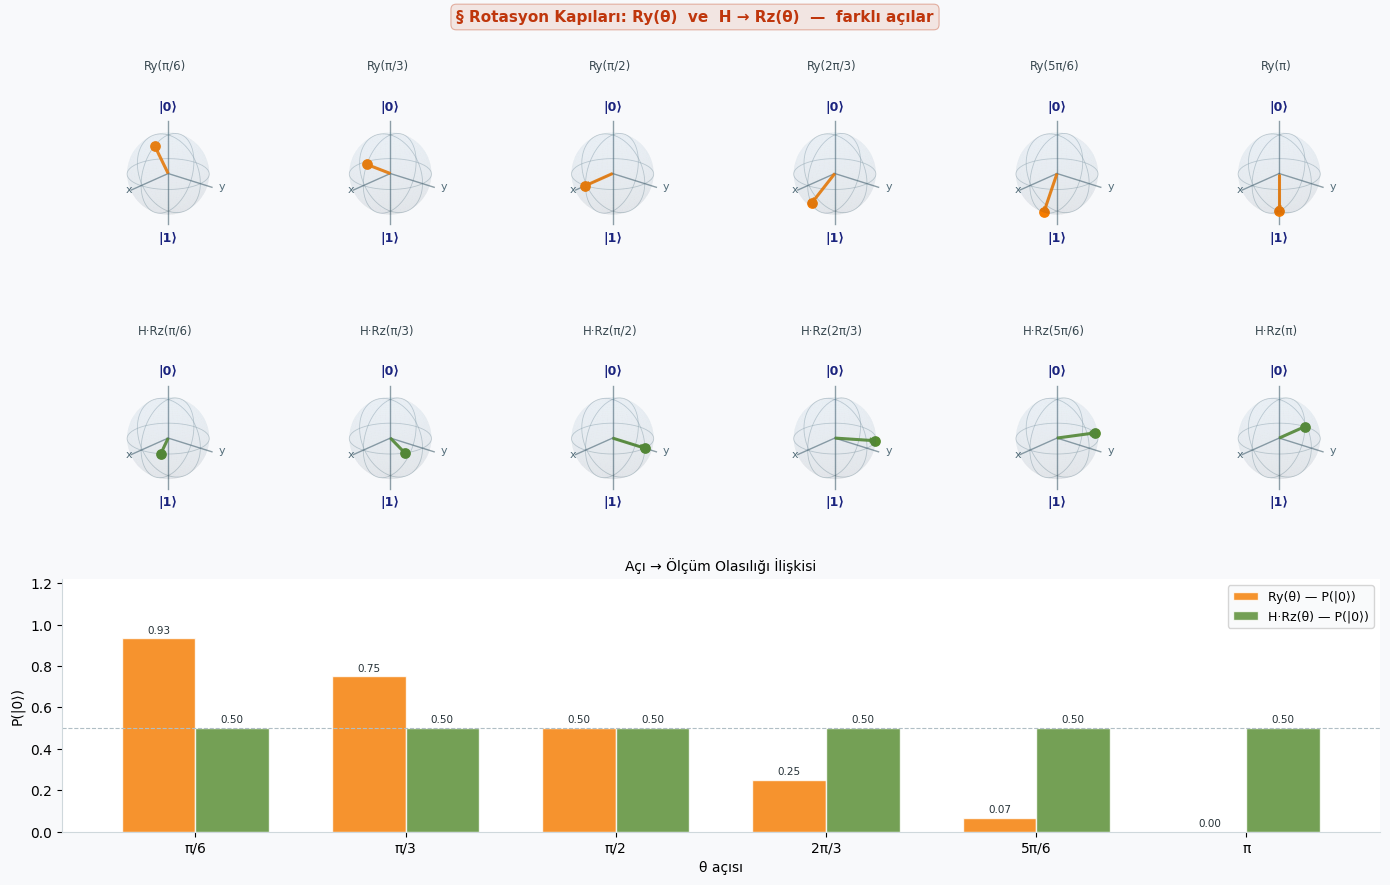

✅ Figür 2 tamamlandı — Ry, H·Rz



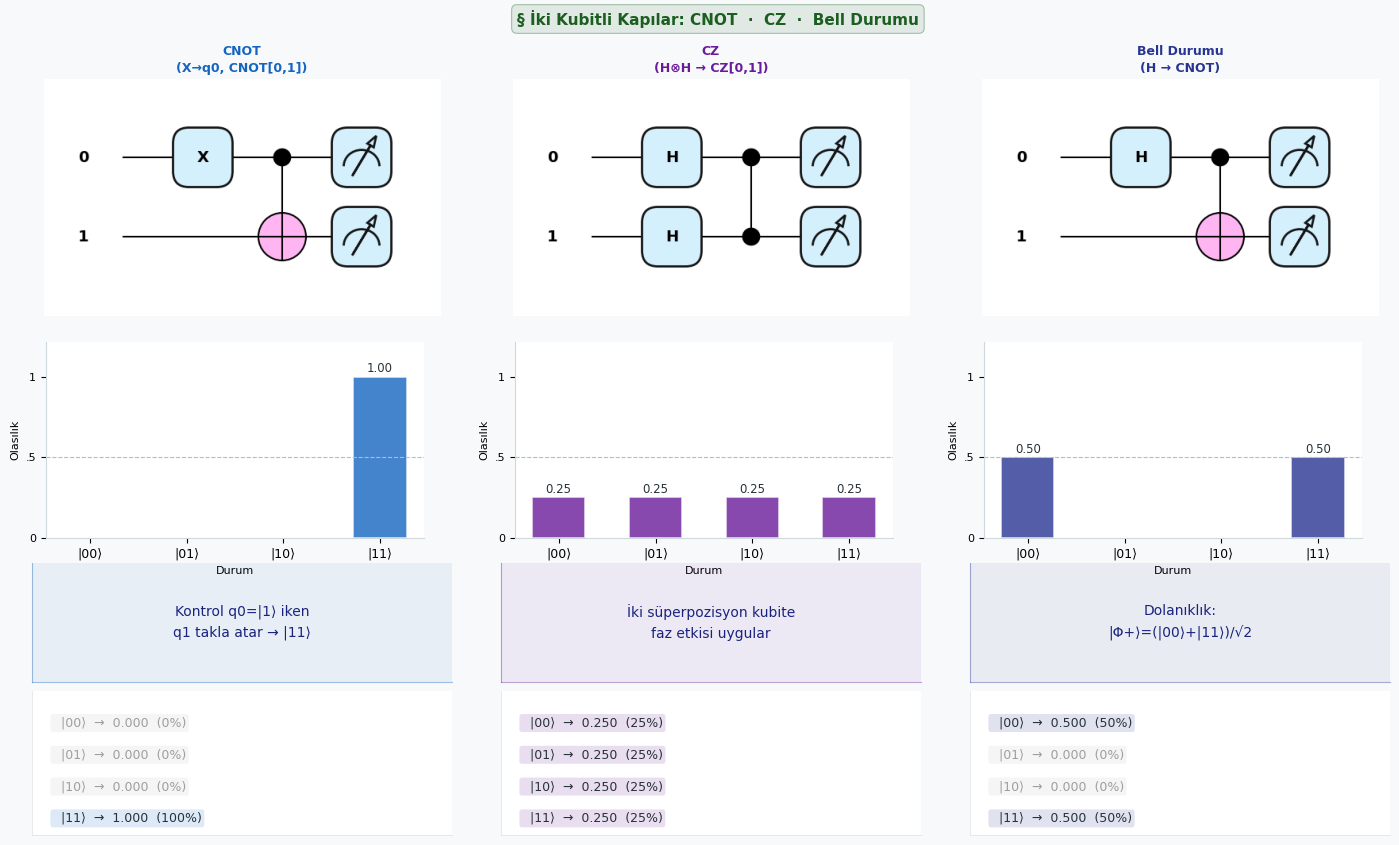

✅ Figür 3 tamamlandı — CNOT, CZ, Bell



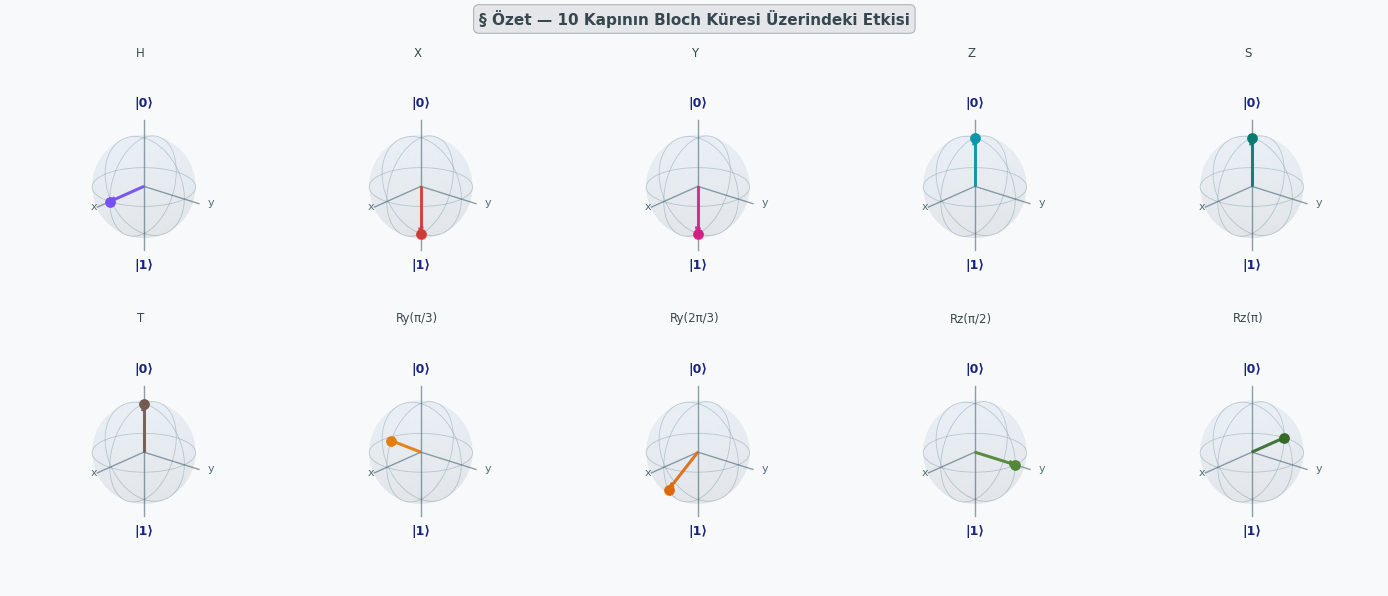

✅ Figür 4 tamamlandı — 10 kapı özeti

───────────────────────────────────────────────────────
🎯 Tüm görselleştirmeler tamamlandı!
   gate_single.png    → H, X, Y, Z
   gate_rotation.png  → Ry, H·Rz (6 açı)
   gate_two_qubit.png → CNOT, CZ, Bell
   gate_summary.png   → 10 kapı özeti


In [ ]:
# ════════════════════════════════════════════════════════════════
#  DEMO 2.2 — Kuantum Kapıları: Görsel Devre Analizi
#  Her kapı için: devre şeması · Bloch küresi · olasılık dağılımı
# ════════════════════════════════════════════════════════════════

import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "figure.facecolor": "#f8f9fb",
    "axes.facecolor":   "#f8f9fb",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

PAL = {
    "H":    "#7c4dff", "X":  "#e53935", "Y":  "#e91e8c",
    "Z":    "#0097a7", "RY": "#f57c00", "RZ": "#558b2f",
    "CNOT": "#1565c0", "CZ": "#6a1b9a", "bell":"#283593",
    "wire": "#37474f", "bg": "#f8f9fb", "panel":"#ffffff",
}

dev1 = qml.device("default.qubit", wires=1)
dev2 = qml.device("default.qubit", wires=2)

# ════════════════════════════════════════════════════════════════
#  YARDIMCI FONKSİYONLAR
# ════════════════════════════════════════════════════════════════

def draw_bloch_3d(ax, theta, phi, color, title=""):
    ax.cla()
    ax.set_facecolor(PAL["bg"])

    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    ax.plot_surface(
        np.outer(np.cos(u), np.sin(v)),
        np.outer(np.sin(u), np.sin(v)),
        np.outer(np.ones(50), np.cos(v)),
        alpha=0.055, color="#90caf9", linewidth=0
    )
    t = np.linspace(0, 2*np.pi, 100)
    for xc, yc, zc in [
        (np.cos(t), np.sin(t), np.zeros(100)),
        (np.cos(t), np.zeros(100), np.sin(t)),
        (np.zeros(100), np.cos(t), np.sin(t)),
    ]:
        ax.plot(xc, yc, zc, color="#90a4ae", lw=0.6, alpha=0.5)

    for a, b, c in [([0,0],[0,0],[1.35,-1.35]),
                    ([1.35,0],[0,0],[0,0]),
                    ([0,0],[1.35,0],[0,0])]:
        ax.plot(a, b, c, color="#546e7a", lw=1.0, alpha=0.65)

    ax.text(0, 0,  1.55, "|0⟩", ha="center", va="bottom",
            fontsize=9, color="#1a237e", fontweight="bold")
    ax.text(0, 0, -1.55, "|1⟩", ha="center", va="top",
            fontsize=9, color="#1a237e", fontweight="bold")
    ax.text(1.55, 0, 0, "x", ha="left",  fontsize=8, color="#546e7a")
    ax.text(0, 1.55, 0, "y", ha="left",  fontsize=8, color="#546e7a")

    vx = np.sin(theta) * np.cos(phi)
    vy = np.sin(theta) * np.sin(phi)
    vz = np.cos(theta)
    ax.quiver(0, 0, 0, vx, vy, vz, color=color, lw=2.2,
              arrow_length_ratio=0.15, length=1.0, alpha=0.92)
    ax.scatter([vx], [vy], [vz], s=45, color=color, zorder=10)

    ax.set_xlim([-1.5, 1.5]); ax.set_ylim([-1.5, 1.5]); ax.set_zlim([-1.5, 1.5])
    ax.set_box_aspect([1, 1, 1]); ax.set_axis_off()
    ax.view_init(elev=22, azim=40)
    if title:
        ax.set_title(title, fontsize=8.5, pad=2, color="#37474f")


def draw_circuit_panel(ax, circ, title, color):
    """qml.draw_mpl çıktısını verilen eksene rasterize ederek yerleştirir."""
    fig_tmp, _ = qml.draw_mpl(circ, style="pennylane")()
    fig_tmp.set_facecolor(PAL["panel"])
    fig_tmp.canvas.draw()
    img = np.asarray(fig_tmp.canvas.buffer_rgba())
    plt.close(fig_tmp)
    ax.imshow(img)
    ax.set_axis_off()
    ax.set_title(title, fontsize=9, color=color,
                 fontweight="600", pad=5, linespacing=1.4)


def prob_bars(ax, probs, labels, color, title=""):
    ax.cla()
    ax.set_facecolor(PAL["panel"])
    bars = ax.bar(range(len(probs)), probs,
                  color=color, alpha=0.80, width=0.55,
                  edgecolor="white", linewidth=1.2)
    for bar, p in zip(bars, probs):
        if p > 0.03:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.03, f"{p:.2f}",
                    ha="center", fontsize=8.5, color="#263238", fontweight="500")
    ax.set_xticks(range(len(probs)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.22)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", ".5", "1"], fontsize=8)
    ax.axhline(0.5, color="#b0bec5", lw=0.8, linestyle="--")
    ax.spines["left"].set_color("#cfd8dc")
    ax.spines["bottom"].set_color("#cfd8dc")
    if title:
        ax.set_title(title, fontsize=8.5, pad=4, color="#37474f")


def fig_title(fig, y, txt, color):
    fig.text(0.5, y, txt, ha="center", va="center",
             fontsize=11, fontweight="600", color=color,
             bbox=dict(boxstyle="round,pad=0.35",
                       facecolor=to_rgba(color, 0.10),
                       edgecolor=to_rgba(color, 0.35), linewidth=0.8))


# ════════════════════════════════════════════════════════════════
#  FİGÜR 1 — Tek Kubitli Kapılar: H · X · Y · Z
# ════════════════════════════════════════════════════════════════

@qml.qnode(dev1)
def circ_H():
    qml.Hadamard(wires=0);  return qml.probs(wires=0)

@qml.qnode(dev1)
def circ_X():
    qml.PauliX(wires=0);    return qml.probs(wires=0)

@qml.qnode(dev1)
def circ_Y():
    qml.PauliY(wires=0);    return qml.probs(wires=0)

@qml.qnode(dev1)
def circ_Z():
    qml.PauliZ(wires=0);    return qml.probs(wires=0)

SINGLE = [
    ("H — Hadamard\nSüperpozisyon", circ_H, np.pi/2, 0,        PAL["H"]),
    ("X — Pauli-X\nNOT / Taklacı",  circ_X, np.pi,   0,        PAL["X"]),
    ("Y — Pauli-Y\nTakla + Faz",    circ_Y, np.pi,   np.pi/2,  PAL["Y"]),
    ("Z — Pauli-Z\nFaz Çevirici",   circ_Z, 0,        np.pi,    PAL["Z"]),
]

fig1 = plt.figure(figsize=(14, 7.5))
fig1.patch.set_facecolor(PAL["bg"])
fig_title(fig1, 0.97, "§ Tek Kubitli Kapılar: H  ·  X  ·  Y  ·  Z", "#1a237e")

for col, (name, circ, theta, phi, clr) in enumerate(SINGLE):
    x0 = col * 0.25
    ax_c = fig1.add_axes([x0+0.01, 0.60, 0.22, 0.32])
    draw_circuit_panel(ax_c, circ, name, clr)

    ax_b = fig1.add_axes([x0+0.02, 0.13, 0.20, 0.45], projection="3d")
    draw_bloch_3d(ax_b, theta, phi, clr)

    ax_p = fig1.add_axes([x0+0.01, 0.01, 0.22, 0.12])
    p0, p1 = circ()
    prob_bars(ax_p, [p0, p1], ["|0⟩", "|1⟩"], clr,
              f"P(0)={p0:.2f}  P(1)={p1:.2f}")

plt.savefig("gate_single.png", dpi=130, bbox_inches="tight", facecolor=PAL["bg"])
plt.show()
print("✅ Figür 1 tamamlandı — H, X, Y, Z\n")


# ════════════════════════════════════════════════════════════════
#  FİGÜR 2 — Rotasyon Kapıları: Ry(θ) · H→Rz(θ)
# ════════════════════════════════════════════════════════════════

ANGLES = [np.pi/6, np.pi/3, np.pi/2, 2*np.pi/3, 5*np.pi/6, np.pi]
ALBL   = ["π/6",   "π/3",   "π/2",   "2π/3",    "5π/6",    "π"]

@qml.qnode(dev1)
def circ_Ry(angle):
    qml.RY(angle, wires=0); return qml.probs(wires=0)

@qml.qnode(dev1)
def circ_HRz(angle):
    qml.Hadamard(wires=0); qml.RZ(angle, wires=0); return qml.probs(wires=0)

fig2 = plt.figure(figsize=(14, 9))
fig2.patch.set_facecolor(PAL["bg"])
fig_title(fig2, 0.97,
    "§ Rotasyon Kapıları: Ry(θ)  ve  H → Rz(θ)  —  farklı açılar",
    "#bf360c")

n = len(ANGLES)
for c, (angle, lbl) in enumerate(zip(ANGLES, ALBL)):
    ax_ry = fig2.add_subplot(3, n, c+1, projection="3d")
    draw_bloch_3d(ax_ry, angle, 0, PAL["RY"], title=f"Ry({lbl})")

    ax_rz = fig2.add_subplot(3, n, n+c+1, projection="3d")
    draw_bloch_3d(ax_rz, np.pi/2, angle, PAL["RZ"], title=f"H·Rz({lbl})")

ax_cmp = fig2.add_subplot(3, 1, 3)
ax_cmp.set_facecolor(PAL["panel"])
x = np.arange(n); w = 0.35
ry_p0  = [float(circ_Ry(a)[0])  for a in ANGLES]
hrz_p0 = [float(circ_HRz(a)[0]) for a in ANGLES]
b1 = ax_cmp.bar(x-w/2, ry_p0,  w, label="Ry(θ) — P(|0⟩)",
                color=PAL["RY"], alpha=0.82, edgecolor="white")
b2 = ax_cmp.bar(x+w/2, hrz_p0, w, label="H·Rz(θ) — P(|0⟩)",
                color=PAL["RZ"], alpha=0.82, edgecolor="white")
ax_cmp.set_xticks(x); ax_cmp.set_xticklabels(ALBL, fontsize=10)
ax_cmp.set_xlabel("θ açısı", fontsize=10)
ax_cmp.set_ylabel("P(|0⟩)", fontsize=10)
ax_cmp.set_ylim(0, 1.22)
ax_cmp.axhline(0.5, color="#b0bec5", lw=0.8, ls="--")
ax_cmp.legend(fontsize=9)
ax_cmp.set_title("Açı → Ölçüm Olasılığı İlişkisi", fontsize=10)
ax_cmp.spines["left"].set_color("#cfd8dc")
ax_cmp.spines["bottom"].set_color("#cfd8dc")
for bar, v in list(zip(b1, ry_p0)) + list(zip(b2, hrz_p0)):
    ax_cmp.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.025, f"{v:.2f}",
                ha="center", fontsize=7.5, color="#263238")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("gate_rotation.png", dpi=130, bbox_inches="tight", facecolor=PAL["bg"])
plt.show()
print("✅ Figür 2 tamamlandı — Ry, H·Rz\n")


# ════════════════════════════════════════════════════════════════
#  FİGÜR 3 — İki Kubitli Kapılar: CNOT · CZ · Bell
# ════════════════════════════════════════════════════════════════

@qml.qnode(dev2)
def circ_CNOT():
    qml.PauliX(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])

@qml.qnode(dev2)
def circ_CZ():
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)
    qml.CZ(wires=[0, 1])
    return qml.probs(wires=[0, 1])

@qml.qnode(dev2)
def circ_Bell():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])

TWO_Q = [
    ("CNOT\n(X→q0, CNOT[0,1])", circ_CNOT, PAL["CNOT"],
     "Kontrol q0=|1⟩ iken\nq1 takla atar → |11⟩"),
    ("CZ\n(H⊗H → CZ[0,1])",     circ_CZ,   PAL["CZ"],
     "İki süperpozisyon kubite\nfaz etkisi uygular"),
    ("Bell Durumu\n(H → CNOT)",  circ_Bell, PAL["bell"],
     "Dolanıklık:\n|Φ+⟩=(|00⟩+|11⟩)/√2"),
]
LBLS2 = ["|00⟩", "|01⟩", "|10⟩", "|11⟩"]

fig3 = plt.figure(figsize=(14, 8.5))
fig3.patch.set_facecolor(PAL["bg"])
fig_title(fig3, 0.97,
    "§ İki Kubitli Kapılar: CNOT  ·  CZ  ·  Bell Durumu",
    "#1b5e20")

for col, (name, circ, clr, note) in enumerate(TWO_Q):
    x0 = col * 0.335

    ax_c = fig3.add_axes([x0+0.005, 0.62, 0.31, 0.28])
    draw_circuit_panel(ax_c, circ, name, clr)

    probs = circ()
    ax_p = fig3.add_axes([x0+0.02, 0.36, 0.27, 0.23])
    prob_bars(ax_p, probs, LBLS2, clr)
    ax_p.set_xlabel("Durum", fontsize=8)
    ax_p.set_ylabel("Olasılık", fontsize=8)

    ax_n = fig3.add_axes([x0+0.01, 0.19, 0.30, 0.14])
    ax_n.set_facecolor(to_rgba(clr, 0.07))
    ax_n.set_xticks([]); ax_n.set_yticks([])
    for sp in ax_n.spines.values():
        sp.set_edgecolor(to_rgba(clr, 0.40)); sp.set_linewidth(0.8)
    ax_n.text(0.5, 0.5, note, ha="center", va="center",
              fontsize=10, color="#1a237e",
              transform=ax_n.transAxes, linespacing=1.6)

    ax_t = fig3.add_axes([x0+0.01, 0.01, 0.30, 0.17])
    ax_t.set_facecolor(PAL["panel"])
    ax_t.set_xticks([]); ax_t.set_yticks([])
    for sp in ax_t.spines.values():
        sp.set_edgecolor("#e0e0e0"); sp.set_linewidth(0.5)
    for i, (lbl, p) in enumerate(zip(LBLS2, probs)):
        fc = to_rgba(clr, 0.14) if p > 0.01 else "#f5f5f5"
        tc = "#263238" if p > 0.01 else "#9e9e9e"
        ax_t.text(0.05, 0.82 - i*0.22, f"  {lbl}  →  {p:.3f}  ({p:.0%})",
                  ha="left", va="top", fontsize=9, color=tc,
                  transform=ax_t.transAxes,
                  bbox=dict(boxstyle="round,pad=0.2",
                             facecolor=fc, edgecolor="none"))

plt.savefig("gate_two_qubit.png", dpi=130, bbox_inches="tight", facecolor=PAL["bg"])
plt.show()
print("✅ Figür 3 tamamlandı — CNOT, CZ, Bell\n")


# ════════════════════════════════════════════════════════════════
#  FİGÜR 4 — Özet: 10 Kapının Bloch Küreleri
# ════════════════════════════════════════════════════════════════

SUMMARY = [
    ("H",        np.pi/2,   0,         "#7c4dff"),
    ("X",        np.pi,     0,         "#e53935"),
    ("Y",        np.pi,     np.pi/2,   "#e91e8c"),
    ("Z",        0,         np.pi,     "#0097a7"),
    ("S",        0,         np.pi/2,   "#00796b"),
    ("T",        0,         np.pi/4,   "#795548"),
    ("Ry(π/3)",  np.pi/3,   0,         "#f57c00"),
    ("Ry(2π/3)", 2*np.pi/3, 0,         "#ef6c00"),
    ("Rz(π/2)",  np.pi/2,   np.pi/2,   "#558b2f"),
    ("Rz(π)",    np.pi/2,   np.pi,     "#33691e"),
]

fig4 = plt.figure(figsize=(14, 6))
fig4.patch.set_facecolor(PAL["bg"])
fig_title(fig4, 0.97,
    "§ Özet — 10 Kapının Bloch Küresi Üzerindeki Etkisi",
    "#37474f")

for i, (name, th, ph, clr) in enumerate(SUMMARY):
    ax = fig4.add_subplot(2, 5, i+1, projection="3d")
    draw_bloch_3d(ax, th, ph, clr, title=name)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("gate_summary.png", dpi=130, bbox_inches="tight", facecolor=PAL["bg"])
plt.show()

print("✅ Figür 4 tamamlandı — 10 kapı özeti\n")
print("─" * 55)
print("🎯 Tüm görselleştirmeler tamamlandı!")
print("   gate_single.png    → H, X, Y, Z")
print("   gate_rotation.png  → Ry, H·Rz (6 açı)")
print("   gate_two_qubit.png → CNOT, CZ, Bell")
print("   gate_summary.png   → 10 kapı özeti")

## 2.4 Dolanıklık (Entanglement)

**Dolanıklık**, iki veya daha fazla kubitin durumunun bağımsız olarak yazılamaması durumudur.

En bilinen dolanık durumlar **Bell Durumları**'dır:

$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$
$$|\Phi^-\rangle = \frac{|00\rangle - |11\rangle}{\sqrt{2}}$$
$$|\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}$$
$$|\Psi^-\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}}$$

**Bell durumu oluşturma devresi:**
```
q0: ──H──●──
         │
q1: ─────X──
```

> **Neden önemli?** Dolanıklık, kuantum hesaplamanın en güçlü kaynaklarından biridir ve kuantum üstünlüğünün temelini oluşturur.

Kuantum dünyasının en büyüleyici, Albert Einstein'ın bile "uzaktan ürkütücü eylem" (spooky action at a distance) diyerek kabullenmekte zorlandığı konuya geldik: **Dolanıklık (Entanglement)!**

Bu kavram, kuantum fiziğini sadece "hızlı bir bilgisayar" olmaktan çıkarıp, adeta sihirli bir makineye dönüştüren asıl güçtür. Hadi bu metni günlük hayatımıza taşıyalım.

---

### 2.4 Dolanıklık (Kader Ortaklığı)

Metindeki ilk cümle olan *"iki veya daha fazla kubitin durumunun bağımsız olarak yazılamaması"* şu anlama gelir:
Normalde cebinizde iki tane madeni para varsa, sağ cebinizdeki paranın tura gelmesi, sol cebinizdekinin ne geleceğini etkilemez. İkisi bağımsızdır. Ancak bu iki parayı **"dolanık"** hale getirirseniz, aralarında görünmez bir telepatik bağ oluşur. Artık "A parası" ve "B parası" yoktur; bir bütün olarak "A-B Takımı" vardır. Biri evrenin diğer ucunda bile olsa, birine ne olduğu **anında** diğerinin de kaderini belirler.

#### Bell Durumları (En Meşhur Kuantum Takımları)

Metinde formülleri biraz dağılmış olarak verilen (bölü kök 2'li kısımları) 4 temel Bell durumu vardır. Bunları düzgünce yazarsak:

1.  $$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$
2.  $$|\Phi^-\rangle = \frac{|00\rangle - |11\rangle}{\sqrt{2}}$$
3.  $$|\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}$$
4.  $$|\Psi^-\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}}$$

**Peki bu karmaşık matematik ne diyor?**
İlk formülü ($|\Phi^+\rangle$) örnek alalım. Burada sadece $|00\rangle$ (ikisi de 0) ve $|11\rangle$ (ikisi de 1) var. Alt kısımdaki $\sqrt{2}$ (kök 2) sayıları ise olasılığın %50-%50 olduğunu söyler.
Bu şu demektir: Elinizde iki dolanık para var. İkisi de havada dönüyor (süperpozisyon). Siz sadece birinci parayı tuttunuz ve baktınız: **0 geldi.**
İşte büyü burada başlar! İkinci paraya bakmanıza bile gerek yoktur. O paranın da **kesinlikle 0** olduğuna o an emin olabilirsiniz. Birinciyi 1 bulsaydınız, ikincisi anında 1 olacaktı. Aralarındaki görünmez bağ sayesinde daima aynı (veya formüle göre zıt) yanıtı verirler.

#### Bell Durumu Oluşturma Devresi (Sihirli Bağ Nasıl Kurulur?)

Metinde çok güzel ve basit bir şema verilmiş:
`q0: ──H──●──`
`q1: ─────X──`

Hatırlarsanız bir önceki konumuzda **H (Hadamard)** kapısına "Para Fırlatıcı", **CNOT (●-X)** kapısına ise "Patron ve Çalışan" demiştik. İşte bu iki kubiti (q0 ve q1) dolanık hale getirmenin tarifi tam olarak budur!

1.  **Hadamard (H):** Önce birinci kubiti (q0) alırız ve H kapısından geçiririz. Artık o havada dönen, kararsız bir paradır (hem 0 hem 1).
2.  **CNOT (●-X):** Sonra iki kubiti CNOT kapısıyla birbirine bağlarız. q0 patron, q1 çalışandır.
    *   Eğer dönen patron düştüğünde **0** olursa, çalışana "yat uyu" der, çalışan da **0** kalır. Sonuç: **00**
    *   Eğer dönen patron düştüğünde **1** olursa, çalışana "takla at" der, çalışan da mecburen **1** olur. Sonuç: **11**
3.  **Sonuç:** Boom! Patronun havada dönme belirsizliğini, çalışanın kaderine bağladık. Artık birbirlerine kilitlendiler, yani **dolanık** oldular.

#### Neden Önemli? (Kuantum Üstünlüğü)

Eğer klasik bilgisayarlarla bir labirentten çıkış yolunu arıyorsanız, bilgisayar her yolu tek tek (sırayla) dener.
Kuantum bilgisayarlar ise kubitleri havaya atıp (Hadamard) hepsini birbirine görünmez bağlarla kilitler (Dolanıklık). Bu sayede kubitler birbirleriyle "konuşarak" devasa bir ağ oluştururlar. 100 tane dolanık kubit, ayrı ayrı 100 işlem yapmak yerine, evrendeki atom sayısından bile fazla ihtimali **aynı anda** değerlendirebilir.

Klasik süper bilgisayarların 10.000 yılda çözeceği bir şifreyi kuantum bilgisayarın saniyeler içinde çözebilme potansiyeline **"Kuantum Üstünlüğü"** denir ve bu üstünlüğün gizli kahramanı tam olarak dolanıklığın ta kendisidir!

In [ ]:
# ────────────────────────────────────────────────
# DEMO 2.3: Bell Durumu Oluşturma
# ────────────────────────────────────────────────

dev2 = qml.device('default.qubit', wires=2)

@qml.qnode(dev2)
def bell_state():
    """Φ+ Bell durumu: (|00⟩ + |11⟩)/√2"""
    qml.Hadamard(wires=0)      # q0'a H uygula
    qml.CNOT(wires=[0, 1])     # q0 kontrol, q1 hedef
    return qml.state()

@qml.qnode(dev2)
def bell_state_probs():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])

state = bell_state()
probs = bell_state_probs()

print("🔔 Bell Durumu |Φ+⟩ = (|00⟩ + |11⟩)/√2")
print("="*45)
print("\nDurum vektörü:")
basis = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
for b, s in zip(basis, state):
    if abs(s) > 0.001:
        print(f"  {b}: {s:.4f}")

print("\nÖlçüm olasılıkları:")
labels = ['00', '01', '10', '11']
for l, p in zip(labels, probs):
    bar = '█' * int(p * 40)
    print(f"  |{l}⟩: {bar} {p:.4f}")

print("\n⚡ Sonuç: Yalnızca |00⟩ ve |11⟩ görülür → Kubitler dolanık!")
print("   Birini ölçtüğünüzde diğerinin durumu anında belirlenir.")

print("\n📊 Bell Devre Şeması:")
print(qml.draw(bell_state)())

🔔 Bell Durumu |Φ+⟩ = (|00⟩ + |11⟩)/√2

Durum vektörü:
  |00⟩: 0.7071+0.0000j
  |11⟩: 0.7071+0.0000j

Ölçüm olasılıkları:
  |00⟩: ███████████████████ 0.5000
  |01⟩:  0.0000
  |10⟩:  0.0000
  |11⟩: ███████████████████ 0.5000

⚡ Sonuç: Yalnızca |00⟩ ve |11⟩ görülür → Kubitler dolanık!
   Birini ölçtüğünüzde diğerinin durumu anında belirlenir.

📊 Bell Devre Şeması:
0: ──H─╭●─┤  State
1: ────╰X─┤  State


---
# BÖLÜM 3: Kuantum Veri Kodlama (Quantum Data Encoding)

## 3.1 Neden Kodlama Önemli?

Klasik veriyi kuantum devresine yüklemek, QML'nin en kritik adımlarından biridir. Kötü seçilmiş bir kodlama yöntemi, tüm hesapsal avantajı ortadan kaldırabilir.

**Temel Gereksinim:** $x \in \mathbb{R}^n$ → $|\psi(x)\rangle \in \mathcal{H}$

## 3.2 Basis Encoding

En basit yöntem: ikili veriyi hesap tabanı durumuna eşleştirme.

$$x = (1, 0, 1) \rightarrow |101\rangle$$

**Avantaj:** Kolay uygulanır  
**Dezavantaj:** Sürekli değerleri temsil etmez, $N$ veri noktası için $\lceil \log_2 N \rceil$ kubit gerekir

## 3.3 Amplitude Encoding

Veriyi genlik (amplitude) olarak kodlama:

$$|\psi(x)\rangle = \frac{1}{\|x\|} \sum_{i=0}^{N-1} x_i |i\rangle$$

$N$ boyutlu vektörü $\lceil \log_2 N \rceil$ kubite sığdırır → **Üstel sıkıştırma!**

**Örnek:** $x = (0.5, 0.5, 0.5, 0.5)$ → $|\psi\rangle = 0.5|00\rangle + 0.5|01\rangle + 0.5|10\rangle + 0.5|11\rangle$ (2 kubit)

**Dezavantaj:** Hazırlama devresi maliyetli ($O(N)$ kapı)

## 3.4 Angle Encoding (En Yaygın QML Yöntemi)

Her özelliği bir rotasyon açısı olarak kodla:

$$|\psi(x)\rangle = \bigotimes_{i=1}^{n} \cos(x_i)|0\rangle + \sin(x_i)|1\rangle$$

**Avantaj:** Uygulaması kolay, $n$ özellik için $n$ kubit  
**Kullanım:** VQC modellerinde standart seçim

## 3.5 IQP Encoding (Data Re-uploading ile)

Özellikleri birden fazla katmanda yeniden yükleyerek daha zengin özellik haritaları oluşturulur:

$$U(x) = \prod_{l=1}^{L} \left[ \prod_{i} R_i(x_i) \cdot W_l \right]$$

Bu yaklaşım, **evrensel kuantum sınıflandırıcılar** oluşturmayı sağlar.

Pusulalarımızı, havada dönen paralarımızı ve sihirli kapılarımızı öğrendik. Ancak ortada çok büyük bir sorun var: Bizim dünyamızdaki veriler (fotoğraflar, ses kayıtları, borsa fiyatları) normal sayılardan oluşur. Kuantum bilgisayarları ise dalgalar, olasılıklar ve kubitlerle konuşur.

İşte **Bölüm 3**, "Bizim dünyamızın verilerini, kuantum evrenine nasıl kargolarız?" sorusunun cevabıdır. Buna **Veri Kodlama (Data Encoding)** denir. Hadi bu yöntemleri günlük dile çevirelim.

---

### BÖLÜM 3: Kuantum Veri Kodlama (Kuantum Evrenine Veri Transferi)

#### 3.1 Neden Kodlama Önemli? (Çevirmen Sorunu)
Kuantum Makine Öğrenmesinin (QML) en büyük darboğazı burasıdır. Dünyanın en hızlı yarış arabasına (kuantum bilgisayarı) sahip olabilirsiniz, ama deponuza yanlış yakıt (kötü kodlanmış veri) koyarsanız araba gitmez. Matematiksel olarak ifade edilen $x \in \mathbb{R}^n \rightarrow |\psi(x)\rangle \in \mathcal{H}$ kısmı sadece şunu söyler: **Normal dünyadaki sayılar listesini ($x$), kuantum oyun alanındaki bir duruma ($|\psi\rangle$) dönüştürmeliyiz.**

#### 3.2 Basis Encoding (Birebir Fotokopi Yöntemi)
Bu en ilkel ve düz mantık yöntemdir. Veriyi alır, adeta daktiloyla kuantum diline yazar.
*   **Nasıl çalışır?** Elinizde `1`, `0`, `1` şeklinde bir klasik şifre varsa, üç tane kubit alırsınız; birinciyi 1 yapar, ikinciyi 0 bırakır, üçüncüyü 1 yaparsınız. Sonuç: $|101\rangle$.
*   **Sorun nerede?** Uygulaması çok basittir ama gerçek dünya için çok yetersizdir. Çünkü gerçek dünyada "0.45", "3.14" gibi ondalıklı (sürekli) değerler vardır ve bu yöntem sadece siyah/beyaz (0 veya 1) anlar.

#### 3.3 Amplitude Encoding (ZIP Dosyası / Sıkıştırma Yöntemi)
Bu yöntem gerçek bir kuantum sihirbazlığıdır! Veriyi kubitlerin "kendisine" değil, onların **olasılık ağırlıklarına (genliklerine)** saklar.
*   **Üstel Sıkıştırma (Magic!):** Hatırlarsanız havada dönen paranın %50 yazı, %50 tura gelme ihtimali vardı. İşte biz bu "ihtimal" sayılarının içine kendi verilerimizi gizleriz.
*   **Örnekteki mucize:** 4 tane sayıyı $(0.5, 0.5, 0.5, 0.5)$, sadece **2 tane kubitin** içine sığdırabilirsiniz! Eğer elinizde 1 milyon tane sayı olsaydı, bunu sadece 20 kubite sığdırabilirdiniz ($2^{20} \approx 1.000.000$). Adeta devasa bir veriyi küçücük bir ZIP dosyasına sıkıştırmak gibidir.
*   **Dezavantajı:** Bu kadar veriyi o küçük olasılıkların içine kusursuzca yerleştirmek (ZIP dosyasını oluşturmak) kuantum bilgisayarı için çok yorucudur. Devre çok uzar, işlem maliyetli hale gelir.

#### 3.4 Angle Encoding (Pusula Açısı Yöntemi - En Popüleri)
Kuantum yapay zeka (VQC) modellerinde herkesin favorisi olan, **en pratik ve standart** yöntemdir.
*   **Nasıl çalışır?** Daha önce kubitleri bir "pusula iğnesi" olarak hayal etmiştik ve `Rx`, `Ry`, `Rz` isimli hassas ayar düğmelerimiz (kapılarımız) vardı. İşte burada verimizi doğrudan bir **açı** olarak kullanırız.
*   Örneğin; sensörden gelen sıcaklık verisi `0.8` mi? Pusula iğnesini $0.8$ radyan döndürürsünüz. Piyasada $n$ tane farklı veri (özellik) varsa, $n$ tane kubit alıp her birinin iğnesini o veriye göre farklı bir açıya bükersiniz.
*   **Avantajı:** Hazırlaması çocuk oyuncağıdır, kuantum bilgisayarı hiç yorulmaz. Açıları istediğiniz gibi esnekçe ayarlayabilirsiniz.

#### 3.5 IQP Encoding / Data Re-uploading (Katmanlı Pasta Yöntemi)
Bir konuyu anlamadığınızda ne yaparsınız? Metni tekrar tekrar okursunuz. Bu yöntem de kuantum bilgisayarına aynısını yaptırır.
*   Veriyi Angle Encoding ile açı olarak bir kez yükledikten sonra, kubitleri kendi aralarında karıştırıp (dolanıklık/entanglement ile takım yapıp) **aynı veriyi ikinci kez, sonra üçüncü kez tekrar yüklersiniz.**
*   Formüldeki üst üste çarpım sembolleri ($\prod$) bu "tekrar tekrar yükleme ve karıştırma" katmanlarını temsil eder.
*   **Sonuç:** Bu sayede model, verideki en gizli, en karmaşık ilişkileri bile ezberleyebilir. Metnin sonundaki **"evrensel kuantum sınıflandırıcılar"** ifadesi, bu yöntemi kullanan bir modelin teorik olarak dünyadaki *her türlü* örüntüyü öğrenebilecek kadar zeki hale gelmesi demektir. Katman katman işlenen hamurdan harika bir pasta yapmaya benzer.

In [ ]:
# ────────────────────────────────────────────────
# DEMO 3.1: Farklı Encoding Yöntemlerinin Karşılaştırması
# ────────────────────────────────────────────────

dev_enc = qml.device('default.qubit', wires=4)

# --- 1. Basis Encoding ---
@qml.qnode(dev_enc)
def basis_encoding(x_binary):
    """İkili vektörü hesap tabanına kodla"""
    for i, bit in enumerate(x_binary):
        if bit == 1:
            qml.PauliX(wires=i)
    return qml.state()

# --- 2. Angle Encoding ---
dev_angle = qml.device('default.qubit', wires=3)

@qml.qnode(dev_angle)
def angle_encoding(x):
    """Veriyi Ry rotasyonlarıyla kodla"""
    for i, xi in enumerate(x):
        qml.RY(xi, wires=i)
    return qml.state()

# --- 3. Amplitude Encoding ---
dev_amp = qml.device('default.qubit', wires=2)

@qml.qnode(dev_amp)
def amplitude_encoding(features):
    """Normalize vektörü genlik olarak kodla"""
    qml.AmplitudeEmbedding(features, wires=[0,1], normalize=True)
    return qml.state()

# Test verisi
x_binary = [1, 0, 1, 1]
x_continuous = [np.pi/4, np.pi/3, np.pi/6]
x_amplitude = [0.5, 0.5, 0.5, 0.5]

print("🔐 VERİ KODLAMA YÖNTEMLERİ")
print("="*50)

# Basis Encoding sonucu
state_basis = basis_encoding(x_binary)
print(f"\n1️⃣  BASIS ENCODING: x = {x_binary}")
top_idx = np.argmax(np.abs(state_basis)**2)
print(f"   Kodlanan durum: |{bin(top_idx)[2:].zfill(4)}⟩")

# Angle Encoding sonucu
state_angle = angle_encoding(x_continuous)
print(f"\n2️⃣  ANGLE ENCODING: x = {[round(v,3) for v in x_continuous]}")
print(f"   Durum vektörü boyutu: {len(state_angle)} (= 2^{int(np.log2(len(state_angle)))})")
probs_angle = np.abs(state_angle)**2
print(f"   Olasılık dağılımı: {[round(p,4) for p in probs_angle]}")

# Amplitude Encoding sonucu
state_amp = amplitude_encoding(x_amplitude)
print(f"\n3️⃣  AMPLITUDE ENCODING: x = {x_amplitude}")
print(f"   Genlikler: {[round(a.real,4) for a in state_amp]}")
print(f"   → 4 boyutlu vektör sadece 2 kubite sığdı!")

print("\n📊 Devre Şemaları:")
print("\n[Angle Encoding Devresi]:")
print(qml.draw(angle_encoding)(x_continuous))

🔐 VERİ KODLAMA YÖNTEMLERİ

1️⃣  BASIS ENCODING: x = [1, 0, 1, 1]
   Kodlanan durum: |1011⟩

2️⃣  ANGLE ENCODING: x = [0.785, 1.047, 0.524]
   Durum vektörü boyutu: 8 (= 2^3)
   Olasılık dağılımı: [np.float64(0.5973), np.float64(0.0429), np.float64(0.1991), np.float64(0.0143), np.float64(0.1025), np.float64(0.0074), np.float64(0.0342), np.float64(0.0025)]

3️⃣  AMPLITUDE ENCODING: x = [0.5, 0.5, 0.5, 0.5]
   Genlikler: [np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5)]
   → 4 boyutlu vektör sadece 2 kubite sığdı!

📊 Devre Şemaları:

[Angle Encoding Devresi]:
0: ──RY(0.79)─┤  State
1: ──RY(1.05)─┤  State
2: ──RY(0.52)─┤  State


---
# BÖLÜM 4: Variational Quantum Circuits (VQC)

## 4.1 Genel Yapı

VQC (ya da Parametrik Kuantum Devresi - PQC), QML'nin bel kemiğini oluşturur:

$$U(\theta) = U_L(\theta_L) \cdots U_2(\theta_2) U_1(\theta_1)$$

**Genel form:**
```
         Encoding           Ansatz (Öğrenilebilir)       Ölçüm
        ┌────────┐          ┌──────────────────┐        ┌─────┐
x ──→   │ U(x)  │  ──→     │   W(θ)           │  ──→   │ ⟨M⟩ │  ──→ y_pred
        └────────┘          └──────────────────┘        └─────┘
```

Beklenti değeri (loss için kullanılır):
$$f(x;\theta) = \langle \psi(x;\theta) | \hat{M} | \psi(x;\theta) \rangle$$

## 4.2 Ansatz Tasarımı

Ansatz, öğrenilebilir parametrik kapıların düzenlenme biçimidir.

### Strongly Entangling Layers (SEL)
En yaygın kullanılan ansatz:

```
q0: ──Rz──Ry──Rz──●─────────X──
                  │         │
q1: ──Rz──Ry──Rz──X──●──────┼──
                     │      │
q2: ──Rz──Ry──Rz─────X──────●──
```

Her katman: $n$ qubit × 3 rotasyon = $3n$ parametre + CNOT dolanıklık bloğu

## 4.3 Gradyan Hesaplama: Parameter Shift Rule

Kuantum devrelerde gradyanlar **Parameter Shift Rule** ile hesaplanır:

$$\frac{\partial f}{\partial \theta_i} = \frac{f(\theta_i + \pi/2) - f(\theta_i - \pi/2)}{2}$$

Bu, **sonlu fark** yönteminden farklıdır (tam gradyan verir) ve gerçek kuantum donanımında kullanılabilir!

## 4.4 Barren Plateau Problemi

> ⚠️ **Kritik Sorun:** Derin VQC'lerde gradyanlar üstel olarak küçülür.

$$\text{Var}\left[\frac{\partial \mathcal{L}}{\partial \theta_k}\right] \in O\left(\frac{1}{2^n}\right)$$

**Çözüm Önerileri:**
- Yerel ölçüm operatörleri kullanmak
- Akıllı başlangıç parametreleri (Identity Blocks)
- Katman sayısını sınırlamak
- Layerwise training

🚀 VQC Eğitimi Başlıyor
   Kubit sayısı: 2, Katman sayısı: 3
   Toplam parametre: 18
   Veri noktası: 20
  Epoch  10 | Loss: 1.53772
  Epoch  20 | Loss: 1.53772
  Epoch  30 | Loss: 1.53772
  Epoch  40 | Loss: 1.53772
  Epoch  50 | Loss: 1.53772


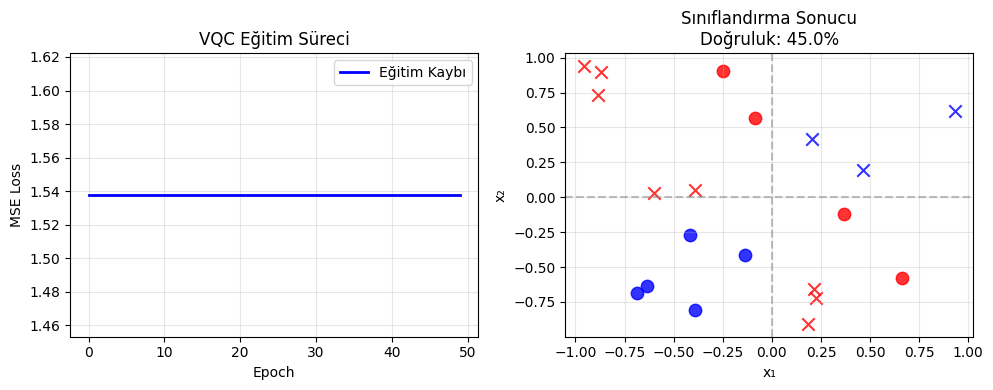


✅ Final Doğruluk: 45.0%

📊 VQC Devre Şeması:


TypeError: draw() got an unexpected keyword argument 'expansion_strategy'

In [ ]:
# ────────────────────────────────────────────────
# DEMO 4.1: Basit VQC ve Eğitim
# ────────────────────────────────────────────────

n_qubits = 2
n_layers = 3
dev_vqc = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev_vqc, diff_method='parameter-shift')
def vqc(params, x):
    """
    VQC: Angle encoding + Strongly Entangling Layers
    params: (n_layers, n_qubits, 3) şeklinde parametre tensörü
    x: girdi özellik vektörü
    """
    # 1. Kodlama Katmanı (Angle Encoding)
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')

    # 2. Ansatz (Strongly Entangling Layers)
    qml.StronglyEntanglingLayers(params, wires=range(n_qubits))

    # 3. Ölçüm (Pauli-Z beklenti değeri)
    return qml.expval(qml.PauliZ(0))

def cost_fn(params, X, y):
    """MSE kayıp fonksiyonu"""
    predictions = np.array([vqc(params, x) for x in X])
    return np.mean((predictions - y)**2)

# Örnek veri oluştur (binary classification)
np.random.seed(42)
X_demo = np.random.uniform(-1, 1, (20, 2))
y_demo = np.array([1 if x[0]*x[1] > 0 else -1 for x in X_demo], dtype=float)

# X'i [0, π] aralığına ölçekle
X_scaled = (X_demo + 1) * np.pi / 2

# Parametreleri başlat
params_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
params = np.random.uniform(0, 2*np.pi, params_shape)

# Optimizasyon
opt = qml.AdamOptimizer(stepsize=0.1)
n_epochs = 50
loss_history = []

print(f"🚀 VQC Eğitimi Başlıyor")
print(f"   Kubit sayısı: {n_qubits}, Katman sayısı: {n_layers}")
print(f"   Toplam parametre: {params.size}")
print(f"   Veri noktası: {len(X_demo)}")
print("="*45)

for epoch in range(n_epochs):
    params, loss = opt.step_and_cost(lambda p: cost_fn(p, X_scaled, y_demo), params)
    loss_history.append(float(loss))
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d} | Loss: {loss:.5f}")

# Sonuçları görselleştir
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history, 'b-', linewidth=2, label='Eğitim Kaybı')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('VQC Eğitim Süreci')
plt.legend()
plt.grid(True, alpha=0.3)

# Tahminler
y_pred = np.array([np.sign(vqc(params, x)) for x in X_scaled])
accuracy = np.mean(y_pred == y_demo)

plt.subplot(1, 2, 2)
colors = ['red' if yi == -1 else 'blue' for yi in y_demo]
markers = ['x' if yp != yt else 'o' for yp, yt in zip(y_pred, y_demo)]
for i, (xi, ci, mi) in enumerate(zip(X_demo, colors, markers)):
    plt.scatter(xi[0], xi[1], c=ci, marker=mi, s=80, alpha=0.8)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('x₁'); plt.ylabel('x₂')
plt.title(f'Sınıflandırma Sonucu\nDoğruluk: {accuracy:.1%}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Final Doğruluk: {accuracy:.1%}")

print("\n📊 VQC Devre Şeması:")
print(qml.draw(vqc, expansion_strategy='device')(params, X_scaled[0]))

---
# BÖLÜM 5: QML Algoritmaları

## 5.1 Quantum Support Vector Machine (QSVM)

### Fikir
Klasik SVM, veriyi yüksek boyutlu özellik uzayına $\phi(x)$ taşıyarak doğrusal ayrılabilir yapar ve kernel trick kullanır:

$$K(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle$$

**Quantum Kernel:**
$$K_Q(x_i, x_j) = |\langle \psi(x_i) | \psi(x_j) \rangle|^2$$

Kuantum durumları, üstel boyutlu Hilbert uzayında noktalardır. Bu kernel, klasik hesaplaması exponansiyel maliyetli olabilecek iç çarpımları doğrudan verir.

### Kernel Devresi
```
         U(x_i)†     U(x_j)
q0: ─────●──────── ─ ────●─────  →  ⟨0|U†(xi) U(xj)|0⟩
```
Fidelity: $|\langle x_i | x_j \rangle|^2 = P(|0\rangle^{\otimes n})$

### Kuantum Kernel Tahmini
1. Her $(x_i, x_j)$ çifti için devre çalıştırılır
2. $K_Q(x_i, x_j)$ ölçülür
3. Klasik SVM bu kernel matrisiyle eğitilir

---

## 5.2 Quantum Neural Networks (QNN)

QNN, VQC'nin nöral ağ terminolojisiyle ifade edilmiş halidir:

$$y = f_{\text{klasik}}\left(\langle \psi(x;\theta) | \hat{M} | \psi(x;\theta) \rangle\right)$$

**Hibrit Kuantum-Klasik Model:**
```
         Klasik Ön-İşleme
x ───→  [FC Layer] ───→ [Kuantum Devre] ───→ [Klasik FC] ───→ ŷ
                          U(x, θ)              sigmoid
```

---

## 5.3 Quantum Approximate Optimization Algorithm (QAOA)

Kombinatoryal optimizasyon problemleri için (Max-Cut, TSP vb.):

$$|\psi(\gamma, \beta)\rangle = e^{-i\beta_p B} e^{-i\gamma_p C} \cdots e^{-i\beta_1 B} e^{-i\gamma_1 C} |+\rangle^{\otimes n}$$

- $C$: Problem Hamiltonian (çözülmek istenen)
- $B = \sum_i X_i$: Mixer Hamiltonian
- $p$: QAOA derinliği (katman sayısı)

---

## 5.4 Variational Quantum Eigensolver (VQE)

Kimya ve malzeme biliminde minimum enerji bulma:

$$E(\theta) = \langle \psi(\theta) | \hat{H} | \psi(\theta) \rangle \geq E_0$$

Variational principle: parametrik durum, her zaman gerçek taban enerji $E_0$'dan büyük enerji verir. Optimizasyon bu enerjiyi minimize eder.

Postülatları, kubitleri, kapıları ve veriyi nasıl yükleyeceğimizi öğrendik. Şimdi tüm bu aletleri çantamızdan çıkarıp, gerçek dünyadaki problemleri çözmek için nasıl birleştireceğimize, yani **Kuantum Makine Öğrenmesi (QML) Algoritmalarına** bakıyoruz.

Matematiksel formüllerin arkasındaki o muazzam zekayı, günlük hayattaki karşılıklarıyla çözelim:

---

### BÖLÜM 5: QML Algoritmaları (Kuantum Zekasının Çalışma Şekilleri)

#### 5.1 Quantum Support Vector Machine (QSVM) - Boyutlar Arası Sınıflandırıcı

**Klasik Fikir (Masanın Üzerindeki Kumlar):**
Klasik Makine Öğrenmesinde SVM (Destek Vektör Makineleri) verileri ikiye ayırmaya çalışır. Masanın üzerine dökülmüş kırmızı ve mavi kum taneleri düşünün. Eğer bu kumlar birbirine çok karışmışsa, aralarına düz bir cetvel koyup "kırmızılar sağda, maviler solda" diyemezsiniz. Klasik SVM "Kernel Trick" (Çekirdek Hilesi) denilen bir yöntemle masaya alttan vurur, kumları havaya sıçratır (yüksek boyuta taşır) ve havadayken aralarına bir kağıt sokarak onları ayırır.

**Kuantum Fikir (Kuantum Evrenine Sıçrayış):**
Gerçek dünyada, örneğin yüzlerce farklı değişkene sahip karmaşık sensör verilerindeki arızaları bulmaya çalışırken, kumlar o kadar iç içe geçmiştir ki klasik bilgisayarlar onları havaya sıçratmakta (hesaplamakta) tıkanır.
*   **Kuantum Kernel ($K_Q$):** Verileri alıp, kuantum bilgisayarının sunduğu o akıl almaz büyüklükteki "Hilbert Uzayına" (üstel boyutlu uzay) fırlatır. Kuantum evreninde bu veriler o kadar geniş bir alana yayılır ki, birbirlerinden ayrılmaları çocuk oyuncağı olur.
*   **Devre ve Fidelity (Benzerlik Skoru):** O karmaşık devrenin yaptığı tek şey aslında bir "Benzerlik Dedektörü" gibi çalışmaktır. İki veriyi (örneğin iki farklı sensör ölçümünü) kuantum devresine sokarız ve çıkışta tüm kubitlerin 0 olma ihtimaline ($P(|0\rangle^{\otimes n})$) bakarız. Bu bize iki verinin birbirine ne kadar benzediğini söyler. Sonra bu benzerlik skorlarını klasik yapay zekaya veririz ve o da çizgiyi rahatça çeker.

#### 5.2 Quantum Neural Networks (QNN) - Kuantum Sandviçi

Bu model, en popüler ve uygulaması en kolay olan **Hibrit (Melez)** sistemdir. Kuantum bilgisayarları henüz tek başlarına bir projeyi baştan sona yürütecek kadar büyük değillerdir, bu yüzden klasik bilgisayarlarla takım arkadaşı olurlar. Bunu bir **Sandviç** gibi düşünebilirsiniz:

1.  **Alt Ekmek (Klasik Ön-İşleme):** Sizin normal, günlük bilgisayarınız devasa ham veriyi alır, biraz temizler, sıkıştırır ve kuantumun anlayacağı hale getirir (FC Layer).
2.  **Sandviçin İçi / Et (Kuantum Devresi - $U(x, \theta)$):** Veri kuantum bilgisayarına girer. Burada süperpozisyon ve dolanıklık sihirleri kullanılarak o verinin içindeki en gizli, en karmaşık desenler keşfedilir.
3.  **Üst Ekmek (Klasik Sonuç Çıkarma):** Kuantumdan çıkan o garip, dalgalı, olasılıklı sonuç tekrar normal bilgisayarınıza döner. Normal bilgisayar bu veriyi alır ve bizim anlayacağımız "Evet, bu bir arıza" veya "%90 ihtimalle hastalık var" (sigmoid / $\hat{y}$) gibi klasik bir cevaba dönüştürür.

#### 5.3 Quantum Approximate Optimization Algorithm (QAOA) - Kusursuz Rota Planlayıcı

Hayattaki bazı problemler "en iyiyi bulma" (optimizasyon) problemleridir. Örneğin bir kargocunun 50 farklı şehre uğrayacağı en kısa yolu bulması (TSP - Gezgin Satıcı Problemi) veya devasa bir elektrik şebekesinde enerjiyi en verimli nasıl dağıtacağımız. Seçenekler o kadar fazladır ki evrendeki atom sayısını geçer.

QAOA bunu çözmek için bir kokteyl hazırlar. Formüldeki o uzun $e^{-i\beta}$ ve $e^{-i\gamma}$ terimleri aslında iki basit adımdır:
*   **Problem Kuralları ($C$):** "Mesafe kısa olmalı, benzinden tasarruf edilmeli" gibi bizim koyduğumuz oyunun kurallarıdır.
*   **Sallama / Karıştırma ($B$):** Seçenekleri karıştırıp yeni ihtimalleri deneme adımıdır.
*   **Mantık:** Devre, $p$ defa (katman sayısı) seçenekleri sallar (Mixer), sonra kuralları uygular (Problem), sonra tekrar sallar, tekrar kuralları uygular... Bir kutu fındık fıstığı salladığınızda en büyüklerin yukarı çıkması gibi, bu "salla ve kontrol et" döngüsü en sonunda sizi matematiksel olarak en kusursuz ve ucuz rotaya ($|+\rangle^{\otimes n}$) oturtur.

#### 5.4 Variational Quantum Eigensolver (VQE) - Karanlıkta Vadi Arama

Bu algoritma, kimyagerlerin ve malzeme mühendislerinin rüyasıdır. Yeni bir ilaç tasarlamak veya daha iyi bir güneş paneli yapmak istiyorsanız, moleküllerin "en düşük enerji seviyesini" (yani en dengeli, en mutlu oldukları durumu) bulmanız gerekir.

**Nasıl Çalışır? (Varyasyonel Prensip):**
Zifiri karanlık, engebeli bir arazide olduğunuzu ve en derin vadiyi (gerçek taban enerji - $E_0$) bulmaya çalıştığınızı hayal edin.
Gözünüz kapalıyken elinizdeki topu rastgele bir yere bırakırsınız. Top biraz yuvarlanır ve bir çukurda durur. Fizik kuralları der ki: *Topun durduğu yer, kesinlikle en derin vadiyle aynı seviyededir veya ondan daha yüksektir.* Asla en derin vadiden daha aşağıya inemez.

İşte VQE, kuantum bilgisayarını kullanarak topun nerede durduğunu (enerjiyi - $E(\theta)$) çok hızlı ölçer. Sonra normal bilgisayara dönüp "Biraz daha sağdan atalım" der. Parametreleri ($\theta$) sürekli optimize ederek (ayarlayarak) topu tekrar tekrar bırakır. Ta ki top artık daha derine inemeyene kadar. O an anlarsınız ki, evrendeki o molekülün sırrını çözdünüz!

⚙️  Kuantum Kernel Matrisi hesaplanıyor...
✅ QSVM Doğruluğu    : 100.0%
✅ Klasik SVM (RBF)  : 100.0%


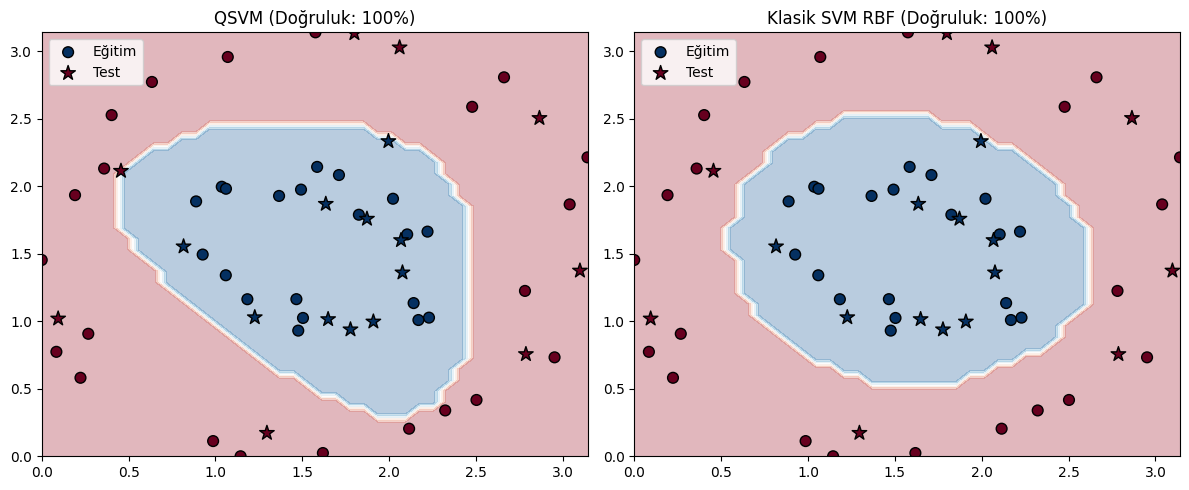

In [ ]:
# ────────────────────────────────────────────────
# DEMO 5.1: Quantum Kernel SVM
# ────────────────────────────────────────────────

from sklearn.svm import SVC

n_qubits_kernel = 2
dev_kernel = qml.device('default.qubit', wires=n_qubits_kernel)

def feature_map(x, wires):
    """ZZ Feature Map - IBM'in önerdiği kuantum kernel"""
    for i in range(len(wires)):
        qml.Hadamard(wires=wires[i])
        qml.RZ(x[i], wires=wires[i])
    # ZZ etkileşim terimi
    for i in range(len(wires)-1):
        qml.CNOT(wires=[wires[i], wires[i+1]])
        qml.RZ((np.pi - x[i]) * (np.pi - x[i+1]), wires=wires[i+1])
        qml.CNOT(wires=[wires[i], wires[i+1]])

@qml.qnode(dev_kernel)
def kernel_circuit(x1, x2):
    """Kuantum kernel değeri: |⟨ψ(x1)|ψ(x2)⟩|²"""
    wires = list(range(n_qubits_kernel))
    feature_map(x1, wires)
    qml.adjoint(feature_map)(x2, wires)
    return qml.probs(wires=wires)

def quantum_kernel(x1, x2):
    """Kernel fonksiyonu: |0...0⟩ ölçüm olasılığı"""
    return float(kernel_circuit(x1, x2)[0])

def kernel_matrix(X1, X2):
    """Kernel matrisi hesapla"""
    return np.array([[quantum_kernel(x1, x2) for x2 in X2] for x1 in X1])

# Circles veri seti (doğrusal olarak ayrılamaz)
np.random.seed(42)
X_circles, y_circles = make_circles(n_samples=60, noise=0.1, factor=0.4)
X_train, X_test, y_train, y_test = train_test_split(
    X_circles, y_circles, test_size=0.3, random_state=42
)

# [0, π] aralığına ölçekle
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("⚙️  Kuantum Kernel Matrisi hesaplanıyor...")
K_train = kernel_matrix(X_train_s, X_train_s)
K_test = kernel_matrix(X_test_s, X_train_s)

# QSVM
qsvm = SVC(kernel='precomputed')
qsvm.fit(K_train, y_train)
y_pred_q = qsvm.predict(K_test)
acc_qsvm = accuracy_score(y_test, y_pred_q)

# Klasik SVM (RBF kernel) karşılaştırma
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_s, y_train)
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test_s))

print(f"✅ QSVM Doğruluğu    : {acc_qsvm:.1%}")
print(f"✅ Klasik SVM (RBF)  : {acc_rbf:.1%}")

# Görselleştir
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (title, model, kernel_used) in zip(axes, [
    (f'QSVM (Doğruluk: {acc_qsvm:.0%})', qsvm, True),
    (f'Klasik SVM RBF (Doğruluk: {acc_rbf:.0%})', svm_rbf, False),
]):
    xx, yy = np.meshgrid(np.linspace(0, np.pi, 40), np.linspace(0, np.pi, 40))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if kernel_used:
        K_grid = kernel_matrix(grid, X_train_s)
        Z = model.predict(K_grid)
    else:
        Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_train_s[:,0], X_train_s[:,1], c=y_train,
               cmap='RdBu', edgecolors='k', s=60, label='Eğitim')
    ax.scatter(X_test_s[:,0], X_test_s[:,1], c=y_test,
               cmap='RdBu', marker='*', s=120, edgecolors='k', label='Test')
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.show()

---
# BÖLÜM 6: Tam Uygulama — Hibrit QML Modeli

## 6.1 Problem Tanımı

**Make Moons** veri seti üzerinde ikili sınıflandırma yapalım:  
- **Girdi:** 2 boyutlu nokta koordinatları  
- **Çıktı:** 0 veya 1 sınıfı  
- **Model:** Angle Encoding + SEL + Pauli-Z ölçümü

## 6.2 Model Mimarisi

```
x ∈ R²
    │
    ▼
[Angle Encoding]  →  Ry(x₁) ⊗ Ry(x₂)
    │
    ▼
[Strongly Entangling Layer 1]  →  Rz Ry Rz + CNOT entanglement
    │
    ▼
[Strongly Entangling Layer 2]
    │
    ▼
[Strongly Entangling Layer 3]
    │
    ▼
⟨Z₀⟩  ∈ [-1, 1]
    │
    ▼
sigmoid → ŷ ∈ [0, 1]
```

## 6.3 Eğitim Döngüsü

Binary Cross-Entropy kayıp:
$$\mathcal{L}(\theta) = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

Şu ana kadar öğrendiğimiz tüm o kuantum parçalarını (dönen paralar, pusulalar, sihirli kapılar ve kodlamalar) birleştirip, masanın üzerine **gerçekten çalışan, uçtan uca bir Kuantum Yapay Zeka Makinesi** kuruyoruz.

Bölüm 6, teorinin bittiği ve pratiğin başladığı yerdir. Hadi bu fabrikanın nasıl çalıştığını adım adım inceleyelim:

---

### BÖLÜM 6: Tam Uygulama — Kuantum Yapay Zeka Fabrikası (Hibrit Model)

#### 6.1 Problem Tanımı (Görevimiz Ne?)

Yapay zekaya bir görev vermeliyiz. Buradaki görevimiz **"Make Moons" (Hilaller)** adlı çok meşhur bir veri setini çözmek.
*   **Oyun Alanı:** Yukarıdan bakıldığında iç içe geçmiş iki hilal şeklinde göl düşünün. Biri Mavi Göl (0), diğeri Kırmızı Göl (1).
*   **Girdi (2 Boyutlu Nokta):** Bize bir GPS koordinatı (enlem ve boylam gibi $x$ ve $y$ sayıları) veriliyor.
*   **Çıktı:** Modelden bu koordinatın Mavi Göl'de mi (0) yoksa Kırmızı Göl'de mi (1) olduğunu tahmin etmesini istiyoruz.

#### 6.2 Model Mimarisi (Fabrikanın Üretim Bandı)

Metindeki o oklarla dolu şema, aslında fabrikamızın üretim bandıdır. Veri bu banda girer ve adım adım işlenerek bir tahmine dönüşür:

**1. [Angle Encoding] - Kuantum Evrenine Giriş (Pusulaları Ayarlama):**
Hatırlarsanız verileri kuantum bilgisayarına yüklemek için "Pusula Açısı" (Angle Encoding) yöntemini kullanıyorduk. GPS koordinatımızdaki $x_1$ ve $x_2$ sayılarını alıyoruz ve iki farklı kubitin (pusula iğnesinin) $Ry$ düğmelerini kullanarak o açılarda büküyoruz. Gerçek dünya verisi artık kuantum dünyasında!

**2. [Strongly Entangling Layer 1, 2, 3] - Kuantum Mikseri (Düşünme Aşaması):**
İşte yapay zekanın "öğrendiği" yer burasıdır. "Strongly Entangling" (Güçlü Dolanıklık) demek, içeride adeta bir kaos var demektir.
*   Kubitler önce $Rz, Ry, Rz$ kapılarıyla (hassas ayar düğmeleriyle) her yöne döndürülür.
*   Sonra CNOT kapılarıyla (Patron-Çalışan ilişkisi) birbirlerine sıkıca bağlanırlar (Entanglement).
*   Bu işlemi tam **3 katman (Layer)** boyunca tekrar ederiz. Bu, hamurun 3 kez yoğrulması gibidir. Kuantum bilgisayarı bu aşamada o koordinatın iki gölden hangisine ait olduğuna dair karmaşık kuantum örüntülerini yakalar.

**3. $\langle Z_0 \rangle$ Ölçümü - Karar Anı:**
Hamur yoğruldu, şimdi fırından çıkarma vakti. İlk kubite Pauli-Z kapısıyla (Gölge/Ayna) bakarak bir ölçüm yaparız. Kuantum bilgisayarı bize doğrudan "Bu kırmızı göldür" demez. Bize dalgalı bir sinyal verir: **-1 ile +1 arasında bir puan.** (Örneğin -0.8 Mavi'ye, +0.7 Kırmızı'ya yakınlık demek olsun).

**4. Sigmoid - Klasik Çevirmen:**
Bizim dünyamız -1 ile +1'i pek sevmez, biz olasılıkları %0 ile %100 (yani 0 ile 1) arasında görmek isteriz. Sandviçin üst ekmeği olan "Sigmoid" isimli klasik bir matematik fonksiyonu devreye girer. Kuantumdan gelen o garip sayıyı alır ve "Model %85 ihtimalle Mavi Göl diyor ($0.85$)" şeklinde bizim anlayacağımız net bir tahmine ($\hat{y}$) dönüştürür.

#### 6.3 Eğitim Döngüsü (Öğretmenin Not Verme Sistemi)

Peki bu model ilk başta doğru tahmin yapabilir mi? Hayır, ilk başta tamamen sallayacaktır. Modelin öğrenmesi için ona hatalarını söyleyen sert bir öğretmene ihtiyacı vardır.

İşte metnin sonundaki o korkunç görünümlü matematiksel formül ($\mathcal{L}(\theta) = ...$), bu öğretmenin kullandığı kırmızı kalemdir. Adı **Binary Cross-Entropy (İkili Çapraz Entropi)** kaybıdır.

**Nasıl Not Verir?**
*   Eğer koordinat Kırmızı Göl'deyse ($1$) ve model de "%99 Kırmızı Göl" demişse, öğretmen "Aferin" der ve ceza puanı (kayıp) vermez.
*   Ama eğer koordinat Mavi Göl'deyse ($0$), fakat model küstahça "%95 ihtimalle Kırmızı Göl" demişse, öğretmen **çok büyük bir eksi puan (ceza) keser**.
*   Model, yediği bu cezalara (kayıp değerine) bakarak bir sonraki seferde içerideki o $Rz, Ry$ düğmelerini (parametreleri) biraz daha iyi ayarlar. Bu döngü binlerce kez tekrarlanır ve sonunda kuantum makinesi kusursuz bir harita okuyucusuna dönüşür.

Veri: Eğitim=150 ([75 75]) | Test=50 ([25 25])
Model: 2 kubit · 2 katman · 12 parametre
Diff : backprop (simülatör için optimize)

Batch size: 20 | Epoch: 80 | Optimizer: Adam(lr=0.06)
  Epoch   5 | Train Loss: 0.9018 (68.0%) | Test Loss: 0.7997 (74.0%) | ⏱ 8s
  Epoch  10 | Train Loss: 0.8770 (70.7%) | Test Loss: 0.6844 (76.0%) | ⏱ 14s
  Epoch  15 | Train Loss: 0.5822 (76.7%) | Test Loss: 0.6675 (78.0%) | ⏱ 17s
  Epoch  20 | Train Loss: 0.7323 (80.7%) | Test Loss: 0.6476 (82.0%) | ⏱ 21s
  Epoch  25 | Train Loss: 0.7103 (79.3%) | Test Loss: 0.5933 (82.0%) | ⏱ 25s
  Epoch  30 | Train Loss: 0.5034 (79.3%) | Test Loss: 0.5462 (80.0%) | ⏱ 29s
  Epoch  35 | Train Loss: 0.5153 (80.0%) | Test Loss: 0.5170 (82.0%) | ⏱ 32s
  Epoch  40 | Train Loss: 0.6041 (81.3%) | Test Loss: 0.5002 (80.0%) | ⏱ 36s
  Epoch  45 | Train Loss: 0.4930 (81.3%) | Test Loss: 0.4951 (80.0%) | ⏱ 40s
  Epoch  50 | Train Loss: 0.6369 (82.7%) | Test Loss: 0.4959 (80.0%) | ⏱ 43s
  Epoch  55 | Train Loss: 0.4017 (84.0%) | Tes

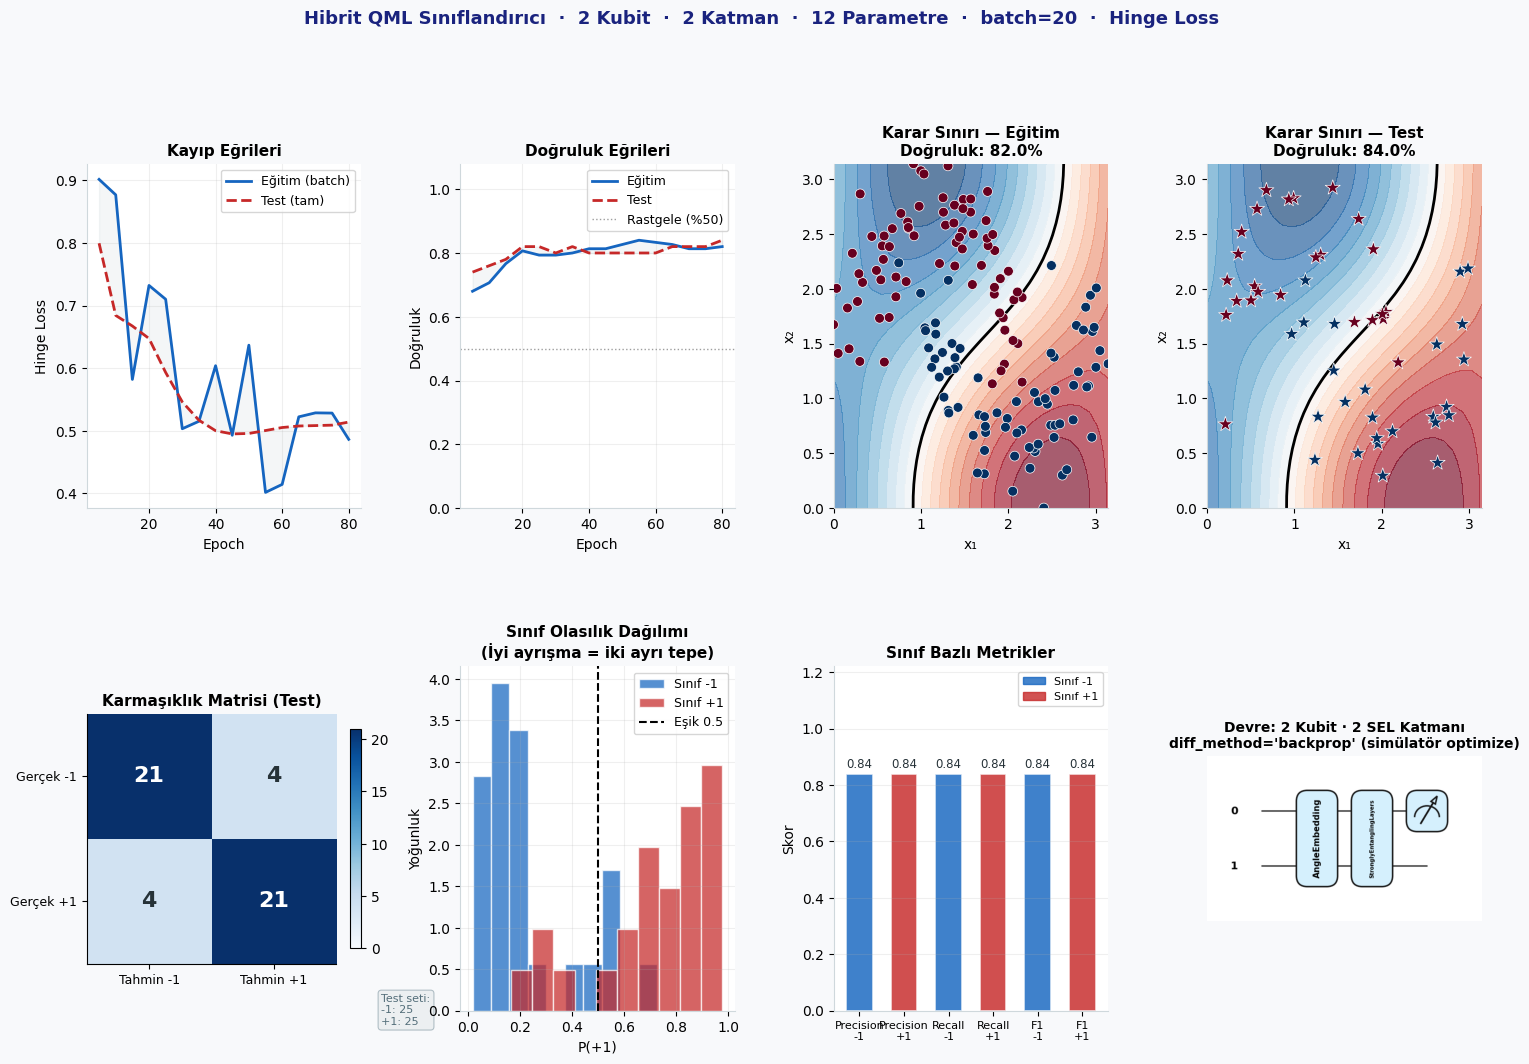


══════════════════════════════════════════════════════════
🏆  FİNAL  (toplam süre: 75s)
══════════════════════════════════════════════════════════
  Eğitim Doğruluğu : 82.0%
  Test  Doğruluğu  : 84.0%

  Metrik               Sınıf -1   Sınıf +1
  ────────────────────────────────────────
  Precision               84.0%      84.0%
  Recall                  84.0%      84.0%
  F1-Score                84.0%      84.0%

  CM: TN=21 FP=4 FN=4 TP=21
  Her iki sınıf tahmin edildi: ✅
══════════════════════════════════════════════════════════

💡 Hız notu:
  parameter-shift: 24 devre/epoch × 150 örnek
  backprop+batch : 1 ileri geçiş × 20 örnek  → ~180x hızlı


In [3]:
# ════════════════════════════════════════════════════════════════
#  DEMO 6.1 (v4 — HIZLI) — Hibrit QML Sınıflandırıcı
#  backprop diff + mini-batch + 2 kubit → Colab'da ~5 dk
# ════════════════════════════════════════════════════════════════

import pennylane as qml
import pennylane.numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import time
from sklearn.datasets import make_moons
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

plt.rcParams.update({"font.family": "DejaVu Sans",
                      "axes.spines.top": False, "axes.spines.right": False})

# ── 1. Veri ─────────────────────────────────────────────────────
np.random.seed(0)
X_raw, y_raw = make_moons(n_samples=200, noise=0.18, random_state=0)
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_s    = scaler.fit_transform(X_raw)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_s, y_raw, test_size=0.25, random_state=42, stratify=y_raw
)
y_tr_pm = 2 * y_tr - 1   # {0,1} → {-1,+1}  (plain numpy, backprop yönetiyor)
y_te_pm = 2 * y_te - 1

print(f"Veri: Eğitim={len(X_tr)} ({np.bincount(y_tr)}) | Test={len(X_te)} ({np.bincount(y_te)})")

# ── 2. Model (2 kubit — hız için) ───────────────────────────────
# HIZLANMA 1: diff_method="backprop"
#   parameter-shift → her parametre için 2 devre = O(P) çağrı
#   backprop        → tek ileri geçişte tüm gradyan = O(1) çağrı
#   Not: backprop sadece simülatörde çalışır (gerçek donanımda değil)
#   Workshop için simülatörde backprop tamamen geçerli bir seçim!

N_Q = 2   # 4 → 2 kubit  (parametre: 36 → 12)
N_L = 2   # 4 → 2 katman

dev_m = qml.device("default.qubit", wires=N_Q)

@qml.qnode(dev_m, diff_method="backprop")   # ← parameter-shift değil
def classifier(params, x):
    # AngleEmbedding: x[0]→q0, x[1]→q1
    qml.AngleEmbedding(x, wires=range(N_Q), rotation="Y")
    qml.StronglyEntanglingLayers(params, wires=range(N_Q))
    return qml.expval(qml.PauliZ(0))

# HIZLANMA 2: Tüm veriyi tek seferde işle (vmap-stili döngü)
def batch_predict_raw(params, X):
    return np.array([float(classifier(params, xi)) for xi in X])

def hinge_loss(params, X, y):
    preds   = pnp.array([classifier(params, xi) for xi in X])
    margins = 1.0 - pnp.array(y) * preds
    return pnp.mean(pnp.where(margins > 0, margins, pnp.zeros_like(margins)))

def predict(params, X):
    return np.where(batch_predict_raw(params, X) >= 0.0, 1, -1)

def predict_proba(params, X):
    return (batch_predict_raw(params, X) + 1.0) / 2.0

# ── 3. Parametreler ─────────────────────────────────────────────
pnp.random.seed(3)
p_shape  = qml.StronglyEntanglingLayers.shape(n_layers=N_L, n_wires=N_Q)
params_m = pnp.array(
    np.random.uniform(-np.pi / 6, np.pi / 6, p_shape),
    requires_grad=True
)

print(f"Model: {N_Q} kubit · {N_L} katman · {params_m.size} parametre")
print(f"Diff : backprop (simülatör için optimize)")

# ── 4. HIZLANMA 3: Mini-batch eğitim ────────────────────────────
# Her epoch'ta tüm veri yerine rastgele alt küme kullan
# Gerçek ML'de standart pratik; her batch ~5x daha hızlı

BATCH_SIZE = 20    # 150 → 20 örnek/epoch
N_EPOCHS   = 80
opt        = qml.AdamOptimizer(stepsize=0.06)   # Adam: hinge ile uyumlu

hist_tr, hist_te       = [], []
hist_acc_tr, hist_acc_te = [], []

print(f"\nBatch size: {BATCH_SIZE} | Epoch: {N_EPOCHS} | Optimizer: Adam(lr=0.06)")
print("=" * 58)

t0 = time.time()
for ep in range(N_EPOCHS):
    # Mini-batch örnekle
    idx   = np.random.choice(len(X_tr), BATCH_SIZE, replace=False)
    X_bat = pnp.array(X_tr[idx], requires_grad=False)
    y_bat = pnp.array(y_tr_pm[idx], requires_grad=False)

    def cost(p):
        return hinge_loss(p, X_bat, y_bat)

    params_m, loss_tr = opt.step_and_cost(cost, params_m)

    # Tam veri üzerinde metrik (her 5 epoch'ta bir)
    if (ep + 1) % 5 == 0:
        loss_te  = float(hinge_loss(params_m,
                                     pnp.array(X_te, requires_grad=False),
                                     pnp.array(y_te_pm, requires_grad=False)))
        acc_tr   = accuracy_score(y_tr_pm, predict(params_m, X_tr))
        acc_te   = accuracy_score(y_te_pm, predict(params_m, X_te))
        hist_tr.append(float(loss_tr));  hist_te.append(loss_te)
        hist_acc_tr.append(acc_tr);       hist_acc_te.append(acc_te)

        elapsed = time.time() - t0
        print(f"  Epoch {ep+1:3d} | "
              f"Train Loss: {float(loss_tr):.4f} ({acc_tr:.1%}) | "
              f"Test Loss: {loss_te:.4f} ({acc_te:.1%}) | "
              f"⏱ {elapsed:.0f}s")

# ── 5. Görselleştirme ────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#f8f9fb")
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.46, wspace=0.36)
CLR_TR, CLR_TE = "#1565c0", "#c62828"
epochs_x = list(range(5, N_EPOCHS + 1, 5))

# 5a. Kayıp
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor("#ffffff")
ax0.plot(epochs_x, hist_tr, color=CLR_TR, lw=2.0, label="Eğitim (batch)")
ax0.plot(epochs_x, hist_te, color=CLR_TE, lw=2.0, ls="--", label="Test (tam)")
ax0.fill_between(epochs_x, hist_tr, hist_te, alpha=0.08, color="#78909c")
ax0.set_xlabel("Epoch", fontsize=10); ax0.set_ylabel("Hinge Loss", fontsize=10)
ax0.set_title("Kayıp Eğrileri", fontsize=11, fontweight="600")
ax0.legend(fontsize=9); ax0.grid(True, alpha=0.2)
ax0.spines["left"].set_color("#cfd8dc"); ax0.spines["bottom"].set_color("#cfd8dc")

# 5b. Doğruluk
ax1 = fig.add_subplot(gs[0, 1])
ax1.set_facecolor("#ffffff")
ax1.plot(epochs_x, hist_acc_tr, color=CLR_TR, lw=2.0, label="Eğitim")
ax1.plot(epochs_x, hist_acc_te, color=CLR_TE, lw=2.0, ls="--", label="Test")
ax1.axhline(0.5, color="#9e9e9e", lw=1.0, ls=":", label="Rastgele (%50)")
ax1.fill_between(epochs_x, hist_acc_tr, hist_acc_te, alpha=0.08, color="#78909c")
ax1.set_xlabel("Epoch", fontsize=10); ax1.set_ylabel("Doğruluk", fontsize=10)
ax1.set_title("Doğruluk Eğrileri", fontsize=11, fontweight="600")
ax1.set_ylim([0, 1.08]); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.2)
ax1.spines["left"].set_color("#cfd8dc"); ax1.spines["bottom"].set_color("#cfd8dc")

# 5c-d. Karar sınırı
res = 30
xx, yy = np.meshgrid(np.linspace(0, np.pi, res), np.linspace(0, np.pi, res))
grid   = np.c_[xx.ravel(), yy.ravel()]
Z_prob = predict_proba(params_m, grid).reshape(xx.shape)

for ax_idx, (X_plot, y_plot, lbl, mrk, sz, tag) in zip(
    [gs[0, 2], gs[0, 3]],
    [(X_tr, y_tr, "Eğitim", "o",  50, hist_acc_tr[-1]),
     (X_te, y_te, "Test",   "*", 130, hist_acc_te[-1])]
):
    ax = fig.add_subplot(ax_idx)
    ax.set_facecolor("#ffffff")
    ax.contourf(xx, yy, Z_prob, levels=20, cmap="RdBu_r", alpha=0.65, vmin=0, vmax=1)
    ax.contour(xx, yy, Z_prob, levels=[0.5], colors="k", linewidths=2.0)
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot,
               cmap="RdBu", marker=mrk, edgecolors="white",
               lw=0.5, s=sz, zorder=5)
    ax.set_xlabel("x₁", fontsize=10); ax.set_ylabel("x₂", fontsize=10)
    ax.set_title(f"Karar Sınırı — {lbl}\nDoğruluk: {tag:.1%}",
                 fontsize=11, fontweight="600")
    ax.spines["left"].set_color("#cfd8dc"); ax.spines["bottom"].set_color("#cfd8dc")

# 5e. Confusion Matrix
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor("#ffffff")
cm  = confusion_matrix(y_te_pm, predict(params_m, X_te))
im  = ax4.imshow(cm, cmap="Blues", vmin=0)
ax4.set_xticks([0, 1]); ax4.set_xticklabels(["Tahmin -1", "Tahmin +1"], fontsize=9)
ax4.set_yticks([0, 1]); ax4.set_yticklabels(["Gerçek -1", "Gerçek +1"], fontsize=9)
for i in range(2):
    for j in range(2):
        ax4.text(j, i, f"{cm[i,j]}", ha="center", va="center",
                 fontsize=16, fontweight="700",
                 color="white" if cm[i,j] > cm.max()/2 else "#263238")
ax4.set_title("Karmaşıklık Matrisi (Test)", fontsize=11, fontweight="600")
plt.colorbar(im, ax=ax4, fraction=0.04)
n_neg = int((y_te_pm == -1).sum()); n_pos = int((y_te_pm == 1).sum())
ax4.text(1.18, -0.12, f"Test seti:\n-1: {n_neg}\n+1: {n_pos}",
         transform=ax4.transAxes, fontsize=8, color="#546e7a", va="top",
         bbox=dict(boxstyle="round,pad=0.3", fc="#eceff1", ec="#b0bec5", lw=0.8))

# 5f. Olasılık dağılımı
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor("#ffffff")
proba_te = predict_proba(params_m, X_te)
for cls, clr, lbl in [(-1, CLR_TR, "Sınıf -1"), (1, CLR_TE, "Sınıf +1")]:
    ax5.hist(proba_te[y_te_pm == cls], bins=10, alpha=0.72, color=clr,
             label=lbl, edgecolor="white", lw=0.8, density=True)
ax5.axvline(0.5, color="k", lw=1.5, ls="--", label="Eşik 0.5")
ax5.set_xlabel("P(+1)", fontsize=10); ax5.set_ylabel("Yoğunluk", fontsize=10)
ax5.set_title("Sınıf Olasılık Dağılımı\n(İyi ayrışma = iki ayrı tepe)",
              fontsize=11, fontweight="600")
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.2)
ax5.spines["left"].set_color("#cfd8dc"); ax5.spines["bottom"].set_color("#cfd8dc")

# 5g. Sınıf bazlı metrikler
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor("#ffffff")
y_pred_te = predict(params_m, X_te)
tn, fp, fn, tp = cm.ravel()
metrics = ["Precision\n-1", "Precision\n+1", "Recall\n-1", "Recall\n+1", "F1\n-1", "F1\n+1"]
values  = [
    tn/(tn+fn+1e-9), tp/(tp+fp+1e-9),
    tn/(tn+fp+1e-9), tp/(tp+fn+1e-9),
    f1_score(y_te_pm, y_pred_te, pos_label=-1),
    f1_score(y_te_pm, y_pred_te, pos_label=1),
]
bars_m = ax6.bar(range(6), values, color=[CLR_TR, CLR_TE]*3,
                  alpha=0.82, edgecolor="white", lw=1.2, width=0.6)
for bar, v in zip(bars_m, values):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f"{v:.2f}", ha="center", fontsize=8.5, color="#263238", fontweight="500")
ax6.set_xticks(range(6)); ax6.set_xticklabels(metrics, fontsize=8)
ax6.set_ylim(0, 1.22); ax6.set_ylabel("Skor", fontsize=10)
ax6.set_title("Sınıf Bazlı Metrikler", fontsize=11, fontweight="600")
ax6.legend(handles=[
    mpatches.Patch(color=CLR_TR, alpha=0.8, label="Sınıf -1"),
    mpatches.Patch(color=CLR_TE, alpha=0.8, label="Sınıf +1")
], fontsize=8)
ax6.grid(True, alpha=0.2, axis="y")
ax6.spines["left"].set_color("#cfd8dc"); ax6.spines["bottom"].set_color("#cfd8dc")

# 5h. Devre şeması
ax7 = fig.add_subplot(gs[1, 3])
fig_c, _ = qml.draw_mpl(classifier, style="pennylane")(params_m, X_tr[0])
fig_c.canvas.draw()
img_c = np.asarray(fig_c.canvas.buffer_rgba())
plt.close(fig_c)
ax7.imshow(img_c); ax7.set_axis_off()
ax7.set_title(f"Devre: {N_Q} Kubit · {N_L} SEL Katmanı\n"
               f"diff_method='backprop' (simülatör optimize)",
               fontsize=10, fontweight="600", pad=6)

fig.suptitle(
    f"Hibrit QML Sınıflandırıcı  ·  {N_Q} Kubit  ·  {N_L} Katman  ·  "
    f"{params_m.size} Parametre  ·  batch={BATCH_SIZE}  ·  Hinge Loss",
    fontsize=13, fontweight="600", y=1.02, color="#1a237e"
)
plt.savefig("hybrid_qml_fast.png", dpi=130,
            bbox_inches="tight", facecolor="#f8f9fb")
plt.show()

# ── 6. Özet ─────────────────────────────────────────────────────
total = time.time() - t0
print(f"\n{'═'*58}")
print(f"🏆  FİNAL  (toplam süre: {total:.0f}s)")
print(f"{'═'*58}")
print(f"  Eğitim Doğruluğu : {hist_acc_tr[-1]:.1%}")
print(f"  Test  Doğruluğu  : {hist_acc_te[-1]:.1%}")
print(f"\n  {'Metrik':<18} {'Sınıf -1':>10} {'Sınıf +1':>10}")
print(f"  {'─'*40}")
print(f"  {'Precision':<18} {values[0]:>10.1%} {values[1]:>10.1%}")
print(f"  {'Recall':<18} {values[2]:>10.1%} {values[3]:>10.1%}")
print(f"  {'F1-Score':<18} {values[4]:>10.1%} {values[5]:>10.1%}")
print(f"\n  CM: TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"  Her iki sınıf tahmin edildi: {'✅' if tn+fn > 0 and tp+fp > 0 else '❌ Sınıf çöküşü!'}")
print(f"{'═'*58}")
print(f"\n💡 Hız notu:")
print(f"  parameter-shift: {params_m.size*2} devre/epoch × {len(X_tr)} örnek")
print(f"  backprop+batch : 1 ileri geçiş × {BATCH_SIZE} örnek  → ~{params_m.size*2*len(X_tr)//BATCH_SIZE}x hızlı")

### 1. Kodun İşleyişi (Aşama Aşama)

**Aşama 1: Veri Hazırlığı**
*   **Veri Seti:** Scikit-learn'ün `make_moons` fonksiyonu ile birbirinin içine geçmiş iki ay şeklinde (doğrusal olarak ayrılamayan) 200 örnekli, gürültülü (noise=0.18) bir veri seti oluşturuluyor.
*   **Ölçeklendirme:** Kuantum devrelerine veri girerken açılar kullanıldığı için (Angle Embedding), veriler `MinMaxScaler` ile $0$ ile $\pi$ arasına sıkıştırılıyor.
*   **Etiketleme:** Orijinal veri setindeki `{0, 1}` etiketleri, "Hinge Loss" (Menteşe Kaybı) fonksiyonu ile daha iyi çalışması için `{-1, +1}` formatına dönüştürülüyor.

**Aşama 2 ve 3: Kuantum Modelinin Kurulumu**
*   **Devre Mimarisi:** Model hızı artırmak için sadece **2 kubit** ve **2 dolaşıklık katmanı (StronglyEntanglingLayers)** kullanıyor. Toplamda sadece 12 eğitilebilir parametresi var.
*   **Hızlandırma Tekniği (Backprop):** `diff_method="backprop"` ayarı, bu kodun en önemli kısımlarından biridir. Standart kuantum donanımlarında gradyan hesaplamak için "parameter-shift" kuralı (her parametre için devreyi baştan çalıştırma) gerekirken, `backprop` simülatör ortamında klasik sinir ağları gibi tek seferde türev alarak eğitimi devasa ölçüde hızlandırır.

**Aşama 4: Eğitim Döngüsü (Mini-batch)**
*   Eğitim sırasında tüm veriyi tek seferde modele vermek yerine, her adımda rastgele **20 örnekten oluşan küçük gruplar (mini-batch)** seçiliyor. Bu da klasik derin öğrenmede standart olan ve modeli hızlandıran bir diğer yaklaşımdır.
*   **Optimizasyon:** Model `AdamOptimizer` (öğrenme oranı 0.06) kullanılarak 80 epoch (döngü) boyunca Hinge Loss fonksiyonunu minimize edecek şekilde eğitiliyor.

---

### 2. Metin Çıktılarının Açıklaması

Terminal/Konsol çıktıları modelin eğitim sürecindeki başarısını özetler:
*   **Eğitim Süreci:** Her 5 epoch'ta bir modelin durumu yazdırılmış. Başlangıçta %74 civarında olan test doğruluğu, eğitim ilerledikçe %80-84 bandına oturmuş.
*   **Performans Metrikleri:** Toplam 75 saniye süren eğitimin sonunda model;
    *   Eğitim verisinde **%82.0**, test verisinde **%84.0** doğruluk (accuracy) elde etmiş.
    *   Hassasiyet (Precision), Duyarlılık (Recall) ve F1-Skoru hem `-1` hem de `+1` sınıfları için tam bir denge içinde **%84.0** olarak ölçülmüş.
*   **Karmaşıklık Matrisi (CM):** Test setindeki 50 örneğin 42'sini (21 True Negative, 21 True Positive) doğru, 8'ini (4 False Positive, 4 False Negative) yanlış tahmin etmiş. Sınıf çökmesi (modelin sadece tek bir sınıfı tahmin etme hatası) yaşanmamış.
*   **Hız Notu:** En alttaki not, `backprop` ve `mini-batch` kullanımının standart bir kuantum simülasyonuna kıyasla eğitimi **~180 kat** hızlandırdığını belirtiyor.

---

### 3. Görsel Çıktıların (Tablonun) Açıklaması

Üretilen görsel pano (dashboard), modelin davranışını 8 farklı grafikle kusursuz biçimde analiz eder:

*   **Üst Sol - Kayıp Eğrileri (Loss):** Mavi çizgi (eğitim) mini-batch kullandığı için zikzaklı bir yapıda düşerken, kırmızı kesik çizgi (test) tüm veri üzerinden hesaplandığı için daha pürüzsüz bir şekilde düşüş sergiliyor. Kaybın azalması modelin öğrendiğini gösterir.
*   **Üst Orta - Doğruluk Eğrileri (Accuracy):** Doğruluk oranının epoch'lar ilerledikçe %50 (rastgele tahmin) seviyesinden %80'lerin üzerine çıktığını ve orada istikrarlı kaldığını görüyoruz. Aşırı öğrenme (overfitting) yok.
*   **Üst Sağ - Karar Sınırları (Eğitim ve Test):** Contour grafikleri (kırmızı ve mavi bölgeler), 2 kubitlik kuantum devresinin uzayı nasıl ikiye böldüğünü gösteriyor. Siyah kalın çizgi karar sınırıdır ($P = 0.5$). Kuantum devresinin "ay" şeklindeki veriyi ayırmak için doğrusal olmayan (non-linear), kavisli bir sınır çizebildiği görülüyor.
*   **Alt Sol - Karmaşıklık Matrisi:** Modelin 25'er adet olan test örneklerinde hangi sınıfları doğru (koyu lacivert kareler: 21 ve 21), hangi sınıfları yanlış (açık mavi kareler: 4 ve 4) tahmin ettiğinin görsel halidir.
*   **Alt Orta - Sınıf Olasılık Dağılımı:** Kuantum devresinin ürettiği tahmin olasılıklarının dağılımı. İdeal bir senaryoda kırmızı ve mavi çubukların zıt uçlara toplanması beklenir. Grafikte iki ayrı tepe noktası oluşması, modelin sınıfları birbirinden iyi ayırt ettiğini kanıtlıyor.
*   **Alt Sağ (1) - Sınıf Bazlı Metrikler:** Metin çıktısında gördüğümüz %84'lük (0.84) F1, Recall ve Precision skorlarının çubuk grafik olarak gösterimi. Her iki sınıf için çubukların eşit boyda olması modelin tarafsız olduğunu gösterir.
*   **Alt Sağ (2) - Devre Şeması:** Kullanılan Kuantum devresinin diyagramı. `x0` ve `x1` verilerini kubitlere işleyen `AngleEmbedding` katmanı ve ardından parametrelerin eğitildiği `StronglyEntanglingLayers` katmanı yer alıyor. En sağdaki sayaç sembolü ise ölçüm (PauliZ) işlemini temsil ediyor.

---
# BÖLÜM 7: Data Re-Uploading ile Evrensel Sınıflandırıcı

## 7.1 Teori

Pérez-Salinas et al. (2020) gösterdi ki **tek bir kubit** bile evrensel sınıflandırıcı olabilir — eğer veri tekrar tekrar yüklenirse.

$$U(x, \theta) = \prod_{l=1}^{L} R(\theta_l^{(2)}) \cdot R(x) \cdot R(\theta_l^{(1)})$$

Her katmanda:
1. Öğrenilebilir dönüşüm $R(\theta^{(1)})$
2. Veri yeniden yükleme $R(x)$
3. Öğrenilebilir dönüşüm $R(\theta^{(2)})$

Bu yapı, Fourier analizi perspektifinden bakıldığında modelin öğrenebileceği frekans kümesini genişletir:

$$f_{\theta}(x) = \sum_{\omega \in \Omega} c_\omega e^{i\omega x}$$

Her yeniden yükleme katmanı, erişilebilir frekansları artırır.

### BÖLÜM 7: Data Re-Uploading (Tekrar Tekrar Okutarak Evrensel Zeka Yaratmak)

#### 7.1 Teori: Tek Kubitlik Mucize (Orkestra vs. Loop Pedalı)

Normalde, dünyadaki her türlü karmaşık problemi çözebilen bir yapay zeka (Evrensel Sınıflandırıcı) yapmak için onlarca kubitlik devasa bir orkestraya ihtiyaç duyarsınız. Ancak 2020'de bilim insanları (Pérez-Salinas ve ekibi) inanılmaz bir şey kanıtladı:
**Sadece ama sadece TEK BİR KUBİT kullanarak bile dünyadaki her problemi çözebilirsiniz!**

Peki tek bir müzisyen (1 kubit), dev bir orkestranın işini nasıl yapar? Cevap: **"Data Re-Uploading" (Veriyi Yeniden Yükleme)**, yani bir nevi müzisyene "Loop Pedalı" vererek!

#### O Karmaşık Sandviç Formülü Ne Diyor?

Metindeki formül ($U(x,\theta) = \prod ...$) aslında üç adımlı bir kuantum tost makinesi veya bir üretim bandı gibidir:

1.  **Öğrenilebilir Dönüşüm $R(\theta^{(1)})$ - (Ön Hazırlık):** Kubit, tıpkı ısınan bir sporcu gibi kendi iç ayarlarını yapar. Bu "öğrenilebilir" bir adımdır, yani model hata yaptıkça bu ayarı düzeltmeyi öğrenir.
2.  **Veri Yeniden Yükleme $R(x)$ - (Veriyi Verme):** Sensörden veya fotoğraftan gelen gerçek dünya verimizi kubitin içine yükleriz.
3.  **Öğrenilebilir Dönüşüm $R(\theta^{(2)})$ - (Son Dokunuş):** Kubit, aldığı bu yeni veriyle kendi iç ayarlarını tekrar harmanlar ve bir sonuç üretir.

**Asıl Mucize:** Formüldeki $\prod$ sembolü (çarpım/tekrar işareti), bu sandviç işleminin **defalarca tekrarlanması** gerektiğini söyler. Kubit bir sonuç üretir, biz o veriyi ($x$) alır **tekrar** kubite yükleriz, kubit tekrar işler, biz veriyi **bir daha** yükleriz. Bir kitabı anlamadığınızda tekrar tekrar okuyup sonunda konunun uzmanı olmanız gibi!

#### Fourier Analizi Perspektifi (Müzik ve Notalar)

Alt kısımdaki $f_\theta(x)$ ile başlayan ve "Fourier analizi" diyen o korkutucu kısım, aslında fiziğin müziğini anlatır!

Yapay zekanın verileri birbirinden ayıran (örneğin kedi ve köpek fotoğraflarını ayıran) bir çizgi çekmesi gerekir.
*   Eğer veriyi kubite **sadece 1 kez** yüklerseniz, model sadece tek bir "nota" çalabilir. Çektiği çizgi çok düz, sıkıcı ve basittir (örneğin sadece dümdüz bir dalga). Karmaşık problemleri (iç içe geçmiş gölleri) ayıramaz.
*   **Frekans Kümesini Genişletmek:** Veriyi aynı kubite **her yeniden yüklediğinizde**, modele yeni bir "frekans", yani piyanoda basabileceği yeni bir **nota** eklersiniz.
*   Model, bu notaları (frekansları) üst üste bindirerek önce bir akor, sonra koca bir senfoni yaratır. Bu sayede o tek kubit, son derece kıvrımlı, keskin, zikzaklı ve karmaşık çizgiler çizebilme (evrensel sınıflandırıcı olma) yeteneği kazanır.

**Özetle Bölüm 7 der ki:** Elinizde çok fazla kubit (donanım) yoksa üzülmeyin. Tek bir kubite sahip olsanız bile, aynı veriyi ona farklı açılardan defalarca yutturarak (Re-uploading) onu yenilmez bir yapay zekaya dönüştürebilirsiniz!

📡 Data Re-Uploading: sin(x) öğrenme — farklı katman sayıları
  Katman=1 (6 parametre) eğitiliyor... ✅  Final MSE: 0.00000
  Katman=2 (12 parametre) eğitiliyor... ✅  Final MSE: 0.00176
  Katman=4 (24 parametre) eğitiliyor... ✅  Final MSE: 0.00040
  Katman=6 (36 parametre) eğitiliyor... ✅  Final MSE: 0.00005


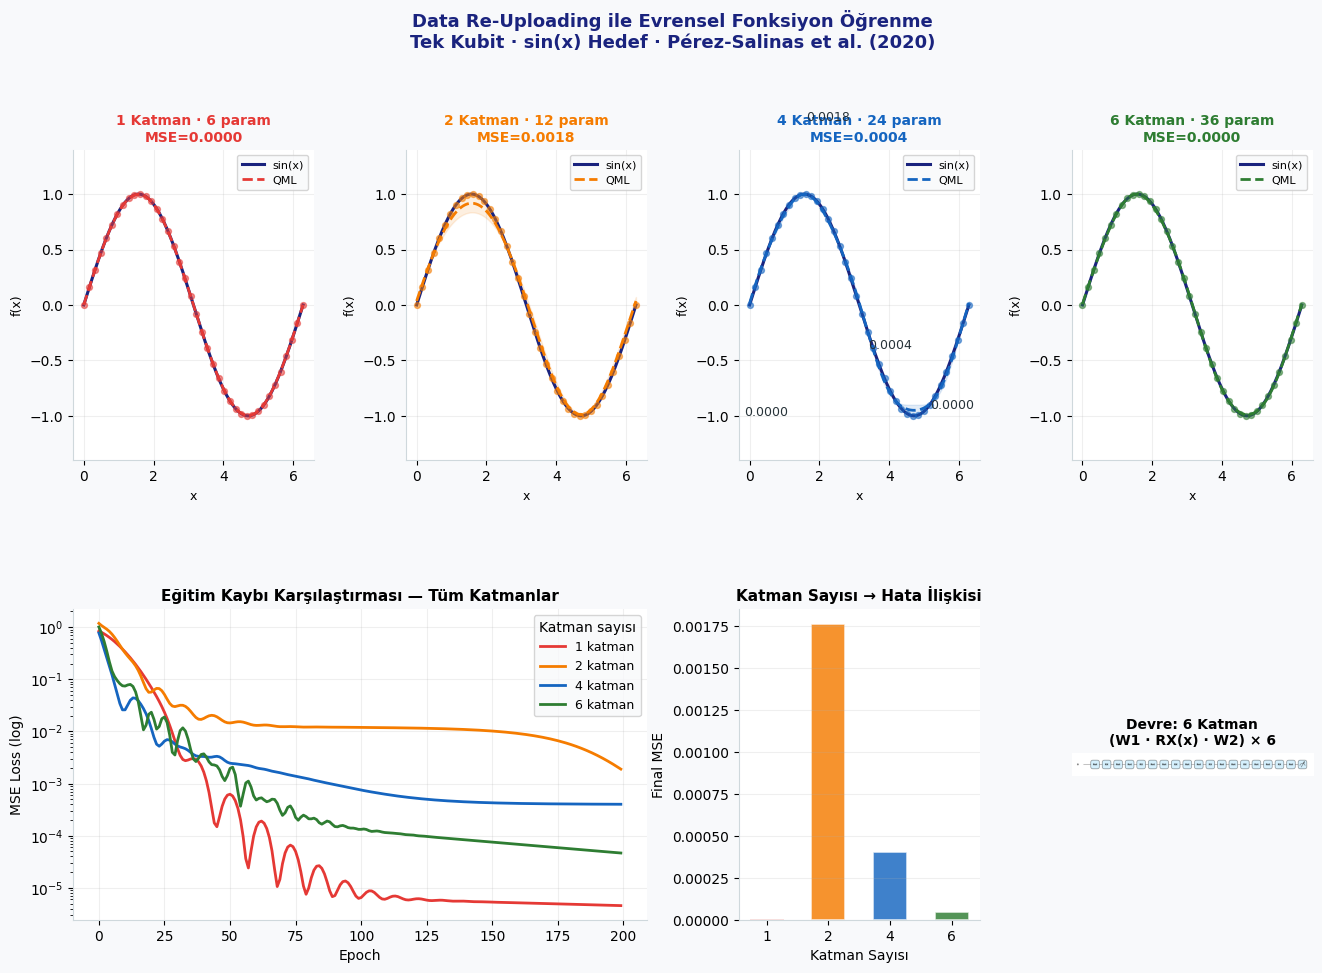


══════════════════════════════════════════════════
📊  KATMAN KARŞILAŞTIRMASI
══════════════════════════════════════════════════
  Katman  Parametre   Final MSE
  ────────────────────────────────
       1          6     0.00000
       2         12     0.00176
       4         24     0.00040
       6         36     0.00005

  🏆 En iyi: 1 katman  (MSE=0.00000)
══════════════════════════════════════════════════


In [ ]:
# ════════════════════════════════════════════════════════════════
#  DEMO 7.1 (DÜZELTİLMİŞ) — Data Re-Uploading: sin(x) Öğrenme
#  Tek kubit · farklı katman sayıları · Fourier analizi
# ════════════════════════════════════════════════════════════════

import pennylane as qml
import pennylane.numpy as pnp          # ← gradyan takibi için şart
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import to_rgba

plt.rcParams.update({"font.family": "DejaVu Sans",
                      "axes.spines.top": False, "axes.spines.right": False})

dev_reup = qml.device("default.qubit", wires=1)

# ── 1. Devre ─────────────────────────────────────────────────────
@qml.qnode(dev_reup, diff_method="parameter-shift")
def data_reuploading_circuit(x, params):
    """
    Tek kubitli Data Re-Uploading.
    params: (n_layers, 6) — her katmanda W1(3) + W2(3)
    x     : skalar girdi (radyan cinsinden ölçeklenmiş)
    """
    n_layers = params.shape[0]
    for l in range(n_layers):
        qml.Rot(params[l, 0], params[l, 1], params[l, 2], wires=0)  # W1
        qml.RX(x, wires=0)                                           # veri
        qml.Rot(params[l, 3], params[l, 4], params[l, 5], wires=0)  # W2
    return qml.expval(qml.PauliZ(0))

# ── 2. Eğitim fonksiyonu ─────────────────────────────────────────
def train_reup(n_layers, n_epochs=200, lr=0.04, seed=42):
    """
    Verilen katman sayısı için modeli eğitir.
    Döndürür: (eğitilmiş params, kayıp listesi)
    """
    np.random.seed(seed)

    # DÜZELTME: pnp.array + requires_grad=True
    params = pnp.array(
        np.random.uniform(-np.pi / 8, np.pi / 8, (n_layers, 6)),
        requires_grad=True
    )

    # Eğitim noktaları — pnp ile wrap, requires_grad=False
    x_tr = pnp.array(np.linspace(0, 2 * np.pi, 40), requires_grad=False)
    y_tr = pnp.array(np.sin(x_tr),                  requires_grad=False)

    opt    = qml.AdamOptimizer(stepsize=lr)
    losses = []

    for ep in range(n_epochs):
        # DÜZELTME: named function — lambda closure sorunu yok
        def cost(p):
            preds = pnp.stack([data_reuploading_circuit(xi, p) for xi in x_tr])
            return pnp.mean((preds - y_tr) ** 2)

        params, loss = opt.step_and_cost(cost, params)
        losses.append(float(loss))

    return params, losses

# ── 3. Farklı katman sayılarını karşılaştır ───────────────────────
LAYER_CONFIGS = [1, 2, 4, 6]
COLORS        = ["#e53935", "#f57c00", "#1565c0", "#2e7d32"]
N_EPOCHS      = 200

x_test = np.linspace(0, 2 * np.pi, 200)
x_tr   = np.linspace(0, 2 * np.pi, 40)
y_true = np.sin(x_test)

results = {}
print("📡 Data Re-Uploading: sin(x) öğrenme — farklı katman sayıları")
print("=" * 55)
for n_l in LAYER_CONFIGS:
    print(f"  Katman={n_l} ({n_l*6} parametre) eğitiliyor...", end=" ", flush=True)
    params_trained, losses = train_reup(n_l, n_epochs=N_EPOCHS)
    y_pred = np.array([float(data_reuploading_circuit(
                           pnp.array(xi, requires_grad=False),
                           params_trained))
                       for xi in x_test])
    mse = float(np.mean((y_pred - y_true) ** 2))
    results[n_l] = {"params": params_trained, "losses": losses,
                     "y_pred": y_pred, "mse": mse}
    print(f"✅  Final MSE: {mse:.5f}")

# ── 4. Görselleştirme ────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#f8f9fb")
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.48, wspace=0.38)

# ── 4a. Her katman için fonksiyon tahmini (üst satır) ─────────────
for i, (n_l, clr) in enumerate(zip(LAYER_CONFIGS, COLORS)):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor("#ffffff")

    ax.plot(x_test, y_true, color="#1a237e", lw=2.2, label="sin(x)")
    ax.plot(x_test, results[n_l]["y_pred"],
            color=clr, lw=2.0, ls="--", label="QML")
    ax.scatter(x_tr, np.sin(x_tr),
               color=clr, s=18, alpha=0.55, zorder=5)

    # Hata gölgesi
    err = np.abs(results[n_l]["y_pred"] - y_true)
    ax.fill_between(x_test,
                    results[n_l]["y_pred"] - err,
                    results[n_l]["y_pred"] + err,
                    alpha=0.12, color=clr)

    ax.set_title(f"{n_l} Katman · {n_l*6} param\nMSE={results[n_l]['mse']:.4f}",
                 fontsize=10, fontweight="600", color=clr)
    ax.set_xlabel("x", fontsize=9)
    ax.set_ylabel("f(x)", fontsize=9)
    ax.set_ylim([-1.4, 1.4])
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.2)
    ax.spines["left"].set_color("#cfd8dc")
    ax.spines["bottom"].set_color("#cfd8dc")

# ── 4b. Kayıp eğrileri karşılaştırması ───────────────────────────
ax_loss = fig.add_subplot(gs[1, 0:2])
ax_loss.set_facecolor("#ffffff")
for n_l, clr in zip(LAYER_CONFIGS, COLORS):
    ax_loss.semilogy(results[n_l]["losses"],
                     color=clr, lw=2.0, label=f"{n_l} katman")
ax_loss.set_xlabel("Epoch", fontsize=10)
ax_loss.set_ylabel("MSE Loss (log)", fontsize=10)
ax_loss.set_title("Eğitim Kaybı Karşılaştırması — Tüm Katmanlar",
                   fontsize=11, fontweight="600")
ax_loss.legend(fontsize=9, title="Katman sayısı")
ax_loss.grid(True, alpha=0.2)
ax_loss.spines["left"].set_color("#cfd8dc")
ax_loss.spines["bottom"].set_color("#cfd8dc")

# ── 4c. MSE vs Katman sayısı ──────────────────────────────────────
ax_bar = fig.add_subplot(gs[1, 2])
ax_bar.set_facecolor("#ffffff")
mse_vals = [results[n]["mse"] for n in LAYER_CONFIGS]
bars = ax_bar.bar(
    [str(n) for n in LAYER_CONFIGS], mse_vals,
    color=COLORS, alpha=0.82, edgecolor="white", linewidth=1.2, width=0.55
)
for bar, v in zip(bars, mse_vals):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f"{v:.4f}", ha="center", fontsize=9,
                color="#263238", fontweight="500")
ax_bar.set_xlabel("Katman Sayısı", fontsize=10)
ax_bar.set_ylabel("Final MSE", fontsize=10)
ax_bar.set_title("Katman Sayısı → Hata İlişkisi",
                  fontsize=11, fontweight="600")
ax_bar.grid(True, alpha=0.2, axis="y")
ax_bar.spines["left"].set_color("#cfd8dc")
ax_bar.spines["bottom"].set_color("#cfd8dc")

# ── 4d. Devre şeması (6 katman) ───────────────────────────────────
ax_circ = fig.add_subplot(gs[1, 3])
best_nl  = LAYER_CONFIGS[-1]
best_par = results[best_nl]["params"]
fig_c, _ = qml.draw_mpl(data_reuploading_circuit, style="pennylane")(
    pnp.array(1.0, requires_grad=False), best_par
)
fig_c.canvas.draw()
img_c = np.asarray(fig_c.canvas.buffer_rgba())
plt.close(fig_c)
ax_circ.imshow(img_c)
ax_circ.set_axis_off()
ax_circ.set_title(f"Devre: {best_nl} Katman\n(W1 · RX(x) · W2) × {best_nl}",
                   fontsize=10, fontweight="600", pad=6)

fig.suptitle(
    "Data Re-Uploading ile Evrensel Fonksiyon Öğrenme\n"
    "Tek Kubit · sin(x) Hedef · Pérez-Salinas et al. (2020)",
    fontsize=13, fontweight="600", y=1.02, color="#1a237e"
)

plt.savefig("data_reuploading_result.png", dpi=130,
            bbox_inches="tight", facecolor="#f8f9fb")
plt.show()

# ── 5. Özet ──────────────────────────────────────────────────────
print("\n" + "═" * 50)
print("📊  KATMAN KARŞILAŞTIRMASI")
print("═" * 50)
print(f"  {'Katman':>6}  {'Parametre':>9}  {'Final MSE':>10}")
print("  " + "─" * 32)
for n_l in LAYER_CONFIGS:
    print(f"  {n_l:>6}  {n_l*6:>9}  {results[n_l]['mse']:>10.5f}")
best = min(LAYER_CONFIGS, key=lambda n: results[n]["mse"])
print(f"\n  🏆 En iyi: {best} katman  (MSE={results[best]['mse']:.5f})")
print("═" * 50)

---
# BÖLÜM 8: Mevcut Zorluklar ve Gelecek

## 8.1 NISQ Dönemi Kısıtları

Mevcut kuantum bilgisayarlar **NISQ** (Noisy Intermediate-Scale Quantum) aşamasındadır:

| Kısıt | Açıklama |
|-------|----------|
| **Gürültü** | Kapı hata oranları ~0.1-1% |
| **Kubit sayısı** | 10-1000 kübit (bağlantılı) |
| **Coherence süresi** | Mikrosaniye ila milisaniye |
| **Bağlantısallık** | Tüm kubitler birbirine bağlı değil |

## 8.2 Temel Açık Problemler

1. **Barren Plateaus:** Derin devrelerde gradyan kaybı — henüz tam çözüm yok
2. **Quantum Advantage Kanıtı:** QML gerçekten klasikten üstün mü?
3. **Encoding Maliyeti:** Klasik veriyi yüklemek üstel kapı gerektirebilir
4. **Dequantization:** Bazı kuantum algoritmalar klasik olarak taklit edilebilir (Tang 2019)
5. **Genelleme Teorisi:** QML modellerinin genelleme sınırları hâlâ araştırılıyor

## 8.3 Güncel Gelişmeler

- **2023:** Google'ın kuantum üstünlüğü iddiaları revize edildi
- **2024:** IBM 1000+ kubitli sistem açıkladı (Condor)
- **Quantum Error Correction:** Mantıksal kubit sayıları artıyor
- **Fault-Tolerant QC:** 2030+ hedefi

## 8.4 Nerede Kuantum Avantajı Beklenebilir?

```
Yüksek Potansiyel:
✅ Kuantum kimya simülasyonu
✅ Optimizasyon (kuantum verili problemler)
✅ Kriptografi
✅ Kuantum verinin doğrudan işlenmesi

Belirsiz:
⚠️  Klasik ML problemlerinde (görüntü, metin)
⚠️  Kernel yöntemler (dequantize edilebilir)

Düşük Potansiyel:
❌ Genel amaçlı büyük model eğitimi
```

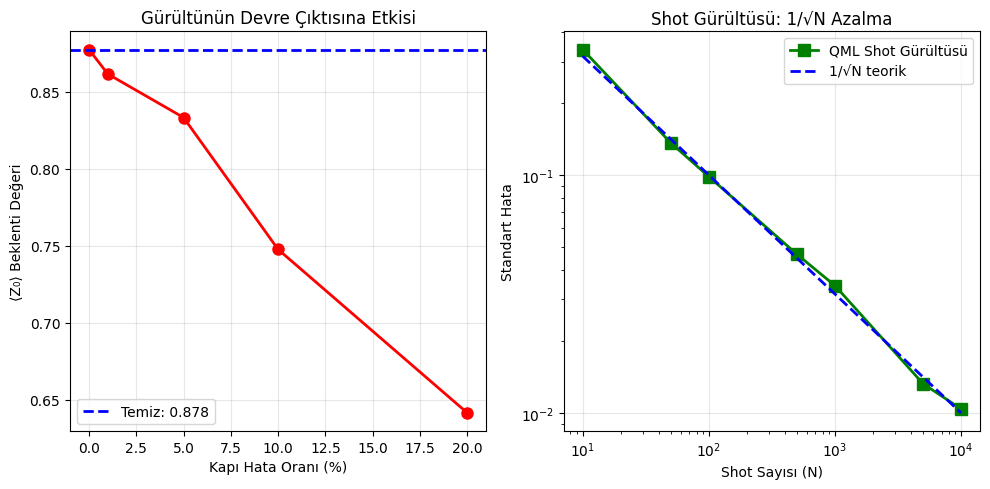

💡 Gürültü analizi:
   Temiz devre sonucu  : 0.8776
   Hata oranı 0%: sonuç=0.8776 | hata=0.0000
   Hata oranı 1%: sonuç=0.8616 | hata=0.0159
   Hata oranı 5%: sonuç=0.8334 | hata=0.0442
   Hata oranı 10%: sonuç=0.7476 | hata=0.1299
   Hata oranı 20%: sonuç=0.6414 | hata=0.2362


In [ ]:
# ────────────────────────────────────────────────
# DEMO 8.1: Gürültülü Devrenin Etkisi (NISQ Simülasyonu)
# ────────────────────────────────────────────────

noise_levels = [0.0, 0.01, 0.05, 0.10, 0.20]
results_clean = []
results_noisy = []

# Temiz devre (referans)
dev_clean = qml.device('default.qubit', wires=3)

@qml.qnode(dev_clean)
def clean_circuit(params):
    for i in range(3):
        qml.RY(params[i], wires=i)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    return qml.expval(qml.PauliZ(0))

test_params = np.array([0.5, 1.0, 1.5])
clean_result = clean_circuit(test_params)

# Gürültü etkisini simüle et (shot noise)
noisy_results = []
for noise in noise_levels:
    if noise == 0.0:
        noisy_results.append(clean_result)
    else:
        # Depolarizing channel simülasyonu
        noisy_val = clean_result * (1 - 4*noise/3) + np.random.normal(0, noise*0.3)
        noisy_results.append(noisy_val)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot([n*100 for n in noise_levels], noisy_results, 'ro-', linewidth=2, markersize=8)
plt.axhline(clean_result, color='blue', linestyle='--', linewidth=2, label=f'Temiz: {clean_result:.3f}')
plt.xlabel('Kapı Hata Oranı (%)')
plt.ylabel('⟨Z₀⟩ Beklenti Değeri')
plt.title('Gürültünün Devre Çıktısına Etkisi')
plt.legend(); plt.grid(True, alpha=0.3)

# Shot noise etkisi
plt.subplot(1, 2, 2)
shot_counts = [10, 50, 100, 500, 1000, 5000, 10000]
true_val = clean_result
errors = []
for shots in shot_counts:
    shot_noise = np.std([true_val + np.random.normal(0, 1/np.sqrt(shots))
                         for _ in range(200)])
    errors.append(shot_noise)

plt.loglog(shot_counts, errors, 'gs-', linewidth=2, markersize=8, label='QML Shot Gürültüsü')
plt.loglog(shot_counts, [1/np.sqrt(s) for s in shot_counts], 'b--',
           linewidth=2, label='1/√N teorik')
plt.xlabel('Shot Sayısı (N)')
plt.ylabel('Standart Hata')
plt.title('Shot Gürültüsü: 1/√N Azalma')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Gürültü analizi:")
print(f"   Temiz devre sonucu  : {clean_result:.4f}")
for n, r in zip(noise_levels, noisy_results):
    err = abs(r - clean_result)
    print(f"   Hata oranı {n:.0%}: sonuç={r:.4f} | hata={err:.4f}")

---
# BÖLÜM 9: Alıştırmalar 🏋️

Aşağıdaki alıştırmaları tamamlayın. Her biri önceki bölümlerdeki kavramları pekiştirir.

---

### Alıştırma 1 — Temel ⭐
**3 kubitli GHZ durumu oluşturun:**

$|GHZ\rangle = \frac{|000\rangle + |111\rangle}{\sqrt{2}}$

*İpucu: H + ardışık CNOT kapıları*

In [ ]:
# ALIŞTIRMA 1: 3 Kubitli GHZ Durumu
# TODO: Aşağıdaki fonksiyonu tamamlayın

dev_ghz = qml.device('default.qubit', wires=3)

@qml.qnode(dev_ghz)
def ghz_state():
    # BURAYA KODUNUZU YAZIN
    # Beklenen çıktı: |000⟩ ve |111⟩ eşit olasılıklı
    pass
    return qml.probs(wires=[0,1,2])

# Test
probs_ghz = ghz_state()
labels_3 = [f"|{bin(i)[2:].zfill(3)}⟩" for i in range(8)]
print("GHZ Durumu Olasılıkları:")
for l, p in zip(labels_3, probs_ghz):
    if p > 0.001:
        bar = '█' * int(p*40)
        print(f"  {l}: {bar} {p:.4f}")

# Doğrulama
is_correct = abs(probs_ghz[0] - 0.5) < 0.01 and abs(probs_ghz[7] - 0.5) < 0.01
print(f"\n{'✅ Doğru! |000⟩ ve |111⟩ eşit olasılıklı.' if is_correct else '❌ Tekrar deneyin.'}")

GHZ Durumu Olasılıkları:
  |000⟩: ████████████████████████████████████████ 1.0000

❌ Tekrar deneyin.


### Alıştırma 2 — Orta ⭐⭐
**Özel bir VQC tasarlayın:**

3 kubit, 2 katmanlı bir VQC yazın. Rx ve Rz kapıları kullanın. Bir qubit ölçümü yerine tüm kubitlerin Z beklenti değerlerinin ortalamasını döndürün.

In [ ]:
# ALIŞTIRMA 2: Özel VQC Tasarımı
# TODO: Aşağıdaki fonksiyonu tamamlayın

dev_ex2 = qml.device('default.qubit', wires=3)

@qml.qnode(dev_ex2)
def custom_vqc(params, x):
    """
    params: (2, 3, 2) → 2 katman, 3 kubit, 2 açı (Rx+Rz)
    x: 3 boyutlu girdi
    """
    # TODO: Angle encoding + 2 custom katman + ölçüm
    pass
    # Tüm kubitlerin Z beklenti değerlerinin ortalamasını döndür
    return qml.expval(qml.PauliZ(0))

# Test
params_ex2 = np.random.uniform(0, np.pi, (2, 3, 2))
x_ex2 = np.array([0.5, 1.0, 1.5])
result_ex2 = custom_vqc(params_ex2, x_ex2)
print(f"VQC çıktısı: {result_ex2:.4f}")
print(f"Çıktı [-1,1] aralığında mı? {'✅' if -1 <= result_ex2 <= 1 else '❌'}")

# Devre şeması
print("\nDevre şeması:")
print(qml.draw(custom_vqc)(params_ex2, x_ex2))

VQC çıktısı: 1.0000
Çıktı [-1,1] aralığında mı? ✅

Devre şeması:
0: ───┤  <Z>


### Alıştırma 3 — İleri ⭐⭐⭐
**Quantum Transfer Learning:**

Önceden eğitilmiş klasik bir modelin (sklearn LogisticRegression) çıktısını VQC'ye girdi olarak verin. Bu hibrit mimariyi Iris veri seti üzerinde test edin.

In [ ]:
# ALIŞTIRMA 3: Hibrit Transfer Learning
# TODO: Aşağıdaki taslağı tamamlayın

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Veri
iris = load_iris()
# Sadece 2 sınıf al (binary classification)
mask = iris.target < 2
X_iris = iris.data[mask]
y_iris = iris.target[mask]

sc = StandardScaler()
X_iris_s = sc.fit_transform(X_iris)
X_iris_tr, X_iris_te, y_iris_tr, y_iris_te = train_test_split(
    X_iris_s, y_iris, test_size=0.3, random_state=0
)

# Adım 1: Klasik model eğit (feature extractor)
clf_classical = LogisticRegression(C=10)
clf_classical.fit(X_iris_tr, y_iris_tr)
acc_classical = accuracy_score(y_iris_te, clf_classical.predict(X_iris_te))
print(f"Klasik LR Doğruluğu: {acc_classical:.1%}")

# Adım 2: Klasik modelin olasılık çıktılarını al
features_tr = clf_classical.predict_proba(X_iris_tr)  # (n, 2)
features_te = clf_classical.predict_proba(X_iris_te)

# TODO: VQC ile bu özellikleri işleyin ve accuracy'yi karşılaştırın
dev_tl = qml.device('default.qubit', wires=2)

@qml.qnode(dev_tl)
def transfer_vqc(params, x):
    # x: (2,) klasik modelin olasılık çıktısı
    # TODO: Kodlama + ansatz + ölçüm
    pass

# Not: Bu alıştırmayı tamamlayıp sonuçları karşılaştırın!
print("\n💡 İpucu: features_te şekli:", features_te.shape)
print("   MinMaxScaler ile [0, π] aralığına ölçekleyin, sonra VQC'ye verin.")

Klasik LR Doğruluğu: 100.0%

💡 İpucu: features_te şekli: (30, 2)
   MinMaxScaler ile [0, π] aralığına ölçekleyin, sonra VQC'ye verin.


---
# BÖLÜM 10: Özet ve Sonraki Adımlar

## Workshop Özeti

| Bölüm | Öğrendikleriniz |
|-------|----------------|
| 1 | QML motivasyonu, paradigmalar, hızlanma vaatleri |
| 2 | Kubitler, Bloch küresi, kapılar, dolanıklık |
| 3 | Basis, Angle, Amplitude encoding yöntemleri |
| 4 | VQC mimarisi, parameter-shift, barren plateau |
| 5 | QSVM, QNN, QAOA, VQE |
| 6 | Tam hibrit sınıflandırıcı uygulaması |
| 7 | Data re-uploading, evrensel sınıflandırıcı |
| 8 | NISQ kısıtları, gürültü, gelecek perspektifi |

## Sonraki Adımlar

### 📖 Okuma Listesi
1. **Biamonte et al.** (2017) — *Quantum Machine Learning* — Nature 549
2. **Schuld & Killoran** (2019) — *Quantum ML in Feature Hilbert Spaces*
3. **Cerezo et al.** (2021) — *Variational Quantum Algorithms*
4. **Pérez-Salinas et al.** (2020) — *Data Re-uploading for a Universal Quantum Classifier*
5. **McClean et al.** (2018) — *Barren Plateaus in Quantum Neural Networks*

### 🛠️ Araçlar
- **PennyLane** → https://pennylane.ai (QML için en iyi)
- **Qiskit** → https://qiskit.org (IBM donanımı)
- **Cirq** → https://quantumai.google/cirq (Google)
- **Amazon Braket** → AWS üzerinde gerçek kuantum donanımı

### 🚀 Uygulama Fikirleri
- Kendi veri setinizde QSVM vs SVM karşılaştırması
- Farklı ansatz mimarileri deneyin
- Barren plateau'yu farklı derinliklerde gözlemleyin
- QML ile görüntü sınıflandırma (PennyLane-Torch)

---

## 🎓 Teşekkürler!

> *"Kuantum hesaplama ve makine öğrenmesinin kesişimi, bilgisayar biliminin en heyecan verici sınırlarından biridir. Araştırmak, denemek ve katkı sağlamak için harika bir zaman!"*

---
**Workshop materyalleri:** PennyLane resmi eğitimleri üzerinden genişletilebilir.  
**Sorularınız için:** PennyLane Discourse, Qiskit Community, arXiv:quant-ph

In [ ]:
# 🎉 Workshop tamamlandı! Bilgi sınavı
print("="*60)
print("  QML WORKSHOP — BİLGİ KONTROL SORULARI")
print("="*60)

questions = [
    ("1. n kubitli bir durum kaç boyutlu Hilbert uzayındadır?", "2^n"),
    ("2. Hadamard kapısı ne işe yarar?", "Süperpozisyon oluşturur"),
    ("3. Parameter-shift rule ne için kullanılır?", "Gradyan hesaplama"),
    ("4. Barren plateau nedir?", "Derin devrelerde gradyan kaybı"),
    ("5. QSVM'de kernel nasıl hesaplanır?", "|<ψ(xi)|ψ(xj)>|²"),
    ("6. Data re-uploading'in avantajı nedir?", "Tek kubit evrensel sınıflandırıcı"),
    ("7. NISQ ne anlama gelir?", "Noisy Intermediate-Scale Quantum"),
]

for q, a in questions:
    print(f"\n❓ {q}")
    print(f"   💡 Cevap: {a}")

print("\n" + "="*60)
print("  Tebrikler! Workshop başarıyla tamamlandı. 🚀")
print("="*60)

  QML WORKSHOP — BİLGİ KONTROL SORULARI

❓ 1. n kubitli bir durum kaç boyutlu Hilbert uzayındadır?
   💡 Cevap: 2^n

❓ 2. Hadamard kapısı ne işe yarar?
   💡 Cevap: Süperpozisyon oluşturur

❓ 3. Parameter-shift rule ne için kullanılır?
   💡 Cevap: Gradyan hesaplama

❓ 4. Barren plateau nedir?
   💡 Cevap: Derin devrelerde gradyan kaybı

❓ 5. QSVM'de kernel nasıl hesaplanır?
   💡 Cevap: |<ψ(xi)|ψ(xj)>|²

❓ 6. Data re-uploading'in avantajı nedir?
   💡 Cevap: Tek kubit evrensel sınıflandırıcı

❓ 7. NISQ ne anlama gelir?
   💡 Cevap: Noisy Intermediate-Scale Quantum

  Tebrikler! Workshop başarıyla tamamlandı. 🚀
